In [1]:
# use extension to auto reload modules
%load_ext autoreload
%autoreload 2
# %load_ext line_profiler

In [2]:
import logging
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import hvplot.pandas
import seaborn as sns
import numpy as np
import scipy
import scipy.stats
import sktime
import statsmodels.api as sm
import statsmodels.formula.api as smf


The first use-cases in mind when playing with these bike counts data are the following : 
- Compare two periods (most likly, two years) for the same counter and decide if there is statistical evidence for a change : 
   * in the overall level of use of the bike-path, besides variations which would be explained by uncontrolled exogeneous effects such as weather, calendar etc. This could be used, e.g., to measure the "actual" evolution of the number of cyclists and evaluate the effect of modifications in the cycling policy/infrastructure.
   * In the behaviour of cyclists (possibly due to cultural or demographic variations among practitionners), such as how they react to rain, temperature or even vacations.
- Compare two sites in terms of how their level of use changes on average with identified parameters of interest such as weather, vacations etc. Possible questions adressed by this comparisons would be : 
   * Are cyclists using the cycle-path in Nice more sensitive to rain than in Paris ?
   * Does Paris loose cyclists in summer vacations while Nice gains some ?

Other use-cases could be simple day/week ahead count prediction, or abnormal/unusual count detection which could be an evidence for a special event or counter malfunction, justifying investigation.

This notebook is scoped in the following way.

First, a simple exploratory data analysis is performed : 
   * [Simple dataviz](#plain-dataviz)
   * Quick investigation of [basic seasonality in the signal](#seasonality-and-effect-of-the-day-of-week)
   * Quick investigation of the [effect of calendar features](#vacations-holidays-and-other-calendar-exeptions) such as working days and vacations.

This step is just there to gain a bit of insight on how the bike count can depend on some of the most important exogeneous features.

Then, as many exogeneous variables may be involved and their effect entangled, a first modelling stage is done. 
The goal of this stage is not really to build an accurate model of the bike count to be used for one of the use-cases.
Its goal is rather : 
* to be a tool to identify the main structures in the variations of the bike count depending on the exogenous parameters as a first attempt to "de-entangle" the main dependencies, especially when some of the parameters are highly correlated;
* to act as a "warm-up" and get insight on what kind of model could be used in the different use-cases.

Accordingly, the following rationale is applied : 
* Explore [the dependency of the bike count on temperature](#modelling-temperature-effect), as this is a well known obvious and important parameter of interest which should be controlled when investigating the effect of other parameters.
* [Assess the effect of rain](#including-the-effect-of-rain), another obvious confounding factor.
* Identify and include [other weather-related parameters](#sunshine-and-windspeed-effect) which cannot be neglected.

Finally, use this insight to properly identify and flag suspected outliers and deduce a modelling approach for the first use-case of cross-period comparison.

# Quick exploratory data anlysis

## Plain dataviz

First, the static data scrapped from eco-counter and fetched from the web are retrieved.

In [3]:
# find all the parquet files ending by "_bike_counts_with_weather.parquet" in the data/ folder
# load them and put the resulting table in a dict where the key is the prefix of the file name
data_folder = "data/"
data_counters = {}
for file_name in os.listdir(data_folder):
    if file_name.endswith("_bike_counts_with_weather.parquet"):
        nickname_clean = file_name.replace("_bike_counts_with_weather.parquet", "")
        data_counters[nickname_clean] = (pd.read_parquet(os.path.join(data_folder, file_name))
                                         .sort_index()
                                         .loc["2021":,:]) # drop 2020 data because of covid

bike_counters = sorted(list(data_counters.keys()))

Gathering all data from all counters is created, with a new column denoting the counter nickname.

In [4]:
# regroup all dataframes in the data_counters dict in a single dataframe with an additional column "counter" that contains the nickname of the counter
data_all_counters = pd.concat(
    [df.assign(counter=nickname) for nickname, df in data_counters.items()],
).sort_index().loc["2021":,:] # drop 2020 data because of covid
data_all_counters

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,count,in,out,is_rainy,is_weekend,weekday,is_holiday,is_vacations,counter
date,,,,,,,,,,,,,,,,,,,
2021-01-01,2.2,0.6,4.1,0.2,1.0,<NA>,7.6,18.5,1010.8,<NA>,2037.0,895.0,1142.0,False,False,Friday,True,True,paris_sebastopol
2021-01-01,6.9,5.5,9.3,11.2,<NA>,<NA>,19.1,55.0,1006.0,<NA>,166.0,95.0,71.0,True,False,Friday,True,True,nice_carras
2021-01-02,2.2,-0.3,4.6,0.0,<NA>,<NA>,5.3,21.0,1014.9,<NA>,3987.0,1793.0,2194.0,False,True,Saturday,False,True,paris_sebastopol
2021-01-02,7.4,5.8,11.2,23.9,<NA>,<NA>,18.7,50.0,1001.4,<NA>,349.0,206.0,143.0,True,True,Saturday,False,True,nice_carras
2021-01-03,3.4,2.8,4.3,0.0,<NA>,<NA>,8.6,31.0,1014.2,<NA>,3306.0,1386.0,1920.0,False,True,Sunday,False,True,paris_sebastopol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-08,9.6,7.4,11.1,15.6,<NA>,<NA>,18.5,38.9,1006.8,31.0,1228.0,588.0,640.0,True,True,Sunday,False,False,nice_carras
2026-02-08,9.6,7.4,11.1,15.6,<NA>,<NA>,18.5,38.9,1006.8,31.0,617.0,297.0,320.0,True,True,Sunday,False,False,cagnes_sur_mer
2026-02-09,10.6,8.9,11.7,11.0,<NA>,<NA>,14.4,27.8,1006.2,33.0,3086.0,1482.0,1604.0,True,False,Monday,False,False,nice_carras


In [5]:
data_paris = data_counters["paris_sebastopol"]
data_paris.head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,count,in,out,is_rainy,is_weekend,weekday,is_holiday,is_vacations
date,,,,,,,,,,,,,,,,,,
2021-01-01,2.2,0.6,4.1,0.2,1.0,<NA>,7.6,18.5,1010.8,<NA>,2037,895,1142.0,False,False,Friday,True,True
2021-01-02,2.2,-0.3,4.6,0.0,<NA>,<NA>,5.3,21.0,1014.9,<NA>,3987,1793,2194.0,False,True,Saturday,False,True
2021-01-03,3.4,2.8,4.3,0.0,<NA>,<NA>,8.6,31.0,1014.2,<NA>,3306,1386,1920.0,False,True,Sunday,False,True
2021-01-04,3.1,2.7,3.6,0.0,<NA>,<NA>,12.5,41.0,1013.6,<NA>,6471,2663,3808.0,False,False,Monday,False,False
2021-01-05,3.1,2.8,3.3,0.0,<NA>,<NA>,12.8,31.5,1014.8,<NA>,7490,3115,4375.0,False,False,Tuesday,False,False


In this first interactive plot, one can get a feeling of the variations of the bike count over time for each site. 
The mean day temperature is plotted as well to get a first feeling of seasons and how they can be related to the bike count depending on the site.

In [6]:
count_plot = data_all_counters.hvplot.line(
    y="count",
    width=1000,
    height=600,
    title="Bike counts over time at a counter",
    ylabel="Bike counts",
    groupby="counter",
    hover_cols=['prcp', 'weekday','is_holiday', 'is_vacations', 'tavg'],
    label="Bike count",
    )
count_plot
temp_plot = data_all_counters.hvplot.line(
    y="tavg",
    yaxis="right",
    color="firebrick",
    ylabel="Avg temperature (C)",
    groupby="counter",
    line_dash='dashed',
    hover_cols=['tavg', 'tmin', 'tmax', 'count'],
    label="Avg temperature",
    )
(count_plot * temp_plot).opts(
    multi_y=True,
    legend_position="top_left",
    legend_opts={"click_policy": "mute"}   # click legend to show/hide series
    )

BokehModel(combine_events=True, render_bundle={'docs_json': {'ee6a9437-2c90-49b2-8a6c-937083942dbb': {'version…

From this first plot, one can already see some common features and differences between these three sites :
- all of them seem to have a certain yearly (weekly when zooming?) seasonlity;
- the bike count seems correlated with the external temperature;
- but the time in the year also seem to have an effect. E. g. in Paris, the evolution of the count in summer seems much different that the one in Nice.

## Seasonality and effect of the day of week

These first observations motivate a quick investigation of temporal specificities in the variations of the bike counts.
Also, given the nature of the data, sensitivity to the human organization of daily life (day of week, calendar) are expected.

Plotting the autocorrelation of the bike-count timeseries is a first way to grab an idea of the importance of the seasonality in the data.

### ACF plot

In Paris Sebastopol, a major commuting cycleway, the data shows an expected autocorrelation with the previous day, as well as with the same day of the previous week (lag 7).
Yealrly seasonality can be guessed as well.

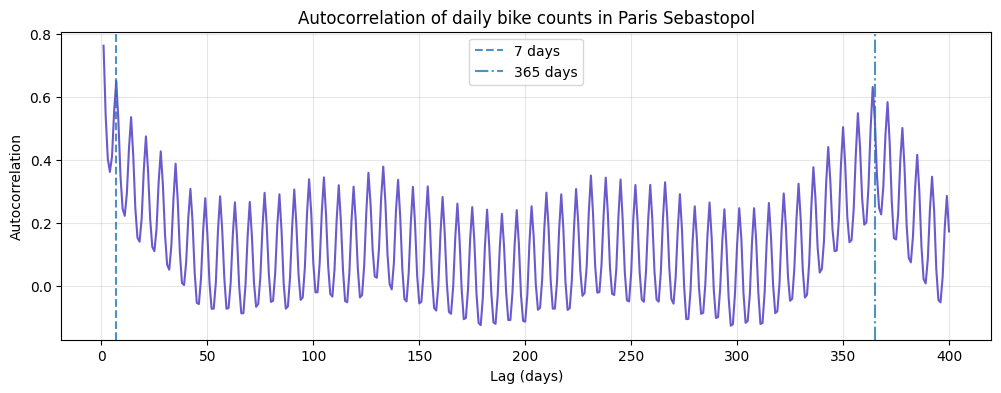

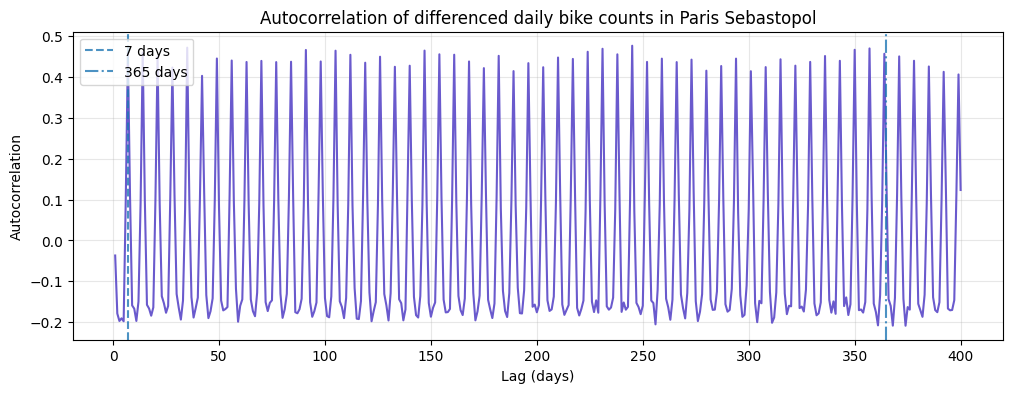

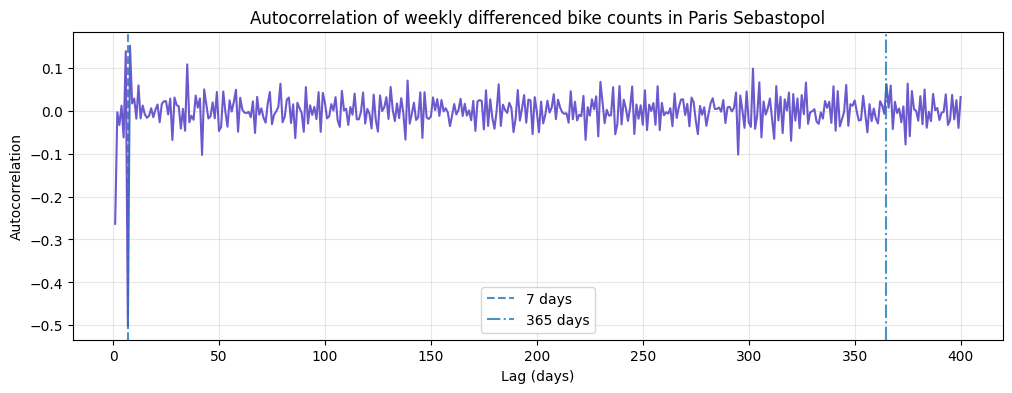

In [7]:
def plot_acf(series, max_lag=400, title="Autocorrelation", mark_lags=(7, 365)):
    series = series.dropna()
    acf_vals = [series.autocorr(lag) for lag in range(1, max_lag + 1)]
    plt.figure(figsize=(12, 4))
    plt.plot(range(1, max_lag + 1), acf_vals, color="slateblue")
    line_styles = ["--", "-.", ":", (0, (5, 1))]
    for i, lag in enumerate(mark_lags):
        plt.axvline(lag, linestyle=line_styles[i % len(line_styles)], alpha=0.8, label=f"{lag} days")
    plt.title(title)
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")
    plt.grid(True, alpha=0.3)
    plt.legend()

# example usage
plot_acf(data_paris["count"], max_lag=400, title="Autocorrelation of daily bike counts in Paris Sebastopol")
plot_acf(data_paris["count"].diff(), max_lag=400, title="Autocorrelation of differenced daily bike counts in Paris Sebastopol")
plot_acf(data_paris["count"].diff().diff(periods=7).dropna(), max_lag=400, title="Autocorrelation of weekly differenced bike counts in Paris Sebastopol")

The plot can aslo be done with sktim which provides a view of PACF but is a bit less nice.

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='count'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

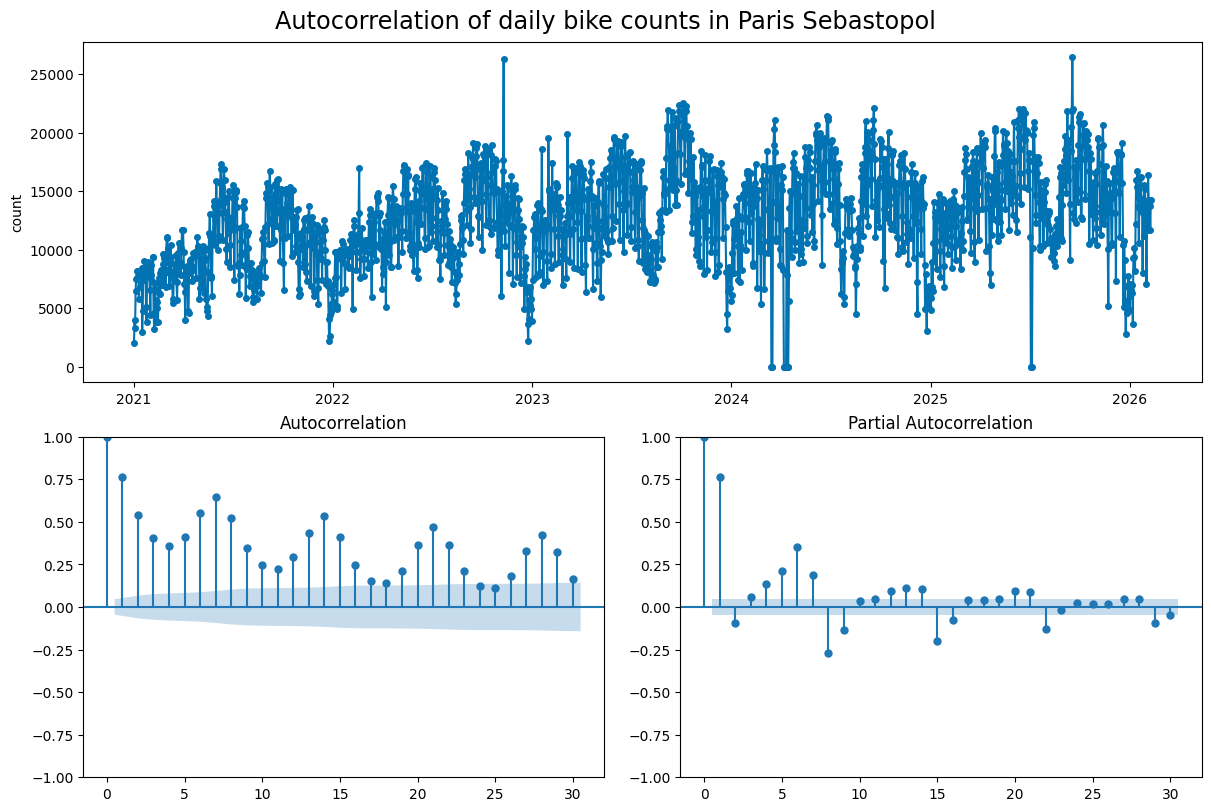

In [8]:
sktime.utils.plotting.plot_correlations(data_paris["count"], lags=30, suptitle="Autocorrelation of daily bike counts in Paris Sebastopol")

Conversely to Paris, the autocorrelation of the bike counts in the counters in Nice and Cagnes-sur-Mer have a much less obvious 7 days seasonality.

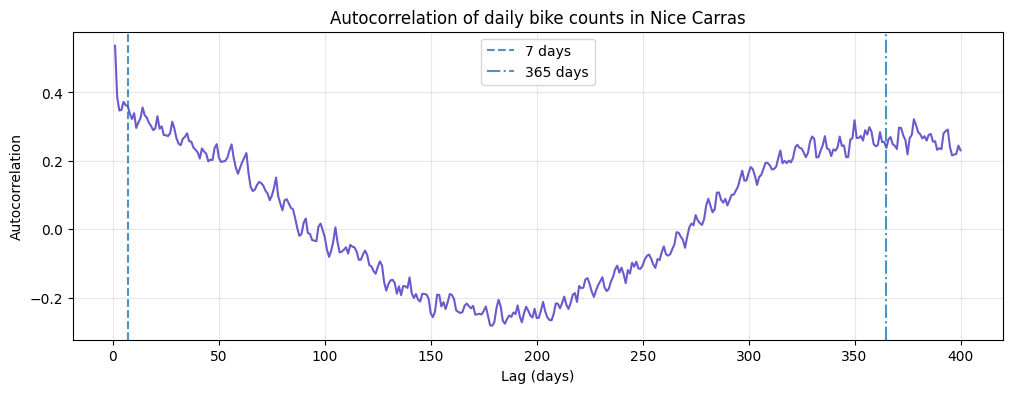

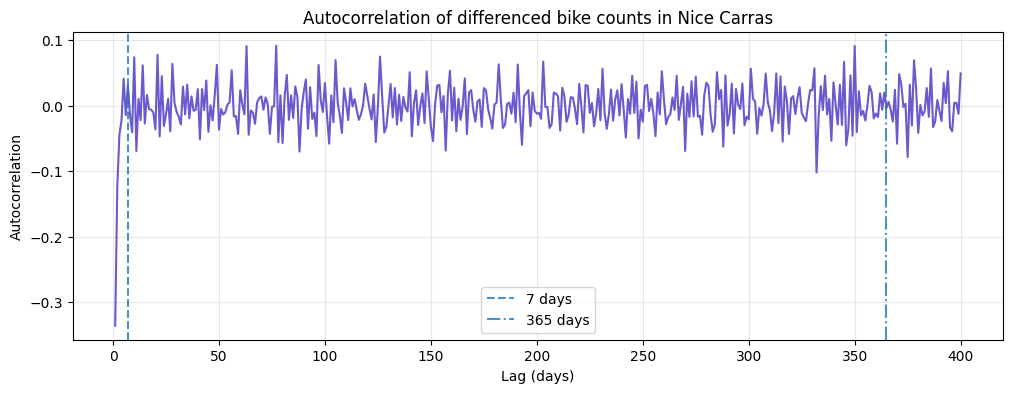

In [9]:
# example usage
plot_acf(data_counters['nice_carras']['count'], max_lag=400, title="Autocorrelation of daily bike counts in Nice Carras")
plot_acf(data_counters['nice_carras']['count'].diff().dropna(), max_lag=400, title="Autocorrelation of differenced bike counts in Nice Carras")

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='count'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

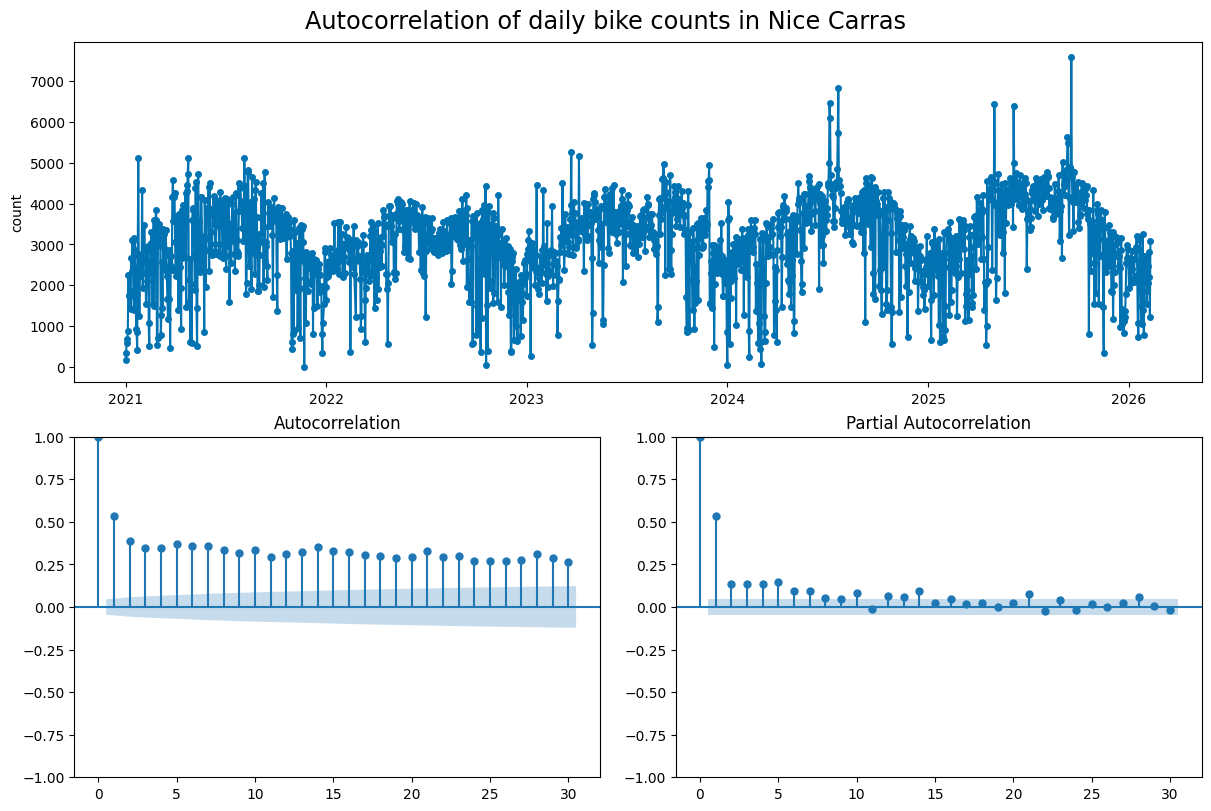

In [10]:
sktime.utils.plotting.plot_correlations(data_counters['nice_carras']['count'].dropna(),
                                        lags=30,
                                        suptitle="Autocorrelation of daily bike counts in Nice Carras")

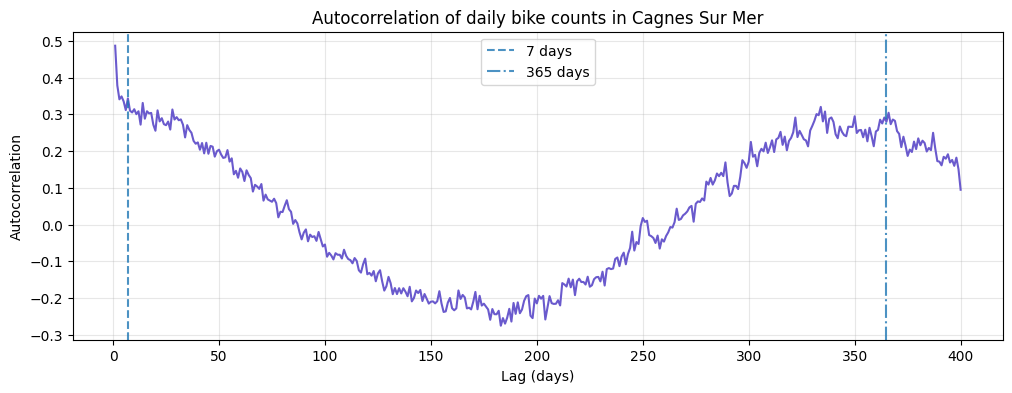

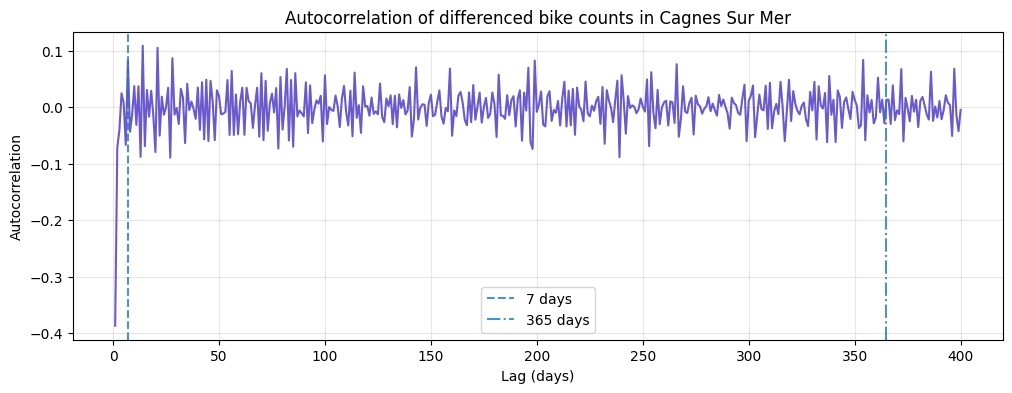

In [11]:
# example usage
plot_acf(data_counters['cagnes_sur_mer']['count'], max_lag=400, title="Autocorrelation of daily bike counts in Cagnes Sur Mer")
plot_acf(data_counters['cagnes_sur_mer']['count'].diff().dropna(), max_lag=400, title="Autocorrelation of differenced bike counts in Cagnes Sur Mer")

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='count'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

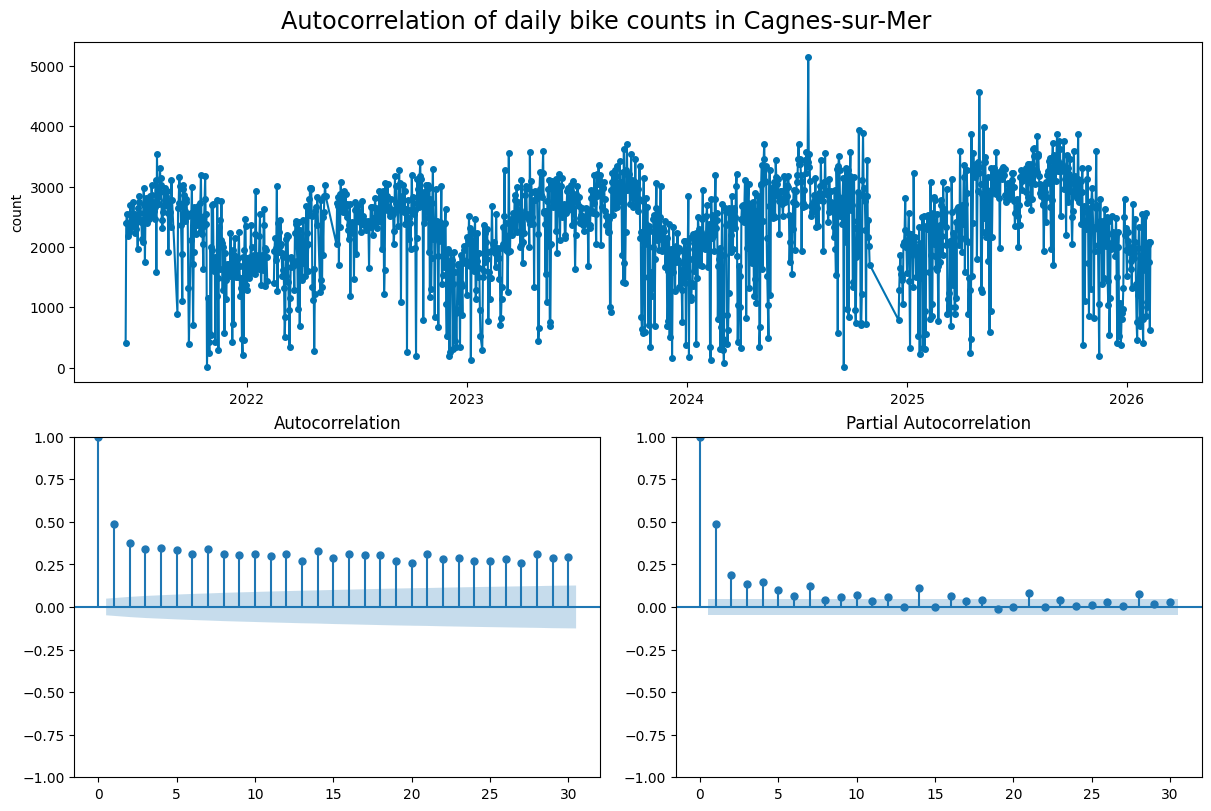

In [12]:
sktime.utils.plotting.plot_correlations(data_counters['cagnes_sur_mer']['count'].dropna(),
                                        lags=30,
                                        suptitle="Autocorrelation of daily bike counts in Cagnes-sur-Mer")

From these observations, a strong weekly pattern should be expected in Paris while a less obvious one is expected in Nice and Cagnes (but still, one can guess a small effect in the PACF plots).

There is also a strong and expected autocorrelation of the timeseries at lag 1 (weather among other things).

### Weekday effect

Representing the bike counts as box plots for each day of the week and each counter shows, indeed, a more obvious pattern in Paris.

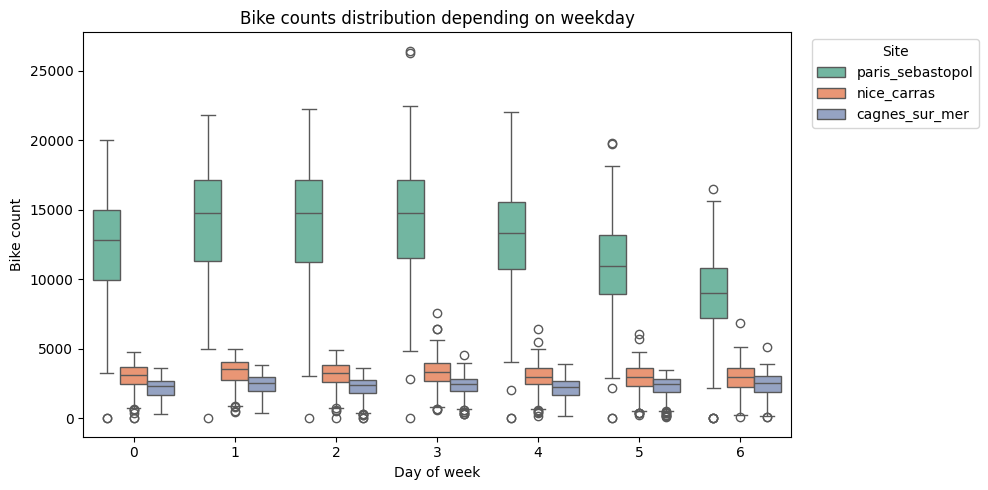

In [13]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plot_data = data_all_counters.reset_index()
plot_data["weekday"] = data_all_counters.index.day_of_week

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=plot_data,
    x="weekday",
    y="count",
    hue="counter",
    palette="Set2",
)
plt.title("Bike counts distribution depending on weekday")
plt.xlabel("Day of week")
plt.ylabel("Bike count")
plt.legend(title="Site", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

As the frequentation of each site can be very different, and the counts display a few outliers, a normalized version of the bike counts is used below, by scaling the count by the 95th percentile of the counts for each site.

In [14]:
data_all_counters.groupby("counter")["count"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
counter,,,,,,,,,,,
cagnes_sur_mer,1611.0,2281.612663,778.036578,12.0,1159.0,1832.00,2421.0,2830.5,3159.0,3321.50,5145.0
nice_carras,1862.0,3073.103115,1004.175812,6.0,1671.5,2493.75,3176.0,3781.5,4232.9,4476.75,7585.0
paris_sebastopol,1866.0,12636.016613,4148.928968,0.0,7388.5,9761.00,12642.5,15630.0,17995.5,19353.50,26443.0


In [15]:
normalize_factors = data_all_counters.groupby("counter")["count"].quantile(0.95)
q95_by_counter = data_all_counters.groupby("counter")["count"].transform(lambda s: s.quantile(0.95))
data_all_counters["normalized_count"] = data_all_counters["count"] / q95_by_counter
data_all_counters[["count", "normalized_count", "counter"]].head()

,count,normalized_count,counter
date,,,
2021-01-01,2037.0,0.105252,paris_sebastopol
2021-01-01,166.0,0.037080,nice_carras
2021-01-02,3987.0,0.206009,paris_sebastopol
2021-01-02,349.0,0.077958,nice_carras
2021-01-03,3306.0,0.170822,paris_sebastopol


The plot below represents the daily counts distribution for each counter, scaled by the 95% quantile of each counter's dataset.

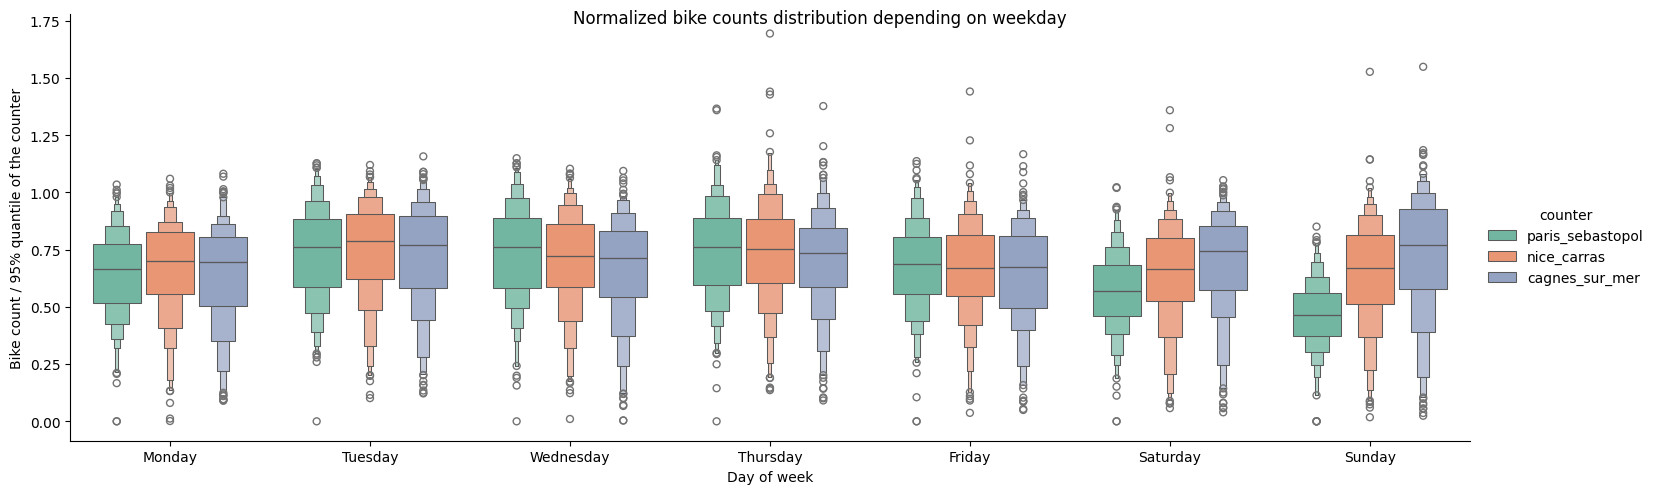

In [16]:
plot_data = data_all_counters.reset_index()
plot_data["weekday"] = data_all_counters.index.day_of_week
plot_data["day_name"] = pd.Categorical(
    plot_data["date"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
plot_data["month"] = pd.Categorical(
    plot_data["date"].dt.month_name(),
    categories=month_order,
    ordered=True
)

boxen = sns.catplot(
    kind='boxen',
    data=plot_data,
    x="day_name",
    y="normalized_count",
    hue="counter",
    palette="Set2",
    gap=0.1,
    height=5,
    aspect=3,
)
boxen.fig.suptitle("Normalized bike counts distribution depending on weekday")
boxen.set_xlabels("Day of week")
boxen.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

In the plot above, one can guess some weekly patterns and their differences or common points between counters. 

Splitting the plots by counter below gives a better insight of the pattern for each counter.

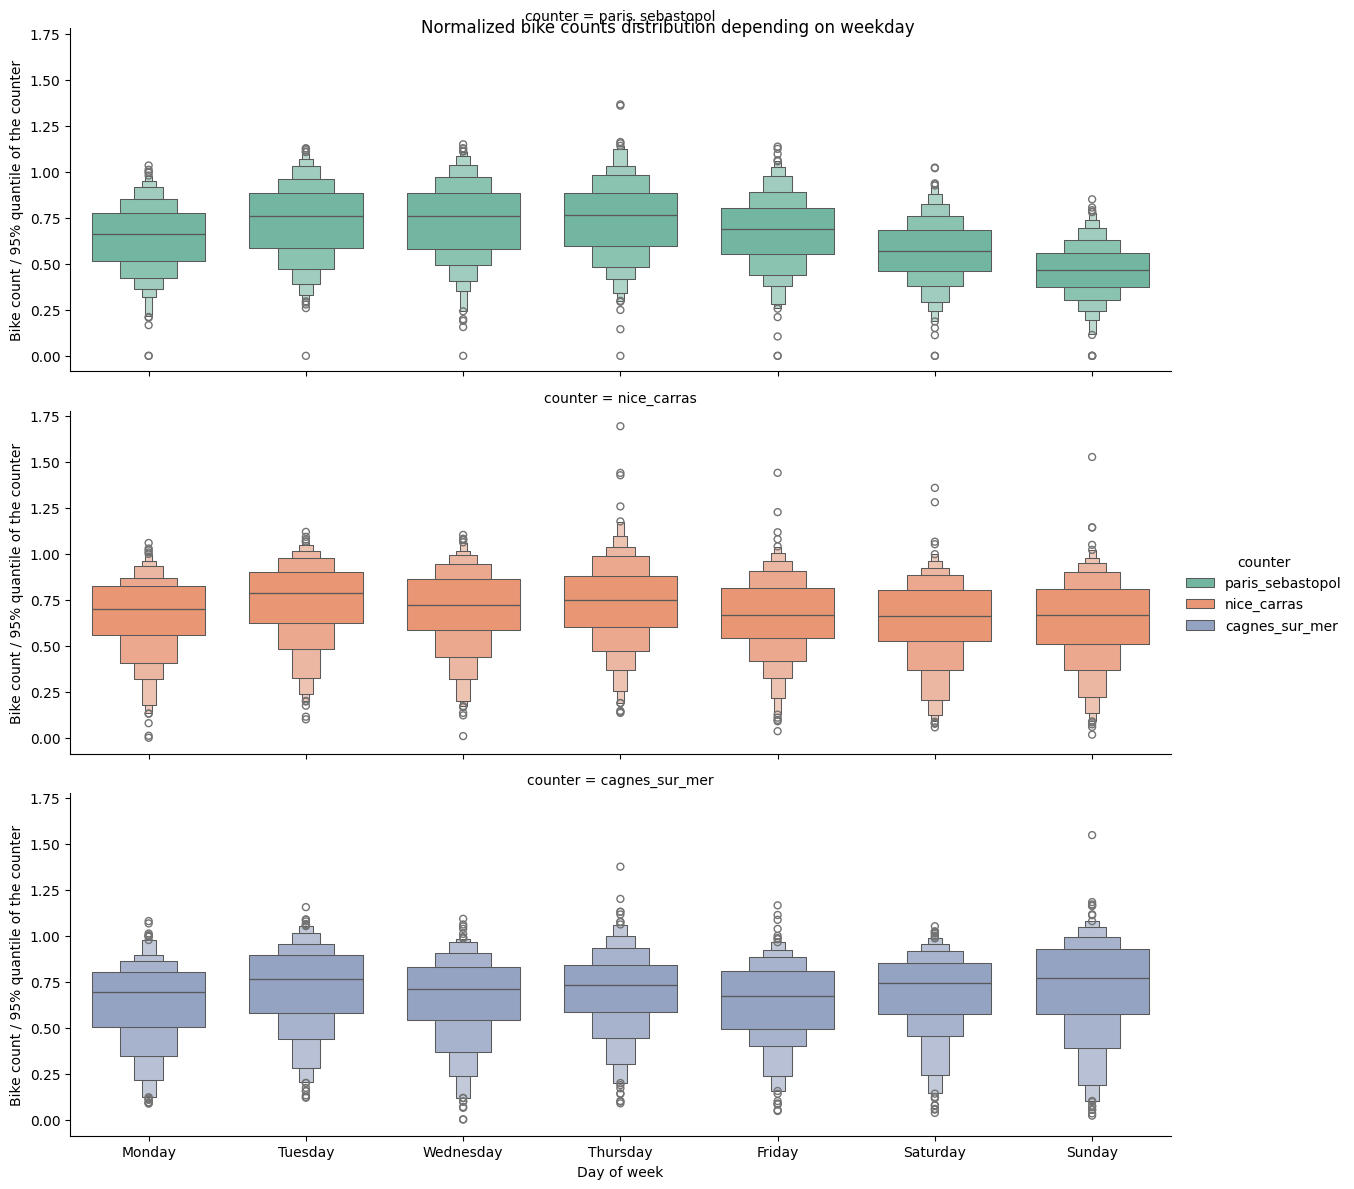

In [17]:
boxen = sns.catplot(
    kind='boxen',
    data=plot_data,
    x="day_name",
    y="normalized_count",
    hue="counter",
    palette="Set2",
    gap=0.1,
    height=4,
    aspect=3,
    row="counter",
)
boxen.fig.suptitle("Normalized bike counts distribution depending on weekday")
boxen.set_xlabels("Day of week")
boxen.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

It's interesting to see that daily patterns seem to exist and show some **similarities from Monday to Friday for all counters**.

However, the **weekends seem to have different patterns depending on the counter**, how was guessed in the very first dataviz when retrieving the data : 
- In **Paris Sebastopol**, well-known to be mainly used by commuters, **weekends are much quieter**.
- In **Cagnes-sur-Mer and Nice**, where the seaside is widely used by commuters, but also by leisure riders, **the difference is much less obvious**.

Examinating the hourly profiles depending on the day and site could give more insight about the kind of users in each case, but unfortunately, this data is not available on the Eco Counter website.

The effect of weekday could be investigated in a more quantitative manner, and a simple look at the descriptive statistics for each day and counter already provides another point of view, as illustrated below.

In [18]:
plot_data.groupby(["counter", "day_name"])["normalized_count"].describe().round(2)

/tmp/ipykernel_51562/3240804692.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data.groupby(["counter", "day_name"])["normalized_count"].describe().round(2)


count  mean   std   min   25%   50%   75%   max
counter          day_name                                                  
cagnes_sur_mer   Monday     231.0  0.64  0.22  0.09  0.50  0.70  0.81  1.08
                 Tuesday    230.0  0.72  0.23  0.12  0.58  0.77  0.90  1.16
                 Wednesday  231.0  0.67  0.23  0.00  0.54  0.71  0.83  1.09
                 Thursday   231.0  0.71  0.22  0.09  0.59  0.73  0.85  1.38
                 Friday     230.0  0.64  0.22  0.05  0.50  0.67  0.81  1.17
                 Saturday   229.0  0.69  0.22  0.04  0.58  0.74  0.85  1.05
                 Sunday     229.0  0.73  0.27  0.02  0.58  0.77  0.93  1.55
nice_carras      Monday     266.0  0.66  0.21  0.00  0.56  0.70  0.83  1.06
                 Tuesday    265.0  0.74  0.22  0.10  0.62  0.79  0.90  1.12
                 Wednesday  265.0  0.70  0.22  0.01  0.59  0.72  0.86  1.10
                 Thursday   266.0  0.74  0.23  0.14  0.60  0.75  0.88  1.69
                 Friday     267.0  0.67  0.21  0.04  0.55  0.67  0.81  1.44
                 Saturday   266.0  0.64  0.22  0.06  0.52  0.66  0.80  1.36
                 Sunday     267.0  0.65  0.24  0.02  0.51  0.67  0.81  1.53
paris_sebastopol Monday     267.0  0.65  0.19  0.00  0.51  0.66  0.77  1.03
                 Tuesday    266.0  0.73  0.21  0.00  0.59  0.76  0.88  1.13
                 Wednesday  266.0  0.73  0.21  0.00  0.58  0.76  0.89  1.15
                 Thursday   266.0  0.74  0.21  0.00  0.60  0.76  0.89  1.37
                 Friday     267.0  0.68  0.20  0.00  0.56  0.69  0.80  1.14
                 Saturday   267.0  0.57  0.17  0.00  0.46  0.57  0.68  1.02
                 Sunday     267.0  0.47  0.15  0.00  0.37  0.47  0.56  0.85

Using ANOVA or any related method adapted to the distribution of the data, with the right post-hoc analysis would help figuring out more accurately the patterns.
However, this is not yet the goal of this notebook, which is rather focused on getting a first insight of the parameters of interest to compare two periods or predict a future count.

From the observation above, one can already conclude that using the day of week as exogeneous variables in the first guess of model of the bike count seems a good starting point.

The following sections investigate the effect of other factors which are known/suspected to have an effect on the bike count.

## Vacations, holidays and other calendar exeptions

As the day of the week, which is highly entangled with peoples habits, some other calendar specificities are known to have an effect of our mobility.
Typically, peopole tend to move in different ways during vacations, holidays or working periods.
This section provides a first investigation of the effect of these variables on the bike counts.

First, let take a look at the distribution of counts for each counter depending on the fact that a day is a holiday, during vacations or a "normal day".

A categorical variable is defined accordingly. To simplify, a holiday during vacations is just considered as a holiday, neglecting the combination of these features.

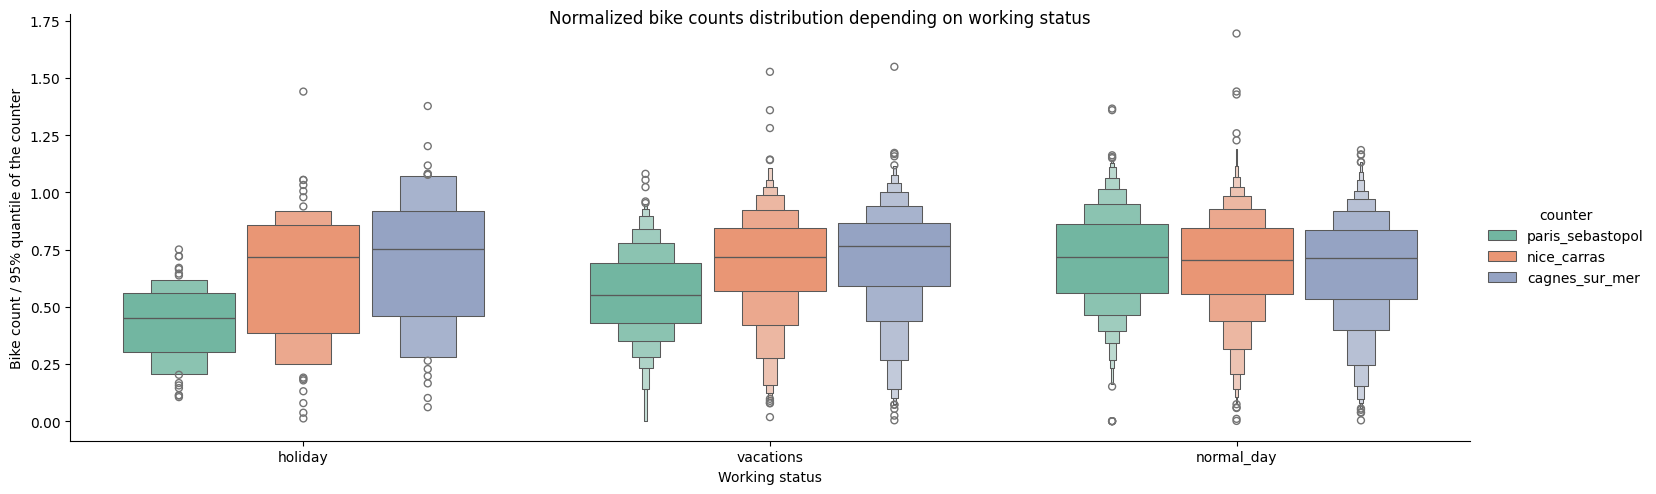

In [19]:
# Define "working status" categorical variable from the "is_holiday" and "is_vacations" boolean columns
working_status_order = ['holiday', 'vacations', 'normal_day']
plot_data["working_status"] = np.select(
    [
        plot_data["is_holiday"],
        plot_data["is_vacations"],
    ],
    [
        "holiday",
        "vacations",
    ],
    default="normal_day"
)
plot_data["working_status"] = pd.Categorical(
    plot_data["working_status"],
    categories=working_status_order,
    ordered=True
)

boxen = sns.catplot(
    kind='boxen',
    data=plot_data,
    x="working_status",
    y="normalized_count",
    hue="counter",
    palette="Set2",
    gap=0.1,
    height=5,
    aspect=3,
)
boxen.fig.suptitle("Normalized bike counts distribution depending on working status")
boxen.set_xlabels("Working status")
boxen.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

While a quantitative analysis would be needed to be more accurate, the plot above gives a good insight of what happens at these three locations, with the light of the prior knowledge about the nature of the data.
Once again, Paris Sebastopol shows a different pattern than Nice and Cagnes-sur-Mer.

**In Paris, holidays and vacations seem to have a clear effect on the median count of cyclists** : holidays are less busy than vacations, which are less busy than normal days. 

**In Nice and Cagnes-sur-Mer** (neighbouring counters), **the effect on the median value is much less obvious** (or inexistent). 
However, one can see that the **dispertion** of the counts for these counters **during holidays is much higher**.

The cell below gives a more quantitative view of the statistics illustrated above.

In [20]:
plot_data.groupby(["counter", "working_status"])["normalized_count"].describe()

/tmp/ipykernel_51562/1266729444.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data.groupby(["counter", "working_status"])["normalized_count"].describe()


count      mean       std       min  \
counter          working_status                                         
cagnes_sur_mer   holiday           46.0  0.702125  0.324607  0.061117   
                 vacations        535.0  0.713363  0.231882  0.003914   
                 normal_day      1030.0  0.672510  0.229689  0.003613   
nice_carras      holiday           56.0  0.643053  0.303969  0.012062   
                 vacations        586.0  0.687214  0.226372  0.017870   
                 normal_day      1220.0  0.688088  0.219004  0.001340   
paris_sebastopol holiday           56.0  0.432402  0.170911  0.105252   
                 vacations        587.0  0.556102  0.187707  0.000000   
                 normal_day      1223.0  0.709466  0.204932  0.000000   

                                      25%       50%       75%       max  
counter          working_status                                          
cagnes_sur_mer   holiday         0.457700  0.754328  0.920217  1.377390  
                 vacations       0.591299  0.766220  0.864369  1.548999  
                 normal_day      0.535150  0.711275  0.835842  1.185007  
nice_carras      holiday         0.387111  0.719719  0.855587  1.440554  
                 vacations       0.569833  0.716368  0.846373  1.527001  
                 normal_day      0.554643  0.705311  0.843581  1.694309  
paris_sebastopol holiday         0.301095  0.450203  0.561836  0.750510  
                 vacations       0.430026  0.549358  0.690883  1.081200  
                 normal_day      0.559873  0.719043  0.862350  1.366316

Of course, the `holiday` catagory is much less represented in the dataset, which could lead to higher variance.

But as the number of samples of holidays are already about 50 in each counter, and Paris and Nice have the same count of holiday samples, other causes deserve investigation.

In particular, **it can be suspected that, provided the prior knowledge that leisure rides are more prominent in Nice and Cagnes, the effect of weather may be more important there on holidays.**

Quantitative analysis should therefore investigate the effect of the interaction between weather and working status.

## Investigating the effect of weather

As noticed earlier, weather is likely a relevant parameter which should affect the bike counts : cyclists tend to be more enthusiastic to ride in mild and dry weather conditions!

The following cells, after curing a few missing data, represent the normalized count for each meter depending on the average day temperature, split by working status of the day. 
Days for which precipitations are greater than 0 are tagged as "rainy", and distinguished by a different color.

In [21]:
nan_rainy = plot_data.loc[plot_data["prcp"].isna(), :].copy()

In [22]:
plot_data = plot_data.loc[~plot_data["prcp"].isna(), :]

Redefine a `is_rainy` boolean variable where precipitations are higher than 0mm in the day.

In [23]:
plot_data.loc[:,'is_rainy'] = plot_data['prcp'] > 0.

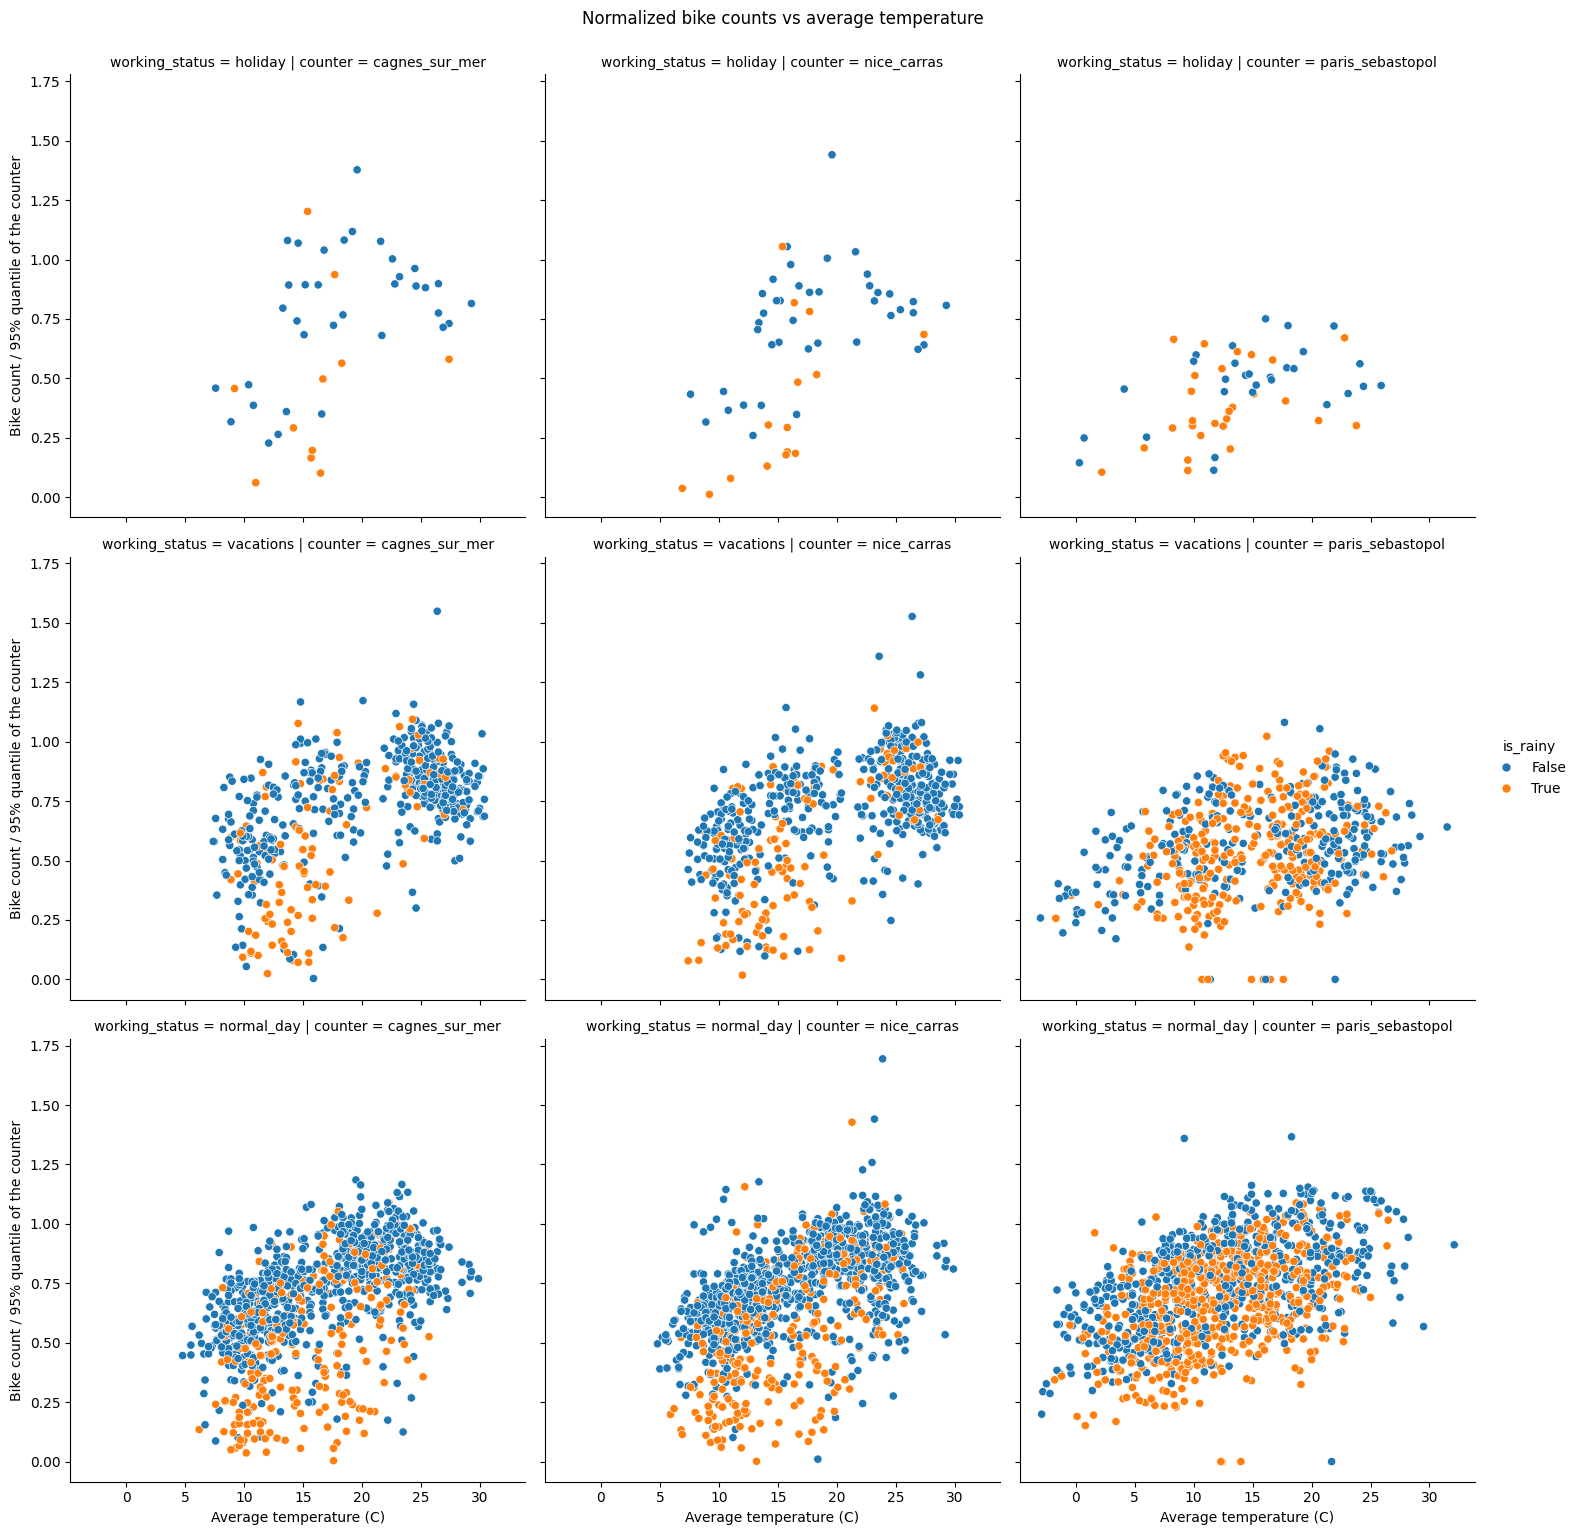

In [24]:
counter_order = sorted(plot_data["counter"].unique())

lm_graph = sns.relplot(
    data=plot_data,
    x="tavg",
    y="normalized_count",
    hue="is_rainy",
    row="working_status",
    col="counter",
    col_order=counter_order,
    )
lm_graph.fig.suptitle(f"Normalized bike counts vs average temperature", y=1.02)
lm_graph.set_xlabels("Average temperature (C)")
lm_graph.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

While quantitative analysis is still not yet in the scope of this notebook, qualitative observations can already be formulated.

### Weather in Paris


Starting with Paris, on "normal days", **temperature seem to have a clear positive correlation with the normalized bike count, and rain seems to have a negative effect on it.**

**The rainy and non rainy sets seem quiet entangled and do not display obvious differences in thermosensitivity**, besides a vertical shift. 
This could be investigated more thouroughly later on, as the day of week was found to have an effect in Paris.

A few outliers can also be spotted :
- Zero values which could indicate a matfunction of the meter.
- A couple high values, which dates could be investigated in order to find if they match with sepcial events, or which could be just dumped if this kind of information isn't of interest.

Also, the slope of the thermosensitivity does not show an obvious variation between vacations, holidays and normal days (to be confirmed quantitativly).

Finally, the clustered structure of the plot for vacations can be noticed.
This can be explained by the correlation betwen the weather and the date in the year : vacations repeat periodically each year at the same time, with similar meteorological conditions.

This can create a bit of confusion regarding the effect of high average temperatures, maybe more easily understood in the plot below, where only non rainy days are represented to let aside the effect that rain could have on the results.

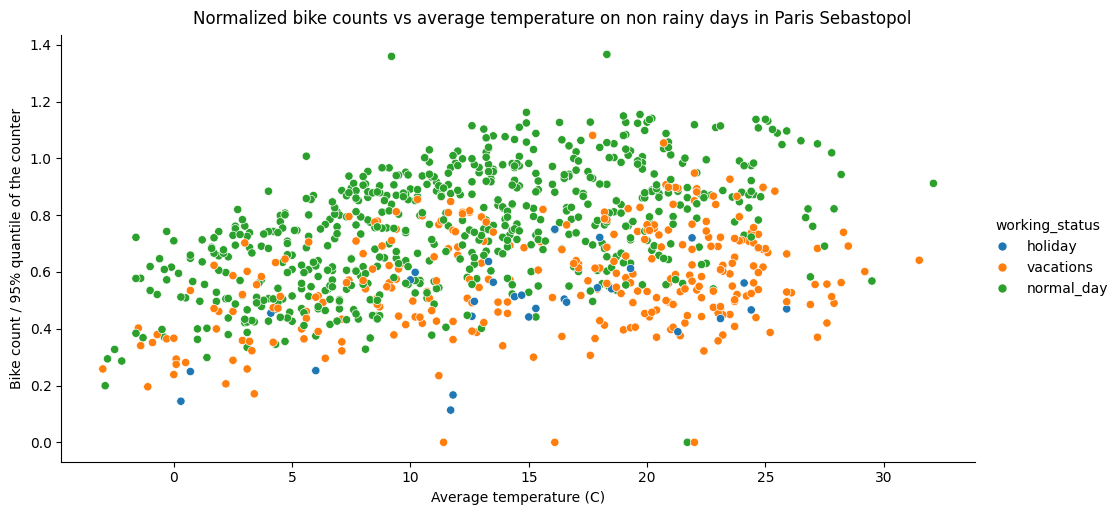

In [25]:
lm_graph = sns.relplot(
    data=plot_data.query("prcp == 0 and counter == 'paris_sebastopol'"),
    x="tavg",
    y="normalized_count",
    hue="working_status",
    aspect=2,
)
lm_graph.figure.suptitle("Normalized bike counts vs average temperature on non rainy days in Paris Sebastopol", y=1.02)
lm_graph.set_xlabels("Average temperature (C)")
lm_graph.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

An interactive version below :

In [26]:
count_plot = plot_data.query("prcp == 0").hvplot.scatter(
    y="count",
    x="tavg",
    width=1000,
    height=600,
    title="Bike counts as a function of average temperature at a counter",
    xlabel="Average temperature (C)",
    ylabel="Bike counts",
    groupby="counter",
    by='working_status',
    hover_cols=['date', 'day_name', 'wspd', 'tavg'],
    label="Bike count",
    # color=sns.color_palette("Blues", n_colors=len(working_status_order)).as_hex(),
    )
(count_plot).opts(
    legend_position="top_left",
    legend_opts={"click_policy": "mute"}   # click legend to show/hide series
    )

BokehModel(combine_events=True, render_bundle={'docs_json': {'16e406b2-01f9-4852-b49a-ac2ac1fc97db': {'version…

**When the averaged temperature gets higher than about 20°C, one could assume from this plots the the number of cyclists stops increasing and**, conversely, that the number of counted bikes **drops** as the temperature becomes hotter and hotter.

This is a plausible assumption, and **it would make bike usage influenced by the thermal comfort in a similar way as energy consumption** (with opposite convexity).

However : 
- as most of occurences of high temperatures happen during summer vacations;
- bike counts are lower during the vacations in Paris (from the box plots below, which did not account for effect of temperature, but also from the plot above);
- vacations are rather concentrated at high and low temperatures due to their time of occurence;

the effect of these high temperatures isn't obvious to tell.

### Weather on the French Riviera

The case of southern France is a bit less obvious : **rainy and non rainy days seem less entangled and could have different thermosensitivities**.

As regards the holidays, the sensitivity looks much higher than in Paris, while the difference is less obvious for other kinds of days. 
The holidays weather-sensitivity could also look higher than for other kinds of days at the same location, which could be consistent with the higher variance noticed earlier.

However, another important difference with Paris is that the counts for southern France meters seem to show a **rather important number of scattered, low-frequentation days away from the "main cluster"**.
This could be the sign of an additional confusion factor which hasn't been accounted for yet and deserves a bit of investigations.

The interactive plot above was used to explore manually the days where the bike count seems surprisingly low in Nice and Cagnes.
While some of them are cleary special events (e.g. the Iron Man race or marathon) when the cyclepath is closed or difficult to access most of the day, nothing obvious was noticed.

Finally, and most important observation : in the plots above, the effect of temperature was investigated for all counters in a separate way between vacations, holidays and normal days.
However, the section about [working day status](#vacations-holidays-and-other-calendar-exeptions) did not show visible differences in bike count in Nice depending on the working day status, even though the effect of temperature wasn't controlled and could have confused the result.

Plotting all counts for Nice on the same graph depending on temperature may suggest that the assumption discussed concerning high temperatures in Paris example may be true : 
* **higher temperatures could result in less cyclists beyond a certain threshold,**
* but the same difficulty of high correlation between the occurence of high temperature and the vacation status arises.

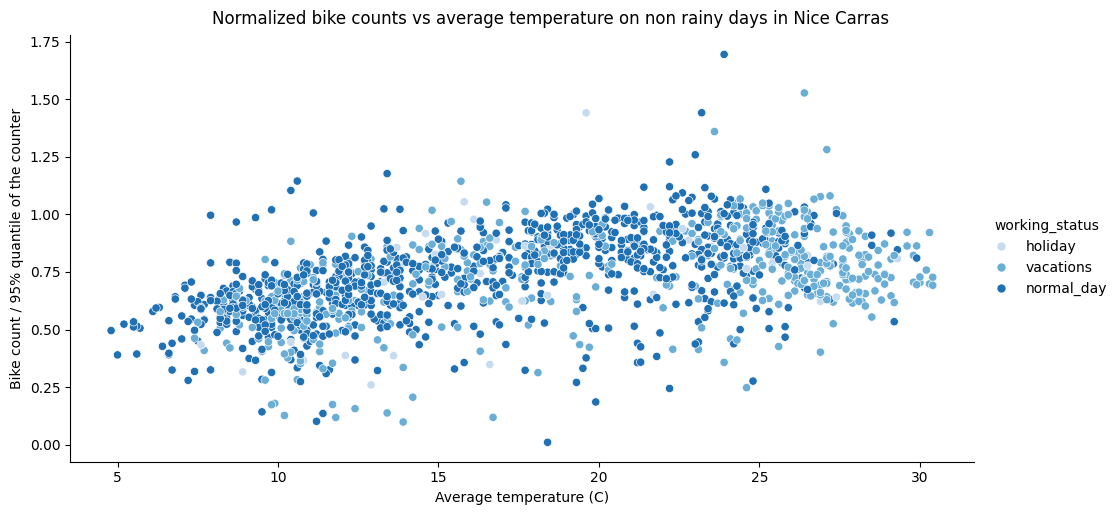

In [27]:
lm_graph = sns.relplot(
    data=plot_data.query("prcp == 0 and counter == 'nice_carras'"),
    x="tavg",
    y="normalized_count",
    hue="working_status",
    aspect=2,
    palette="Blues",
)
lm_graph.figure.suptitle("Normalized bike counts vs average temperature on non rainy days in Nice Carras", y=1.02)
lm_graph.set_xlabels("Average temperature (C)")
lm_graph.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

Rather than graphs, one may prefer to look at statistics.
Below, the tables summarize the basic statistics in Nice for mild or hot days.

In [28]:
print("Bike counts statistics on warm days (18C < tavg < 23C) without rain in Nice Carras:")
plot_data.query("prcp == 0 and counter == 'nice_carras' and tavg > 18 and tavg < 23").groupby("working_status", observed=True)[["normalized_count", "tavg"]].describe()

Bike counts statistics on warm days (18C < tavg < 23C) without rain in Nice Carras:


normalized_count                                          \
                          count      mean       std       min       25%   
working_status                                                            
holiday                     8.0  0.933881  0.250458  0.648238  0.811024   
vacations                  41.0  0.748992  0.164393  0.312727  0.684872   
normal_day                223.0  0.835358  0.174190  0.010275  0.781147   

                                               tavg                       \
                     50%       75%       max  count       mean       std   
working_status                                                             
holiday         0.913944  1.012174  1.440554    8.0      20.55  1.822087   
vacations       0.776456  0.883677  0.959625   41.0  20.173171  1.651972   
normal_day      0.868040  0.945999  1.227453  223.0  20.415247  1.382106   

                                                  
                 min     25%   50%     75%   max  
working_status                                    
holiday         18.4  19.025  20.6  21.925  22.8  
vacations       18.1    18.7  19.8    22.0  22.9  
normal_day      18.1    19.2  20.4   21.45  22.9

In [29]:
print("Bike counts statistics on hot days (tavg > 23C) without rain in Nice Carras, depending on working status:")
plot_data.query("prcp == 0 and counter == 'nice_carras' and tavg > 23").groupby("working_status", observed=True)[["normalized_count", "tavg"]].describe()

Bike counts statistics on hot days (tavg > 23C) without rain in Nice Carras, depending on working status:


normalized_count                                          \
                          count      mean       std       min       25%   
working_status                                                            
holiday                    10.0  0.776411  0.082571  0.622326  0.767298   
vacations                 234.0  0.804287  0.159916  0.247724  0.701513   
normal_day                151.0  0.836620  0.174924  0.276093  0.761267   

                                               tavg                       \
                     50%       75%       max  count       mean       std   
working_status                                                             
holiday         0.798012  0.825040  0.860892   10.0      25.78  1.895492   
vacations       0.797118  0.913051  1.527001  235.0      26.48  1.756716   
normal_day      0.846150  0.938404  1.694309  151.0  24.803311  1.442887   

                                                 
                 min     25%    50%   75%   max  
working_status                                   
holiday         23.2  24.525  25.95  26.8  29.3  
vacations       23.1    25.2   26.4  27.7  30.4  
normal_day      23.1   23.65   24.4  25.6  29.9

Letting aside once again the average which it too sensitive to unfiltered outliers, the median values can be compared once again

While the counts look sensibly lower on vacation days than normal ones _and_ that vacation days are much more represented at higher temperatures, this could explain part of the decay in the graphs above.

Yet, for the `normal_day` category, which has enough samples in both temperature ranges, bike counts still seem a bit lower at higher temperatures.
Once again, a quantitative evaluation could be used but is not of primary interest here.

What can be retained from this section is that : 
* Temperature and precipitation have an effect on the bike count and should be included as exogeneous variables.
* Depending on the location, there might be an interaction between these variables and the working status.
* A linear relation between temperature and bike count seems a realistic first assumtion for lower temperatures.
* At higher temperatures, the relation seems to change (as for energy consumption) but is entangled with the effect of vacations. 

# Modelling temperature effect

From the observations above, a method is needed  to decide if the effect of temperature can be just modeled by a linear regression denoting an increase of the number of cyclists with temperature, or if more complex variations occur, with a decrease after a certain threshold.

In order to investigate this assuption, a segemented linear regression model is first used to test whether or not the assumption of a modification of the slope above a certain temperature in the count VS outdoor T° is plausible or not.
This model is chosen as it is widely used in the similar problem of energy consumption analysis and could fit the observed shape of the data.

The role of this modelling step is rather more to identify relevant parameters and their interactions than producing an accurate model.
Depending on the findings of this investigation, more complex or specialized models may be used later on.

## High-temperature effect with segmented regression
In order to assess whether bike counts start decreasing above a temperature threshold, while controlling for calendar effects, a segmented regression model is tested, similar to what is done in the energy consumption analysis of buildings.

Energy consumption typically uses three segmentations, with an assumed constant value between the heating and cooling threshold temperatures. While these thresholds are not known in advance and have to be determined, ad-hoc values adapted to different locations in the country are now widely available as good starting points.

As this is not true for bicyle counts analysis, a simpler model, with less degrees of freedom is used to begin with : **the bike count is assumed to be affine by parts, with one slope value under a certain temperature threshold and another one above the threhsold.**
The main idea under this choice, is that **a significant difference of slope below and above threshold, would be an evidence that a more complex model that plain linear regression is required.**

This section evaluates how plausible this model is and whether or not it seems better suited than a plain affine regression. 
In order to focus on the effect of temperature, **only non-rainy days are considered in this section**.

### Segmented regression model specification

For each counter, the following piecewise linear model is fitted:
$$
\text{normalized\_count}_t = \beta_0 + \beta_1 T_t + \beta_2 (T_t-c)_+ + \gamma^\top X_t + \varepsilon_t
$$
with:
- $T_t$: average daily temperature (`tavg`),
- $(T_t-c)_+ = \max(T_t-c,0)$: hinge term beyond threshold $c$,
- $X_t$: controls (`working_status`, `day_name`, `month`).

In this model :
- $c$ is the temperature threshold above which the thermosensitivity of bike counts is assumned to change,
- $\beta_1$ is the bike count thermosensitivity below the temperature threshold,
- $\beta_1 + \beta_2$ is the bike count thermosensitivity above the temperature threshold.

As data along the whole year is used, and calendar-related features have shown to have an effect on the count values, the effect of working status, day name and month must also be included in the model, which requires to think about the expected relation of the counts and these variables.


<div class="alert alert-block alert-info">
<b>Important note:</b> The model above assumes that depending on the these features, <i>a certain number</i> of cyclists chose to cycle or not, regardless of other factors such as temperature.
However, other kinds of effects are actually more plausible such as <i>a certain proportion</i> of cyclists chose to cycle or not depending on these features, which would require another from of model. E.g. effects of different parameters or combinations of parameters could be modelled by multiplicative combination instead of additive one, in which case one could work on the log of the count values to come back to an additive model.
</div>

**In order to keep it simple, a linear effect of the calendar-related feature is used. High heteroscedasticity of the residuals coudld be a clue that this model is not suited.**

### Segmented regression data preparation
To begin with, only non rainy days are considered to ease the investigation of the effect of temperature.

In [30]:
# Step 1.1 - Build an analysis dataset for the segmented regression
cols_needed = [
    "counter", "normalized_count", "tavg", "prcp",
    "working_status", "day_name", "date", "month",
 ]

raw_step1_data_with_rain = plot_data.loc[:, cols_needed].copy()
step1_data_with_rain = raw_step1_data_with_rain.dropna()

# Focus on non-rainy days to isolate the thermal signal
step1_data = step1_data_with_rain.loc[step1_data_with_rain["prcp"] == 0].copy()

print("Rows retained:", len(step1_data))
print("Counters:", sorted(step1_data["counter"].unique()))
step1_data.head()

Rows retained: 3605
Counters: ['cagnes_sur_mer', 'nice_carras', 'paris_sebastopol']


,counter,normalized_count,tavg,prcp,working_status,day_name,date,month
2,paris_sebastopol,0.206009,2.2,0.0,vacations,Saturday,2021-01-02,January
4,paris_sebastopol,0.170822,3.4,0.0,vacations,Sunday,2021-01-03,January
6,paris_sebastopol,0.334358,3.1,0.0,normal_day,Monday,2021-01-04,January
8,paris_sebastopol,0.387010,3.1,0.0,normal_day,Tuesday,2021-01-05,January
10,nice_carras,0.505947,5.7,0.0,normal_day,Wednesday,2021-01-06,January


### Segmented regression threshold selection
In the segmented model, $c$ is the temperature at which the slope may change.
This value is not known a priori and cannot be fixed reliably from visual inspection only.
If $c$ is misspecified, the model may either miss a true high-temperature decrease or introduce an artificial break-point.

For each counter, the model is therfore fitted on a grid of candidate thresholds. 
Candidates are then compared with the [Akaike Information Criterion (AIC)](https://en.wikipedia.org/wiki/Akaike_information_criterion), which balances two objectives:
- quality of fit (likelihood / residual error),
- parsimony (penalty for unnecessary complexity).

Even when candidate models share the same structure, AIC provides a principled and consistent criterion to select the threshold that best explains the data.
Accordingly, **for each counter, the best candidate value for $c$ is retained according to this metric**.

This is done thanks to the following utility function :

In [31]:
# Step 1.2 - Search the best threshold c (AIC criterion) for each counter
def fit_piecewise_for_counter(data, counter_name, c_grid=None, tmin=5, tmax=40):
    """Fit segmented temperature model and select threshold by AIC.

    Parameters
    ----------
    data : pandas.DataFrame
        Daily observations for one or several counters. Required columns are:
        ``counter`` (str), ``normalized_count`` (dimensionless), ``tavg``
        (degree Celsius), ``working_status`` (categorical), ``day_name``
        (categorical), and ``month`` (categorical).
        Sampling scheme: each row corresponds to one civil day and stores daily
        aggregated values for that day.
    counter_name : str
        Counter identifier used to subset ``data``.
    c_grid : array-like of float, optional
        Candidate threshold temperatures (degree Celsius). If ``None``, a
        data-driven grid is built from the observed ``tavg`` range with a
        0.5 degree Celsius step.
    tmin : float, optional
        Minimum temperature for the grid (degree Celsius). Default is 5.
    tmax : float, optional
        Maximum temperature for the grid (degree Celsius). Default is 40.

    Returns
    -------
    dict
        Dictionary with keys:
        - ``counter`` : str
            Counter name used for fitting.
        - ``best_threshold`` : float
            AIC-optimal threshold temperature (degree Celsius).
        - ``best_aic`` : float
            AIC value of the selected model.
        - ``model`` : statsmodels.regression.linear_model.RegressionResultsWrapper
            Fitted OLS model at the selected threshold (HC3 covariance).
        - ``aic_profile`` : pandas.DataFrame
            Table with columns ``threshold`` and ``aic`` for all tested
            candidates.
        - ``n`` : int
            Number of daily samples used for this counter.
        - ``threshold_at_grid_edge`` : bool
            True if the selected threshold is at the min or max of tested valid
            (model fit converged) grid values.

    Notes
    -----
    Model form is:
    ``normalized_count ~ tavg + max(tavg - c, 0) + C(working_status) +``
    ``C(day_name) + C(month)``.

    The threshold ``c`` is unknown and is selected by minimizing AIC over the
    candidate grid. The objective is to identify a slope change temperature
    while controlling for calendar composition.

    AIC-based selection supports model comparison between candidate thresholds
    using a consistent fit-versus-complexity criterion in this exploratory
    context.

    Raises
    ------
    ValueError
        If no candidate model can be fitted for the selected counter.
    """
    subset = data.loc[data["counter"] == counter_name].copy()
    if c_grid is None:
        # Use a broad, data-driven grid to avoid boundary artifacts
        tmin = max(float(np.floor(subset["tavg"].min() + 0.5)), tmin)
        tmax = min(float(np.ceil(subset["tavg"].max() - 0.5)), tmax)
        c_grid = np.arange(tmin, tmax + 0.001, 0.5)
    scores = []
    for c in c_grid:
        tmp = subset.copy()
        tmp["tavg_hinge"] = np.maximum(tmp["tavg"] - c, 0)
        formula = "normalized_count ~ tavg + tavg_hinge + C(working_status) + C(day_name) + C(month)"
        try:
            model = smf.ols(formula=formula, data=tmp).fit(cov_type="HC3")
            scores.append((c, model.aic, model))
        except Exception:
            continue
    if not scores:
        raise ValueError(f"No model could be fitted for {counter_name}")
    best_c, best_aic, best_model = min(scores, key=lambda x: x[1])
    score_df = pd.DataFrame(scores, columns=["threshold", "aic", "model"]).drop(columns="model")
    edge_flag = (best_c == score_df["threshold"].min()) or (best_c == score_df["threshold"].max())
    return {
        "counter": counter_name,
        "best_threshold": best_c,
        "best_aic": best_aic,
        "model": best_model,
        "aic_profile": score_df,
        "n": len(subset),
        "threshold_at_grid_edge": edge_flag,
    }

Here is a raw result of the application of this gridsearch of the threshold temperature as an AIC vs threshold temperature plot and result table: 

In [32]:
step1_results = {counter_name: fit_piecewise_for_counter(step1_data, counter_name) for counter_name in bike_counters}

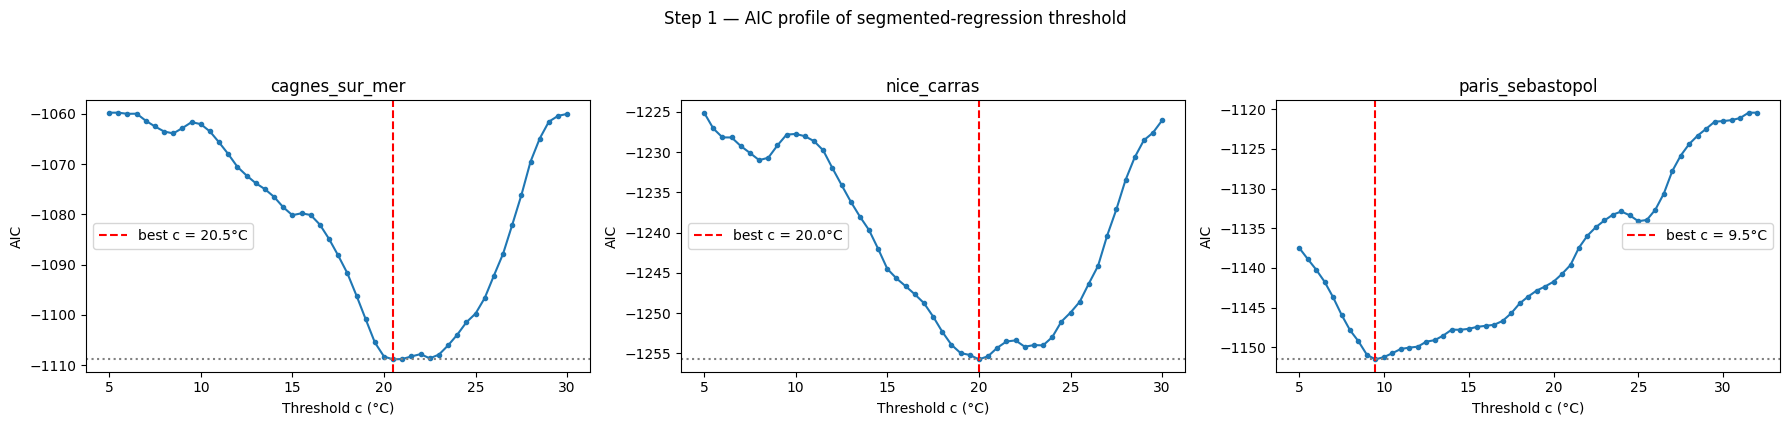

,counter,best_threshold,best_aic,n,threshold_at_grid_edge
0,cagnes_sur_mer,20.5,-1108.865804,1234,False
1,nice_carras,20.0,-1255.754215,1420,False
2,paris_sebastopol,9.5,-1151.523706,951,False


In [33]:
# Plot AIC profile to assess threshold identifiability
n_counters = len(step1_results)
fig, axes = plt.subplots(1, n_counters, figsize=(6 * n_counters, 4), sharey=False)

if n_counters == 1:
    axes = [axes]

for ax, counter_name in zip(axes, sorted(step1_results.keys())):
    prof = step1_results[counter_name]["aic_profile"].sort_values("threshold")
    best_c = step1_results[counter_name]["best_threshold"]
    best_aic = step1_results[counter_name]["best_aic"]
    ax.plot(prof["threshold"], prof["aic"], marker="o", ms=3)
    ax.axvline(best_c, color="red", linestyle="--", label=f"best c = {best_c:.1f}°C")
    ax.axhline(best_aic, color="gray", linestyle=":")
    ax.set_title(counter_name)
    ax.set_xlabel("Threshold c (°C)")
    ax.set_ylabel("AIC")
    ax.legend()

plt.suptitle("Step 1 — AIC profile of segmented-regression threshold", y=1.05)
plt.tight_layout()
plt.show()

# Simple summary table
step_1_raw = pd.DataFrame({
    "counter": list(step1_results.keys()),
    "best_threshold": [v["best_threshold"] for v in step1_results.values()],
    "best_aic": [v["best_aic"] for v in step1_results.values()],
    "n": [v["n"] for v in step1_results.values()],
    "threshold_at_grid_edge": [v["threshold_at_grid_edge"] for v in step1_results.values()],
}).sort_values("counter")

step_1_raw

While the values for South-Eastern France are in the expected range and look consistent with the assumed model, the value for Paris is more surprising. 

Let plot the model and observed values for each sample.
The following cell represents the following data :
* a scatter plot of the samples and the best model (selected threshold) prediction in the same conditions,
* a scatter plot of the model residuals for the samples,
* an histogram of the residual distribution, together with its adjusted gaussian (same mean and variance) distribution.

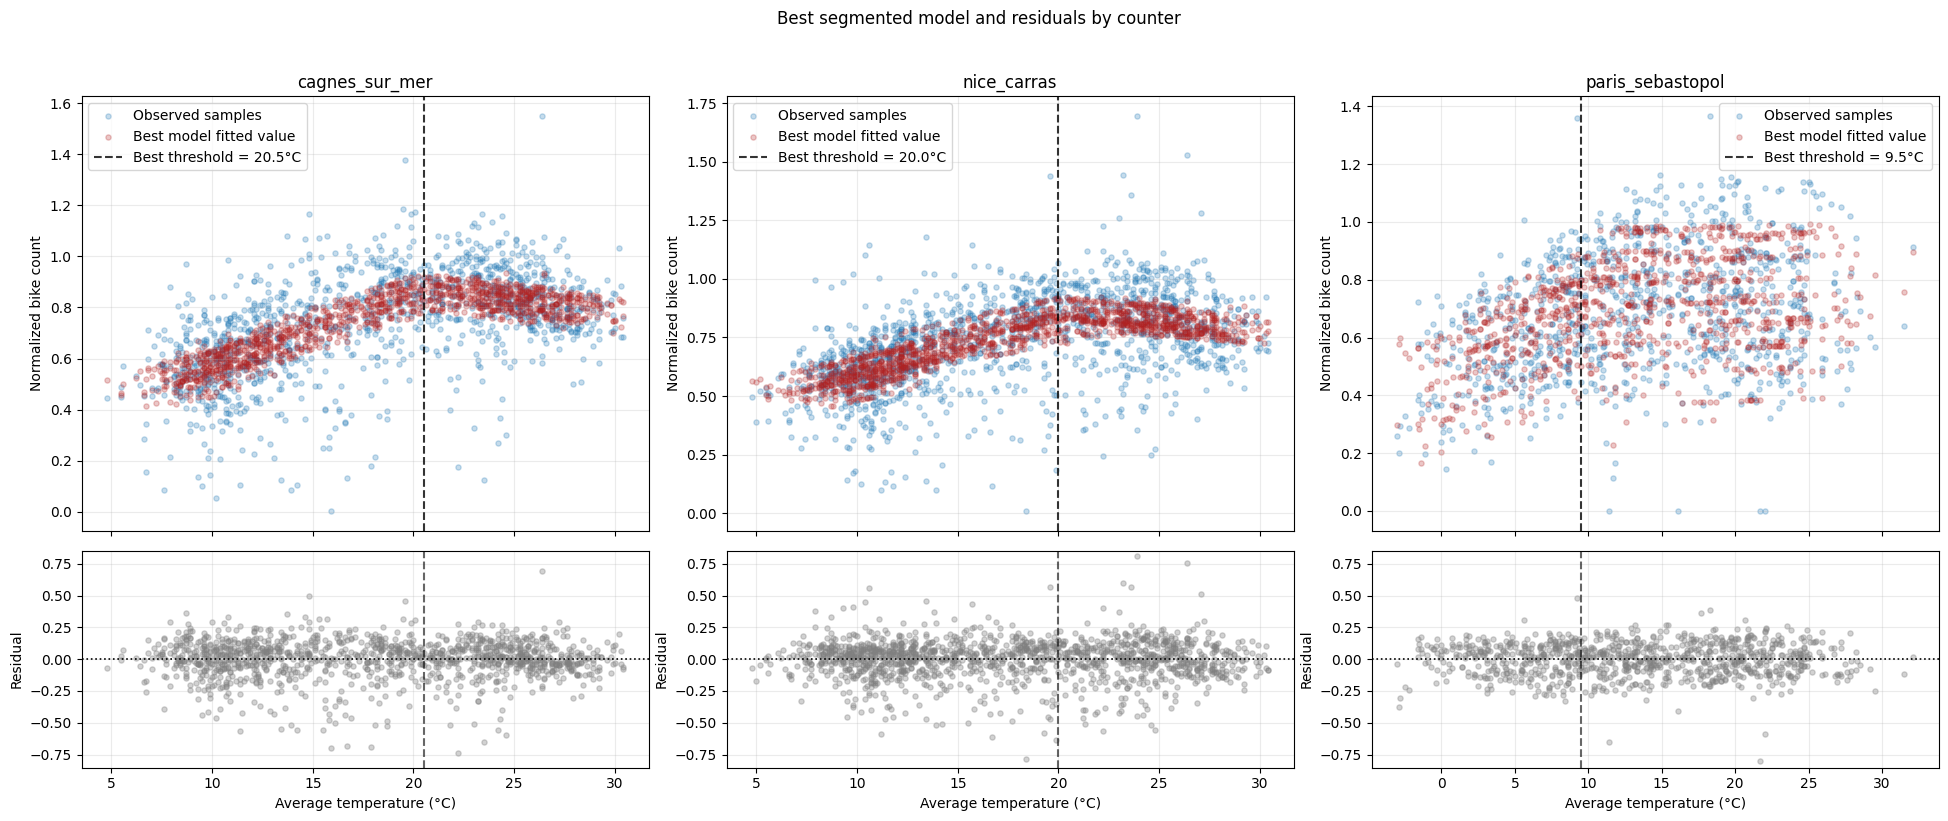

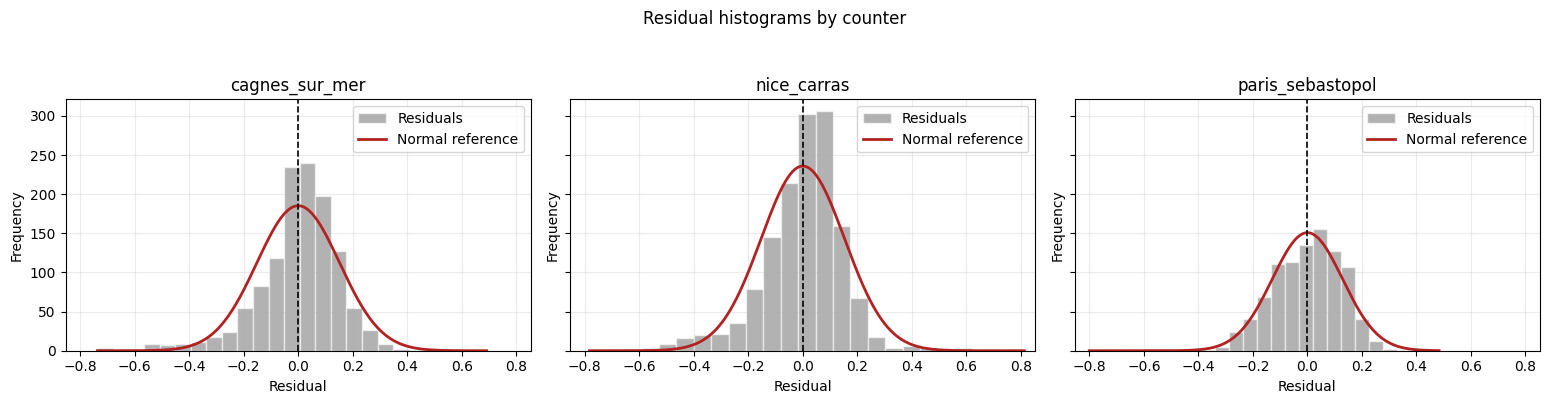

In [34]:
# Plot best segmented model fit vs observed samples for each counter
counter_list = sorted(step1_results.keys())

# Common residual scale to compare counters directly
residual_abs_max = max(
    np.nanmax(np.abs(step1_results[counter_name]["model"].resid))
    for counter_name in counter_list
)
resid_lim = 1.05 * residual_abs_max

fig, axes = plt.subplots(
    2,
    len(counter_list),
    figsize=(6.5 * len(counter_list), 8),
    sharex="col",
    squeeze=False,
    gridspec_kw={"height_ratios": [3, 1.5]}
)

for idx, counter_name in enumerate(counter_list):
    ax_model = axes[0, idx]
    ax_resid = axes[1, idx]

    subset = step1_data.loc[step1_data["counter"] == counter_name].copy()
    best_model = step1_results[counter_name]["model"]
    best_c = step1_results[counter_name]["best_threshold"]

    # Fitted values and residuals for each original sample
    fitted_vals = best_model.fittedvalues
    residuals = best_model.resid
    subset = subset.assign(fitted=fitted_vals, residual=residuals)
    subset_sorted = subset.sort_values("tavg")

    # Top row: observed vs fitted values
    ax_model.scatter(
        subset["tavg"],
        subset["normalized_count"],
        s=14,
        alpha=0.25,
        label="Observed samples",
    )
    ax_model.scatter(
        subset_sorted["tavg"],
        subset_sorted["fitted"],
        color="firebrick",
        s=14,
        alpha=0.25,
        label="Best model fitted value",
    )
    ax_model.axvline(
        best_c,
        color="black",
        linestyle="--",
        alpha=0.8,
        label=f"Best threshold = {best_c:.1f}°C",
    )
    ax_model.set_title(counter_name)
    ax_model.set_ylabel("Normalized bike count")
    ax_model.legend()
    ax_model.grid(alpha=0.25)

    # Bottom row: residuals below model plot
    ax_resid.scatter(
        subset["tavg"],
        subset["residual"],
        s=14,
        alpha=0.35,
        color="gray",
    )
    ax_resid.axhline(0, color="black", linestyle=":", linewidth=1.2)
    ax_resid.axvline(best_c, color="black", linestyle="--", alpha=0.6)
    ax_resid.set_ylim(-resid_lim, resid_lim)
    ax_resid.set_xlabel("Average temperature (°C)")
    ax_resid.set_ylabel("Residual")
    ax_resid.grid(alpha=0.25)

plt.suptitle("Best segmented model and residuals by counter", y=1.02)
plt.tight_layout()
plt.show()

# Separate residual histograms (one per counter)
fig_hist, axes_hist = plt.subplots(
    1,
    len(counter_list),
    figsize=(5.2 * len(counter_list), 3.8),
    sharey=True,
    squeeze=False,
    )
axes_hist = axes_hist[0]

for idx, counter_name in enumerate(counter_list):
    ax = axes_hist[idx]
    residuals = step1_results[counter_name]["model"].resid

    hist_counts, bin_edges, _ = ax.hist(
        residuals,
        bins=25,
        color="gray",
        alpha=0.6,
        edgecolor="white",
        label="Residuals",
    )

    mu = float(np.mean(residuals))
    sigma = float(np.std(residuals, ddof=1))
    if sigma > 0:
        x_grid = np.linspace(bin_edges[0], bin_edges[-1], 300)
        bin_width = float(bin_edges[1] - bin_edges[0])
        y_norm = scipy.stats.norm.pdf(x_grid, loc=mu, scale=sigma) * len(residuals) * bin_width
        ax.plot(x_grid, y_norm, color="firebrick", linewidth=2, label="Normal reference")

    ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
    ax.set_xlim(-resid_lim, resid_lim)
    ax.set_title(counter_name)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.25)
    ax.legend()

plt.suptitle("Residual histograms by counter", y=1.05)
plt.tight_layout()
plt.show()

From these graphs, the following can be observed : 
* As samples have various calendar and working status, modelled values show an expected spread around the affine trend.
* In the case of Paris, the vertical spread is very high compared with other locations. This makes the graph shape less obvious, but is consistent with a stronger effect of day of week and working status.
* The residuals distribution looks "decent" for all models, especially when one considers that this analysis is done on an a rather raw dataset which wasn't cured from manifest outliers. 
    * In particular, when looking for a model which describes the averaged effect of exogeneous parameters as done above, the data from SE France could be cleaned by removing many of the days with abnormally low counts. They result of the effect of other irrelevant exogeneous effects such as counter malfunction and special events such as races which lead to a road closure most of the day.
    * Despite this, the long left tail of the residuals for South-Eastern France deserves further investigation.


### Segmented regression decision metrics

The previous table provided the best threshold $c$ per counter (minimum AIC).
Now interpretable quantities, conveying information about how the bike count is affected by the weather can be extracted from the selected model, in particular:
- slope below threshold ($\beta_1$),
- slope above threshold ($\beta_1 + \beta_2$),
- slope change ($\beta_2$), with confidence intervals and p-values.

Discussion on the obtained values is postponed to the [conclusion of this section](#conclusion-about-segmented-regression).

In [35]:
# Step 1.4 - Extract coefficients and statistics from fitted models
step1_summary = []
for counter_name in sorted(step1_results.keys()):
    result = step1_results[counter_name]
    model = result["model"]
    best_c = result["best_threshold"]

    # Extract coefficients
    slope_below = model.params["tavg"]
    slope_change = model.params["tavg_hinge"]
    slope_above = slope_below + slope_change

    # Extract confidence intervals and p-values
    ci = model.conf_int(alpha=0.05)
    slope_below_ci_low = ci.loc["tavg", 0]
    slope_below_ci_high = ci.loc["tavg", 1]
    slope_change_ci_low = ci.loc["tavg_hinge", 0]
    slope_change_ci_high = ci.loc["tavg_hinge", 1]
    slope_above_ci_low = slope_below_ci_low + slope_change_ci_low
    slope_above_ci_high = slope_below_ci_high + slope_change_ci_high
    slope_change_pvalue = model.pvalues["tavg_hinge"]

    step1_summary.append({
        "counter": counter_name,
        "best_threshold_C": best_c,
        "n_samples": result["n"],
        "r2": model.rsquared,
        "slope_below": slope_below,
        "slope_below_ci_low": slope_below_ci_low,
        "slope_below_ci_high": slope_below_ci_high,
        "slope_above": slope_above,
        "slope_above_ci_low": slope_above_ci_low,
        "slope_above_ci_high": slope_above_ci_high,
        "slope_change_above_threshold": slope_change,
        "slope_change_ci_low": slope_change_ci_low,
        "slope_change_ci_high": slope_change_ci_high,
        "slope_change_pvalue": slope_change_pvalue,
    })

step1_summary = pd.DataFrame(step1_summary)
step1_summary

,counter,best_threshold_C,n_samples,r2,slope_below,slope_below_ci_low,slope_below_ci_high,slope_above,slope_above_ci_low,slope_above_ci_high,slope_change_above_threshold,slope_change_ci_low,slope_change_ci_high,slope_change_pvalue
0,cagnes_sur_mer,20.5,1234,0.396832,0.022510,0.015335,0.029684,-0.011674,-0.028398,0.005051,-0.034183,-0.043734,-0.024633,2.300167e-12
1,nice_carras,20.0,1420,0.345808,0.018322,0.012849,0.023794,-0.006709,-0.020893,0.007474,-0.025031,-0.033743,-0.016320,1.785077e-08
2,paris_sebastopol,9.5,951,0.631972,0.018654,0.013606,0.023701,0.001835,-0.009420,0.013090,-0.016819,-0.023026,-0.010611,1.093754e-07


The p-values and confidence intervals reported above are valid under the following assumptions (or close approximations):

- **Correct mean specification (conditional model)**: after including `tavg`, `tavg_hinge`, `working_status`, `day_name`, and `month`, the conditional mean structure is reasonably well specified.
- **Exogeneity / no major omitted confounders**: residual shocks should not be systematically correlated with included regressors (in particular with temperature and hinge terms).
- **Independent observations (or weak enough dependence)**: HC3 robust covariance protects against heteroskedasticity, but it does not fully correct serial autocorrelation in daily time series.
- **Sufficient sample size**: inference is asymptotic; with many daily observations this is usually acceptable, but small effective sample size from temporal dependence can reduce reliability.

These assumptions seem reasonable enough in the context of this section, which just aims at deciding whether an inflexion of the bike count at high temperature is plausible or not.
Deciding the right model and fine-tuning the choice of input features will be the subject of future work.

_Note : In particular, regarding observation independance, the assumption is likely a bit loose. While part of the serial autocorrelation in the data is likely explainable by the weather and calendar, accounted for in the model, part of it is expected to remain. The effect of change in the bike culture and bike infrastructure, in particular in Paris, should likely introduce a temporal trend which was not accouted for by the model which mixes data collected from 2021 to 2026._

Also, the uncertainty about the actual value of the temperature threshold, assuming the model is correct, is not accounted for in the inference metrics computation (this study isn't pushed up to a nice and clean bayesian UQ), which should be kept in mind when interpreting the values.

### Additional insights of segmented regression

While only thermosensitivity coefficient values are discussed below, interesting insight can be found from a quick look at other coefficients in the models.

See the summary of the model for Nice and Paris below : 

In [36]:
step1_results['nice_carras']['model'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       normalized_count   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     45.62
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          7.21e-142
Time:                        20:58:03   Log-Likelihood:                 649.88
No. Observations:                1420   AIC:                            -1256.
Df Residuals:                    1398   BIC:                            -1140.
Df Model:                          21                                         
Covariance Type:                  HC3                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           0.3797      0.039      9.746      0.000       0.303       0.456
C(working_status)[T.vacations]     -0.0112      0.030     -0.375      0.707      -0.070       0.047
C(working_status)[T.normal_day]     0.0286      0.029      0.971      0.331      -0.029       0.086
C(day_name)[T.Tuesday]              0.0696      0.014      5.026      0.000       0.042       0.097
C(day_name)[T.Wednesday]            0.0301      0.015      2.038      0.042       0.001       0.059
C(day_name)[T.Thursday]             0.0610      0.015      3.970      0.000       0.031       0.091
C(day_name)[T.Friday]              -0.0101      0.014     -0.721      0.471      -0.038       0.017
C(day_name)[T.Saturday]            -0.0212      0.013     -1.593      0.111      -0.047       0.005
C(day_name)[T.Sunday]              -0.0196      0.016     -1.204      0.229      -0.052       0.012
C(month)[T.February]                0.0072      0.018      0.399      0.690      -0.028       0.043
C(month)[T.March]                   0.0065      0.022      0.304      0.761      -0.036       0.049
C(month)[T.April]                   0.0720      0.026      2.817      0.005       0.022       0.122
C(month)[T.May]                     0.0748      0.033      2.269      0.023       0.010       0.139
C(month)[T.June]                    0.0795      0.035      2.285      0.022       0.011       0.148
C(month)[T.July]                    0.1030      0.042      2.459      0.014       0.021       0.185
C(month)[T.August]                  0.0808      0.042      1.936      0.053      -0.001       0.163
C(month)[T.September]               0.0721      0.037      1.955      0.051      -0.000       0.144
C(month)[T.October]                 0.0174      0.034      0.510      0.610      -0.050       0.084
C(month)[T.November]                0.0239      0.023      1.044      0.296      -0.021       0.069
C(month)[T.December]               -0.0491      0.016     -3.074      0.002      -0.080      -0.018
tavg                                0.0183      0.003      6.562      0.000       0.013       0.024
tavg_hinge                         -0.0250      0.004     -5.632      0.000      -0.034      -0.016
==============================================================================
Omnibus:                      176.700   Durbin-Watson:                   1.297
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              685.403
Skew:                          -0.554   Prob(JB):                    1.47e-149
Kurtosis:                       6.218   Cond. No.                         412.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [37]:
step1_results['paris_sebastopol']['model'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       normalized_count   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     90.03
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          5.23e-207
Time:                        20:58:03   Log-Likelihood:                 597.76
No. Observations:                 951   AIC:                            -1152.
Df Residuals:                     929   BIC:                            -1045.
Df Model:                          21                                         
Covariance Type:                  HC3                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           0.2198      0.030      7.303      0.000       0.161       0.279
C(working_status)[T.vacations]      0.1578      0.026      6.079      0.000       0.107       0.209
C(working_status)[T.normal_day]     0.2947      0.025     11.986      0.000       0.247       0.343
C(day_name)[T.Tuesday]              0.0792      0.015      5.352      0.000       0.050       0.108
C(day_name)[T.Wednesday]            0.0657      0.016      4.113      0.000       0.034       0.097
C(day_name)[T.Thursday]             0.0839      0.017      5.054      0.000       0.051       0.116
C(day_name)[T.Friday]               0.0016      0.016      0.099      0.921      -0.030       0.033
C(day_name)[T.Saturday]            -0.0753      0.014     -5.233      0.000      -0.103      -0.047
C(day_name)[T.Sunday]              -0.1839      0.013    -14.207      0.000      -0.209      -0.159
C(month)[T.February]                0.0527      0.022      2.451      0.014       0.011       0.095
C(month)[T.March]                   0.0316      0.023      1.355      0.176      -0.014       0.077
C(month)[T.April]                   0.0234      0.028      0.845      0.398      -0.031       0.078
C(month)[T.May]                     0.0899      0.026      3.492      0.000       0.039       0.140
C(month)[T.June]                    0.1624      0.029      5.590      0.000       0.105       0.219
C(month)[T.July]                    0.0848      0.036      2.365      0.018       0.015       0.155
C(month)[T.August]                 -0.0092      0.033     -0.278      0.781      -0.074       0.055
C(month)[T.September]               0.1897      0.028      6.776      0.000       0.135       0.245
C(month)[T.October]                 0.1996      0.026      7.749      0.000       0.149       0.250
C(month)[T.November]                0.1061      0.023      4.673      0.000       0.062       0.151
C(month)[T.December]                0.0103      0.020      0.505      0.614      -0.030       0.050
tavg                                0.0187      0.003      7.244      0.000       0.014       0.024
tavg_hinge                         -0.0168      0.003     -5.310      0.000      -0.023      -0.011
==============================================================================
Omnibus:                       96.133   Durbin-Watson:                   0.522
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              220.199
Skew:                          -0.582   Prob(JB):                     1.53e-48
Kurtosis:                       5.050   Cond. No.                         282.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

While the residual metrics indicate that the OLS model assumptions are not fully satisfied (e.g. Durbin-Watson indicates an autocorrelation, and other metrics indicate heavier tails than normal distribution, as already discussed), the analysis of the coefficients and their associated statistics complement the plots that were done in the previous sections to get an insight of the effect of other parameters.

Detailed analysis is out of the scope here but could be interesting on a future, better fitted model.
**The tables above are conserved for curious readers.**

## Conclusion about segmented regression 

The segmented-regression test provides evidence that thermosensitivity changes above a threshold in all three counters (negative and significant hinge coefficient $\beta_2$).

For non-rainy days, controlling for `working_status`, `day_name` and `month` with a simple linear addidtive effect :
- **Cagnes-sur-Mer**: best threshold around **20.5°C**. Estimated slope changes from about **+0.0225** below threshold to **-0.0117** above threshold. This supports a real high-temperature decline.
- **Nice Carras**: best threshold around **20.0°C**. Estimated slope changes from about **+0.0183** below threshold to **-0.0067** above threshold. This also supports a high-temperature decline.
- **Paris Sebastopol**: best threshold around **9.5°C**. The slope change is negative _and significant_, but the high-temperature slope remains close to zero/slightly positive (**+0.0018**, CI crossing 0). So this test does not support a clear drop in Paris at high temperatures, but rather a flattening, right from the moment the temperature becomes "not too cold". Recalling the comparison with energy consumption at [the beginning of this section](#high-temperature-effect-with-segmented-regression), this could just be be a limit of this simple one-threshold affine model.

Overall the collected evidence are consistent with the following assumptions about bike counts evolution :
1. On the French Riviera counters, results are consistent with the hypothesis 
   * the number of cyclists increses with temperature up to ~20°C;
   * “beyond ~20°C, higher temperature leads to fewer cyclists.
2. In Paris Sebastopol :
   * the number of cyclists increses with temperature up to ~10°C;
   * beyond this threshold, the number of cyclists more or less stops increasing with temperature. 

Of course many more steps would need to be added to improve the analysis in order to get a trustworthy model : data cleaning, AIC comparison with plain linear model, investigation of the potential effects of interaction, maybe restricting to different years, accounting for samples temporal correlation  etc.

All this is saved for later work, with more application focused models. 

# Including the effect of rain

In the previous investigation about the effect of temperature, the effect of rain on the count of cyclists was not considered by working on non-rainy days only. 
Yet, as could be guessed from the plots in the [first visual exploration of the effect of weather](#investigating-the-effect-of-weather), the counts of cyclists seem to drop on rainy days VS sunny ones. 

Accordingly, this section investigates how rain affects the counts of cyclists, besides the effect of temperature identified above. 
As discussed for other exogeneous parameters, the effect of rain could be be of different natures : 
* a certain _propotion_ of the road users could chose to cycle or not depending on the rain;
* a certain _number_ of them could chose to cycle or not depending on the rain;
* rain could affect the slope of the thermosensitivity and/or the temeprature threshold;
* all this could depend or not on the other exogeneous parameters, e.g. more cyclists could keep riding on working days than vacation days;
* all this could depend on the _amount_ of rain (value of `prcp` as a continuous variable) or just on the _fact_ that it rains or not (rain as a categorical variable).

Following an idea that the simpler, the better : 
* this study starts by investigating the effect of rain as a simple additive factor besides others;
* interactions with temperature and hinge temperature are considered to look for an effect of rain on the thermosensitivity;

Some features are left aside on purpose for the sake of simplicity : 
* More complex interactions aren't considered for now, enabling e.g. to adapt the thermosensitivity for different rain and working days to not.
* An adaptation of the temperature threshold depening on the rain is also not considered.

Future work, which could combine data from different counters in the same area could be used to push this investigation further if deemed necessary.

For now, this section investigates the effect of rain in the following way : 
* First the dataset is reprepared to include the rainy days in the model fitting data. This is also the opportunity to look a bit more in detail at the amount of data it contains about rainy conditions.
* Then a ladder of models is fitted, that include rain as a _continuous variable_ and its interactions with temperature and hinge temperature in a progressive way.


Including rain as a _categorical variable_ was also considered on the best performing formulation, but is considered out of scope for now.


## Preparing the rain-analysis dataset

The dataset used in this part of the study is built, as in the previous sectsion from the exploration table, keeping the selected counters and the variables needed for modeling (`normalized_count`, `tavg`, `prcp`, `working_status`, `day_name`, `month`).

The cell below builds two quick diagnostics: one for missingness/sample retention, and one for rain distribution by counter.

In [38]:
# Start from the exploration dataset used in previous sections

# --- Missingness and sample accounting per counter ---
rows = []
for counter_name, grp in raw_step1_data_with_rain.groupby("counter", sort=True):
    n_total = len(grp)
    n_complete = int(grp.notna().all(axis=1).sum())
    rows.append({
        "counter": counter_name,
        "n_total": n_total,
        "n_complete": n_complete,
        "complete_rate_pct": 100 * n_complete / n_total if n_total else np.nan,
        "missing_count_pct": 100 * grp["normalized_count"].isna().mean(),
        "missing_tavg_pct": 100 * grp["tavg"].isna().mean(),
        "missing_prcp_pct": 100 * grp["prcp"].isna().mean(),
        "missing_working_status_pct": 100 * grp["working_status"].isna().mean(),
        "missing_day_name_pct": 100 * grp["day_name"].isna().mean(),
        "missing_month_pct": 100 * grp["month"].isna().mean(),
    })

rain_step1_qc_counts = pd.DataFrame(rows).sort_values("counter").reset_index(drop=True)

print("Step R1 - QC summary")
print(f"Counters: {', '.join(bike_counters)}")
print(f"Raw rows (selected counters): {len(step1_data_with_rain):,}")
print(f"Complete-case rows (common base for ladder): {raw_step1_data_with_rain.shape[0]:,}")

rain_step1_qc_counts.round(2)

Step R1 - QC summary
Counters: cagnes_sur_mer, nice_carras, paris_sebastopol
Raw rows (selected counters): 5,323
Complete-case rows (common base for ladder): 5,418


,counter,n_total,n_complete,complete_rate_pct,missing_count_pct,missing_tavg_pct,missing_prcp_pct,missing_working_status_pct,missing_day_name_pct,missing_month_pct
0,cagnes_sur_mer,1694,1603,94.63,5.37,0.0,0.0,0.0,0.0,0.0
1,nice_carras,1858,1854,99.78,0.22,0.0,0.0,0.0,0.0,0.0
2,paris_sebastopol,1866,1866,100.00,0.00,0.0,0.0,0.0,0.0,0.0


Sample retention is globally high.
Most losses come from missing `normalized_count` in Cagnes-sur-Mer, while weather and calendar controls are almost complete.

So using a common complete-case base for the ladder is reasonable.
As usual, if missing outcomes are not random, some bias may still remain.

Before adding interactions, it is useful to inspect the raw precipitation structure.
The next table reports rainy-day prevalence and intensity quantiles on the same complete-case sample.

In [39]:
# Step R1 - Rain distribution table on complete-case sample
# --- Rain distribution per counter on complete-case sample ---
rain_rows = []
for counter_name, grp in raw_step1_data_with_rain.groupby("counter", sort=True):
    rainy_mask = grp["prcp"] > 0
    rainy = grp.loc[rainy_mask, "prcp"]
    rain_rows.append({
        "counter": counter_name,
        "nobs_complete": len(grp),
        "n_rainy": int(rainy_mask.sum()),
        "rainy_share_pct": 100 * rainy_mask.mean() if len(grp) else np.nan,
        "prcp_zero_share_pct": 100 * (grp["prcp"] == 0).mean() if len(grp) else np.nan,
        "prcp_mean_all": grp["prcp"].mean(),
        "prcp_q50_rainy": rainy.quantile(0.50) if len(rainy) else np.nan,
        "prcp_q90_rainy": rainy.quantile(0.90) if len(rainy) else np.nan,
        "prcp_q95_rainy": rainy.quantile(0.95) if len(rainy) else np.nan,
        "prcp_max": grp["prcp"].max(),
    })

rain_step1_qc_rain = pd.DataFrame(rain_rows).sort_values("counter").reset_index(drop=True)

rain_step1_qc_rain.round(3)

,counter,nobs_complete,n_rainy,rainy_share_pct,prcp_zero_share_pct,prcp_mean_all,prcp_q50_rainy,prcp_q90_rainy,prcp_q95_rainy,prcp_max
0,cagnes_sur_mer,1694,388,22.904,77.096,1.817,2.8,23.46,31.13,110.0
1,nice_carras,1858,434,23.358,76.642,1.844,2.8,23.81,31.07,110.0
2,paris_sebastopol,1866,915,49.035,50.965,1.881,1.6,10.10,13.70,73.6


Rain appears on roughly one quarter of days in Cagnes-sur-Mer and Nice Carras, and on about half of days in Paris Sebastopol.
So dry days still dominate in the Riviera counters, with a strong mass at `prcp = 0`.

At the same time, rainy-day upper quantiles show that intense events are present, and that rain distribution differs between locations.
This supports starting with continuous `prcp`, then checking robustness with a categorical sensitivity analysis.

The threshold values selected earlier in the non-rainy segmented-temperature section are recalled below.
They are needed to build the hinge term used in the interaction models.

In [40]:
# Fixed segmented thresholds carried from previous section
rain_selected_thresholds = step1_summary.loc[:,['counter', 'best_threshold_C']].sort_values("counter").reset_index(drop=True)
rain_selected_thresholds

,counter,best_threshold_C
0,cagnes_sur_mer,20.5
1,nice_carras,20.0
2,paris_sebastopol,9.5


These values are used as fixed counter-specific breakpoints for $H=(T-c)_+$.
Keeping `c` fixed here helps isolate rain-effect estimation from extra threshold-search uncertainty.

At this point, the rain-analysis sample is defined for all counters.
So the model ladder can be compared on a consistent complete-case base, while keeping key limitations in mind.

Main points to carry forward:
- missingness is mostly on the response variable, especially in Cagnes-sur-Mer;
- precipitation is strongly zero-heavy, with clear differences in rainy-day prevalence and rain intensities across counters;
- threshold values from the previous section are available and fixed for hinge construction.

This gives a coherent starting point for rain-temperature interaction modeling in the next part.

## Constructing the threshold-linked temperature term

To model interactions, a counter-specific hinge term for temperature is needed for each counter: $H=(T-c)_+$, with $c$ fixed from the previous segmented-temperature analysis.

This keeps the focus on how rain modifies slopes, without reopening threshold selection at this stage.

In practice, this transformation is applied on the complete-case dataset built above, so later model comparisons stay valid within each counter.

A quick quality check then confirms that the transformed term behaves as expected before fitting the ladder.

The construction is considered valid if `nobs_diff = 0` (no data is lost VS the dataset of step 1 before removing rainy days) for all counters, thresholds are all mapped, and hinge activation remains coherent with local temperature ranges.

The resulting dataset (`rain_step2_data`) is the fixed input base for the continuous-rain ladder.

In [41]:
# Build counter-specific hinge term H = (T - c)_+ on complete-case sample
rain_step2_data = raw_step1_data_with_rain.copy().dropna()

threshold_map = rain_selected_thresholds.set_index('counter')["best_threshold_C"]

rain_step2_data["threshold_c"] = rain_step2_data["counter"].map(threshold_map)
rain_step2_data["tavg_hinge"] = (rain_step2_data["tavg"] - rain_step2_data["threshold_c"]).clip(lower=0.0)

# Guardrail checks
if rain_step2_data["threshold_c"].isna().any():
    missing_counters = sorted(rain_step2_data.loc[rain_step2_data["threshold_c"].isna(), "counter"].unique())
    raise ValueError(f"Missing threshold assignment for counters: {missing_counters}")

if (rain_step2_data["tavg_hinge"] < 0).any():
    raise ValueError("Negative hinge values detected, which should be impossible by construction.")

The hinge term is now built by mapping each counter threshold and computing `tavg_hinge = max(tavg - c, 0)` row by row.

The check table right after this cell is there to verify three things quickly:
- threshold mapping is complete;
- sample size is unchanged compared with the complete-case base;
- hinge activation shares look plausible for each counter.

In [42]:
# QC table for threshold-linked hinge construction
rows_hinge = []
for counter_name, grp in rain_step2_data.groupby("counter", sort=True):
    nobs_current = len(grp)
    nobs_base = int((step1_data_with_rain["counter"] == counter_name).sum())
    hinge_active = grp["tavg_hinge"] > 0

    rows_hinge.append({
        "counter": counter_name,
        "threshold_c": grp["threshold_c"].iloc[0],
        "nobs_base": nobs_base,
        "nobs_current": nobs_current,
        "nobs_diff": nobs_current - nobs_base,
        "share_hinge_active_pct": 100 * hinge_active.mean(),
        "tavg_min": grp["tavg"].min(),
        "tavg_median": grp["tavg"].median(),
        "tavg_max": grp["tavg"].max(),
        "hinge_max": grp["tavg_hinge"].max(),
    })

rain_step2_hinge_qc = pd.DataFrame(rows_hinge).sort_values("counter").reset_index(drop=True)
rain_step2_hinge_qc.round(3)

,counter,threshold_c,nobs_base,nobs_current,nobs_diff,share_hinge_active_pct,tavg_min,tavg_median,tavg_max,hinge_max
0,cagnes_sur_mer,20.5,1603,1603,0,36.432,4.8,17.4,30.4,9.9
1,nice_carras,20.0,1854,1854,0,34.736,4.8,16.4,30.4,10.4
2,paris_sebastopol,9.5,1866,1866,0,68.060,-3.0,12.7,32.1,22.6


## Continuous-rain interaction ladder

Using the fixed complete-case dataset, a five-model ladder is now fitted independently for each counter:
- M0: baseline segmented temperature model with calendar controls,
- M1: M0 + continuous precipitation,
- M2: M1 + `prcp:tavg`,
- M3: M1 + `prcp:tavg_hinge`,
- M4: M1 + both interactions.

At this stage, the goal is only to fit all models on a consistent sample before comparing them formally.

In [43]:
# Fit continuous-rain model ladder (M0 -> M4) per counter on fixed sample
rain_step3_ladder_formulas = {
    "M0": "normalized_count ~ tavg + tavg_hinge + C(working_status) + C(day_name) + C(month)",
    "M1": "normalized_count ~ tavg + tavg_hinge + prcp + C(working_status) + C(day_name) + C(month)",
    "M2": "normalized_count ~ tavg + tavg_hinge + prcp + prcp:tavg + C(working_status) + C(day_name) + C(month)",
    "M3": "normalized_count ~ tavg + tavg_hinge + prcp + prcp:tavg_hinge + C(working_status) + C(day_name) + C(month)",
    "M4": "normalized_count ~ tavg + tavg_hinge + prcp + prcp:tavg + prcp:tavg_hinge + C(working_status) + C(day_name) + C(month)",
}

rain_step3_results = {}
fit_rows = []

required_cols_step3 = [
    "normalized_count", "tavg", "tavg_hinge", "prcp",
    "working_status", "day_name", "month",
]

for counter_name, grp in rain_step2_data.groupby("counter", sort=True):
    model_df = grp.dropna(subset=required_cols_step3).copy()
    n_input = len(model_df)
    rain_step3_results[counter_name] = {}

    for model_name, formula in rain_step3_ladder_formulas.items():
        fitted = smf.ols(formula=formula, data=model_df).fit()
        rain_step3_results[counter_name][model_name] = {
            "formula": formula,
            "model": fitted,
            "nobs": int(fitted.nobs),
        }
        fit_rows.append({
            "counter": counter_name,
            "model": model_name,
            "n_input": n_input,
            "nobs": int(fitted.nobs),
            "nobs_match_input": int(fitted.nobs) == n_input,
            "df_model": float(fitted.df_model),
        })

rain_step3_fit_status = pd.DataFrame(fit_rows).sort_values(["counter", "model"]).reset_index(drop=True)
rain_step3_fit_status

,counter,model,n_input,nobs,nobs_match_input,df_model
0,cagnes_sur_mer,M0,1603,1603,True,21.0
1,cagnes_sur_mer,M1,1603,1603,True,22.0
2,cagnes_sur_mer,M2,1603,1603,True,23.0
3,cagnes_sur_mer,M3,1603,1603,True,23.0
4,cagnes_sur_mer,M4,1603,1603,True,24.0
5,nice_carras,M0,1854,1854,True,21.0
6,nice_carras,M1,1854,1854,True,22.0
7,nice_carras,M2,1854,1854,True,23.0
8,nice_carras,M3,1854,1854,True,23.0
9,nice_carras,M4,1854,1854,True,24.0


Detailed comparison metrics (AIC/BIC/$R^2$/delta-AIC) are shown just after.
At this point, fitting is considered valid for this comaprison if all five models are estimated for each counter on the same observation set (`nobs` unchanged inside each ladder).
(The contrary would be surprising, this is done as a sanity check to ensure there is no loss anywhere as a side effect).

## Comparing model performance within each ladder

Model quality is compared within each counter using `AIC`, `BIC`, $R^2$, adjusted $R^2$, and `nobs`.
To keep the reading local to each extension, AIC gain is expressed against the direct parent model (`delta_aic_vs_parent = AIC_child - AIC_parent`).

So negative values mean the child model improves AIC compared with its parent.

In [44]:
# Model-comparison table: AIC/BIC/R2/nobs and delta-AIC vs parent
parent_map = {
    "M0": None,
    "M1": "M0",
    "M2": "M1",
    "M3": "M1",
    "M4": "M1",
}

comparison_rows = []
for counter_name, models_dict in rain_step3_results.items():
    for model_name in ["M0", "M1", "M2", "M3", "M4"]:
        fitted = models_dict[model_name]["model"]
        parent_name = parent_map[model_name]

        if parent_name is None:
            delta_aic = np.nan
        else:
            delta_aic = fitted.aic - models_dict[parent_name]["model"].aic

        comparison_rows.append({
            "counter": counter_name,
            "model": model_name,
            "parent_model": parent_name,
            "nobs": int(fitted.nobs),
            "aic": float(fitted.aic),
            "bic": float(fitted.bic),
            "r2": float(fitted.rsquared),
            "r2_adj": float(fitted.rsquared_adj),
            "delta_aic_vs_parent": float(delta_aic) if pd.notna(delta_aic) else np.nan,
        })

rain_step4_model_comparison = (
    pd.DataFrame(comparison_rows)
      .sort_values(["counter", "model"])
      .reset_index(drop=True)
)

rain_step4_model_comparison.round(4)

,counter,model,parent_model,nobs,aic,bic,r2,r2_adj,delta_aic_vs_parent
0,cagnes_sur_mer,M0,None,1603,-701.8628,-583.5109,0.3275,0.3185,NaN
1,cagnes_sur_mer,M1,M0,1603,-893.8369,-770.1053,0.4041,0.3958,-191.9741
2,cagnes_sur_mer,M2,M1,1603,-892.7257,-763.6145,0.4045,0.3958,1.1112
3,cagnes_sur_mer,M3,M1,1603,-901.7731,-772.6619,0.4078,0.3992,-7.9362
4,cagnes_sur_mer,M4,M1,1603,-917.9458,-783.4550,0.4145,0.4056,-24.1090
5,nice_carras,M0,None,1854,-965.2323,-843.6801,0.3243,0.3165,NaN
6,nice_carras,M1,M0,1854,-1144.3393,-1017.2620,0.3871,0.3798,-179.1070
7,nice_carras,M2,M1,1854,-1142.4817,-1009.8793,0.3872,0.3795,1.8576
8,nice_carras,M3,M1,1854,-1157.8262,-1025.2238,0.3922,0.3846,-13.4869
9,nice_carras,M4,M1,1854,-1166.3776,-1028.2501,0.3957,0.3878,-22.0383


Comparing the metrics value for the model ladder in all cases, accounting for precipitations, as well as the interactions bewteen precipitations and temperatures seems better in all cases.

While the M4 model clearly outperforms other ones in Nice and Cagnes-sur-Mer, the result is not as obvious in Paris, where its performance metrics are very close to those of M3.

In what follows, only one formulation is conserved and M4 is used for all counters.

In [45]:
# Select one model per counter from the continuous ladder (minimum AIC)
rain_step5_shortlist = (
    rain_step4_model_comparison.query("model == 'M4'").loc[:, ["counter", "model", "aic", "bic", "r2", "nobs"]]
    .sort_values("counter")
    .reset_index(drop=True)
)

print("Selected model per counter (min AIC):")
rain_step5_shortlist


Selected model per counter (min AIC):


,counter,model,aic,bic,r2,nobs
0,cagnes_sur_mer,M4,-917.945835,-783.455031,0.414486,1603
1,nice_carras,M4,-1166.377581,-1028.250062,0.395692,1854
2,paris_sebastopol,M4,-2061.550256,-1923.261446,0.588887,1866


## Reading rain and interaction mechanisms in the continuous-rain models

The selected M4 model uses the following formulation, including daily precipitation volume $p$ and its interaction with temperatures :
$$
\text{normalized\_count}_t = \beta_0 + (\beta_1 + \omega_{1,p}.p) T_t + (\beta_2 + \omega_{2,p}.p) (T_t-c)_+ + \omega_p p + \gamma^\top X_t + \varepsilon_t
$$

The term for the `prcp` variable ($\omega_p$) indicates how rain affects the bike counts on average, whatever the temperature.

Then, to read how rain modifies thermosensitivity, in the selected models, the two key interaction terms have to be retrieved:
- `prcp:tavg`, read as a modification of baseline thermosensitivity depending on the amount of precipitation;
- `prcp:tavg_hinge`, read as a modification of the additional post-threshold slope depending on the amount of precipitation.


The table reports coefficients, 95% confidence intervals, and p-values as a first mechanism-oriented reading before robustness checks.

In [46]:
# First-pass interpretation table for interaction mechanisms
interaction_terms = ["prcp:tavg", "prcp:tavg_hinge"]
rain_terms = ["prcp", "prcp:tavg", "prcp:tavg_hinge"]

rows_mech = []
for _, row in rain_step5_shortlist.iterrows():
    counter_name = row["counter"]
    model_name = row["model"]
    fitted = rain_step3_results[counter_name][model_name]["model"]
    ci = fitted.conf_int()

    for term in rain_terms:
        if term in fitted.params.index:
            rows_mech.append({
                "counter": counter_name,
                "selected_model": model_name,
                "term": term,
                "coef": float(fitted.params[term]),
                "ci_low": float(ci.loc[term, 0]),
                "ci_high": float(ci.loc[term, 1]),
                "pvalue": float(fitted.pvalues[term]),
            })
        else:
            rows_mech.append({
                "counter": counter_name,
                "selected_model": model_name,
                "term": term,
                "coef": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "pvalue": np.nan,
            })

rain_step5_interaction_effects = pd.DataFrame(rows_mech)

In [47]:
# rain and Interaction coefficients for mechanism reading
rain_step5_interaction_effects.round(4)

,counter,selected_model,term,coef,ci_low,ci_high,pvalue
0,cagnes_sur_mer,M4,prcp,0.0013,-0.0042,0.0068,0.6414
1,cagnes_sur_mer,M4,prcp:tavg,-0.0009,-0.0013,-0.0005,0.0000
2,cagnes_sur_mer,M4,prcp:tavg_hinge,0.0061,0.0038,0.0085,0.0000
3,nice_carras,M4,prcp,-0.0010,-0.0062,0.0041,0.6913
4,nice_carras,M4,prcp:tavg,-0.0006,-0.0010,-0.0003,0.0013
5,nice_carras,M4,prcp:tavg_hinge,0.0049,0.0030,0.0068,0.0000
6,paris_sebastopol,M4,prcp,-0.0115,-0.0206,-0.0024,0.0136
7,paris_sebastopol,M4,prcp:tavg,-0.0005,-0.0016,0.0006,0.3488
8,paris_sebastopol,M4,prcp:tavg_hinge,0.0014,0.0000,0.0027,0.0422


Value for the `prcp` term :
* It indicates how the count changes globally depending on the precipitation. 
* A positive value indicates that rain increases the baseline number of cyclists, while a negative value indicates a decrease.
* When multiplied by the height of the precipitations in the day in mm (see the typical values in the table in [the dataset preparation](#preparing-the-rain-analysis-dataset)), it expresses this number as normalized count.
* This number itself should be multiplied by the 95% of the counter quantile to get a number of cyclists.


Value of the interaction terms : 
* `prcp:tavg` indicates how the precipitation value changes the baseline thermosensitivity of the bike count.
* `prcp:tavg_hinge` term indicates how the precipitation value affects the thermosensitivity after the hinge threshold.

A few observations can be made right away from this table. According to this model, rain seems to mainly affect the counts of cylists :
* in **South-Eastern France** by an **evolution of the thermosensitivity**.
* in **Paris Sebastopol** by a (significant) **shift which appears whatever the temperature**, combined with a moderate and unsure (low confidence) evolution of the thermosensitivity.

For now, this is rather consistent with the qualitative observations from [the visual exploration](#investigating-the-effect-of-weather).

#### Translating coefficient values into "cyclists"


In order to make these coefficients more interpretable, the following tables can be computed, which transform these values in normalized counts or in number of cyclists.

In [48]:
# Additional slope view for selected models
slope_rows = []
for _, row in rain_step5_shortlist.iterrows():
    counter_name = row["counter"]
    model_name = row["model"]
    fitted = rain_step3_results[counter_name][model_name]["model"]

    beta_t = float(fitted.params.get("tavg", np.nan))
    beta_h = float(fitted.params.get("tavg_hinge", np.nan))
    beta_pt = float(fitted.params.get("prcp:tavg", np.nan))
    beta_ph = float(fitted.params.get("prcp:tavg_hinge", np.nan))
    beta_p = float(fitted.params.get("prcp", np.nan))

    slope_rows.append({
        "counter": counter_name,
        "dry_slope_below_c_baseline": beta_t,
        "dry_slope_above_c": beta_t + beta_h,
        "1mm_rain_baseline": beta_p,
        "1mm_rain_slope_below_c": beta_pt + beta_t,
        "1mm_rain_slope_above_c": beta_pt + beta_ph + beta_t + beta_h,
        "5mm_rain_baseline": 5 * beta_p,
        "5mm_rain_slope_below_c": 5 * beta_pt + beta_t,
        "5mm_rain_slope_above_c": 5 * beta_pt + 5 * beta_ph + beta_t + beta_h,
    })

rain_step5_slope_view = pd.DataFrame(slope_rows).sort_values("counter").reset_index(drop=True).set_index("counter")

In [49]:
# Slope decomposition in selected models
print("Thermosensitivity and effect of 1mm and 5mm of rain for each model on the normalized count.")
rain_step5_slope_view.round(4)

Thermosensitivity and effect of 1mm and 5mm of rain for each model on the normalized count.


,dry_slope_below_c_baseline,dry_slope_above_c,1mm_rain_baseline,1mm_rain_slope_below_c,1mm_rain_slope_above_c,5mm_rain_baseline,5mm_rain_slope_below_c,5mm_rain_slope_above_c
counter,,,,,,,,
cagnes_sur_mer,0.0205,-0.0081,0.0013,0.0196,-0.0029,0.0065,0.0161,0.0182
nice_carras,0.0193,-0.0056,-0.0010,0.0187,-0.0013,-0.0052,0.0161,0.0157
paris_sebastopol,0.0139,0.0062,-0.0115,0.0134,0.0070,-0.0574,0.0113,0.0103


In [50]:
print("Thermosensitivity and effect of 1mm of rain for each model on the count of cyclists.")
slopes_as_numbers = rain_step5_slope_view * normalize_factors.to_numpy().reshape(-1, 1)
slopes_as_numbers.round(1)

Thermosensitivity and effect of 1mm of rain for each model on the count of cyclists.


,dry_slope_below_c_baseline,dry_slope_above_c,1mm_rain_baseline,1mm_rain_slope_below_c,1mm_rain_slope_above_c,5mm_rain_baseline,5mm_rain_slope_below_c,5mm_rain_slope_above_c
counter,,,,,,,,
cagnes_sur_mer,68.0,-27.0,4.3,65.0,-9.5,21.7,53.3,60.5
nice_carras,86.6,-24.9,-4.7,83.7,-5.8,-23.5,72.2,70.4
paris_sebastopol,269.0,119.3,-222.1,258.8,135.4,-1110.4,218.0,200.0


Accordingly, from the table above, the coefficients read in the following way.

E.g. in Cagnes-sur-Mer :
* The precipitation value has a small _positive_ impact on the baseline (T=0°C) number of cyclists. Each mm of rain adds 4.3 cyclists on avearge. However, this effect is _not significant_.
* The precipitation value negatively impacts the thermosensitivity of the count : the higher the precipitation, the lower the thermosensitivity. While each °C above 0 increases adds about 68 cyclists on dry days, only 65 are added on rainy days.
* The precipitation value positively impacts the hinge thermosensitivity of the count : the higher the precipitation, the higher the thermosensitivity is modified above the threshold temperature. While each °C above the threshold removes about 27 cyclists on dry days, only 10 are removed on rainy days.

As these figures may be uneasy to interpret in this way, another presentation can be given. 
* First by computing the product of the slope and the temperature threshold, one can obtain **the total number of "thermosensitive cyclists" at the tipping point**.
* Then, by adding the shift resulting from the `prcp` term, one can **reconstruct the number of "weather sensitive cyclists" at the threshold temperature**, depending on the amount of precipitation.

Below an example for 1mm and 5mm rain.

In [51]:
tipping_point_ts_count = ((slopes_as_numbers * rain_selected_thresholds['best_threshold_C'].to_numpy().reshape(-1, 1))
                          .loc[:, ['dry_slope_below_c_baseline', '1mm_rain_slope_below_c', '5mm_rain_slope_below_c']])
tipping_point_ts_count.rename(columns={
    'dry_slope_below_c_baseline': 'dry_tipping_point_ts_count',
    '1mm_rain_slope_below_c': '1mm_wet_tipping_point_ts_count',
    '5mm_rain_slope_below_c': '5mm_wet_tipping_point_ts_count',
}, inplace=True)
# add the shift just dur to prcp term
tipping_point_ts_count['1mm_wet_shift'] = slopes_as_numbers['1mm_rain_baseline']
tipping_point_ts_count['5mm_wet_shift'] = slopes_as_numbers['5mm_rain_baseline']
tipping_point_ts_count['1mm_wet_vs_dry'] = (tipping_point_ts_count['1mm_wet_tipping_point_ts_count']
                                            - tipping_point_ts_count['dry_tipping_point_ts_count']
                                            + tipping_point_ts_count['1mm_wet_shift'])
tipping_point_ts_count['5mm_wet_vs_dry'] = (tipping_point_ts_count['5mm_wet_tipping_point_ts_count']
                                            - tipping_point_ts_count['dry_tipping_point_ts_count']
                                            + tipping_point_ts_count['5mm_wet_shift'])
print("Thermosensitivity and effect of 1mm and 5mm of rain for each model on the normalized count.")
display(slopes_as_numbers.round(1))
print('Number of "weather sensitive" cyclists at threshold temperature on dry days, and shift in this number when it rains (1mm or 5mm of rain).')
display(tipping_point_ts_count.round(0))

Thermosensitivity and effect of 1mm and 5mm of rain for each model on the normalized count.


,dry_slope_below_c_baseline,dry_slope_above_c,1mm_rain_baseline,1mm_rain_slope_below_c,1mm_rain_slope_above_c,5mm_rain_baseline,5mm_rain_slope_below_c,5mm_rain_slope_above_c
counter,,,,,,,,
cagnes_sur_mer,68.0,-27.0,4.3,65.0,-9.5,21.7,53.3,60.5
nice_carras,86.6,-24.9,-4.7,83.7,-5.8,-23.5,72.2,70.4
paris_sebastopol,269.0,119.3,-222.1,258.8,135.4,-1110.4,218.0,200.0


Number of "weather sensitive" cyclists at threshold temperature on dry days, and shift in this number when it rains (1mm or 5mm of rain).


,dry_tipping_point_ts_count,1mm_wet_tipping_point_ts_count,5mm_wet_tipping_point_ts_count,1mm_wet_shift,5mm_wet_shift,1mm_wet_vs_dry,5mm_wet_vs_dry
counter,,,,,,,
cagnes_sur_mer,1393.0,1333.0,1093.0,4.0,22.0,-56.0,-278.0
nice_carras,1731.0,1674.0,1445.0,-5.0,-23.0,-62.0,-310.0
paris_sebastopol,2555.0,2459.0,2071.0,-222.0,-1110.0,-319.0,-1594.0


The numbers in the tables above can now be reinterpreted as follows : 
- the `dry_tipping_point_ts_count` is the average number of cyclists which are "affected by outdoor temperature" on a dry day at the threshold temperature.
- the `1mm_wet_tipping_point_ts_count` resp. `5mm_wet_tipping_point_ts_count` are the numbers of these cyclists which are "affected by temperature" on a day with 1mm resp. 5mm rain.
- the `1mm_wet_shift` resp. `5mm_wet_shift` values are the modifications to be added to these number of cyclists to complete the effect of rain (rain only term).
- the `1mm_wet_vs_dry` resp. `5mm_wet_vs_dry` values are the total variations of the number of cyclists at the threshold temperaure on a day with 1mm resp. 5mm rain VS a dry day.


Accordingly, the values obtained from the model coefficients can be read as follows.

In Cagne-sur-Mer, on a rainy days, : 
- there are on average 56 less cyclists with 1mm rain and 278 less cyclists with 5mm rain at the threshold temperature;
- every degree Celsius below this temperaure cuts another 65 cyclists with 1mm rain and 53 cyclists with 5mm rain;
- above this temperature, every increment of 1°C in the temperature cuts on average about 10 cylists with 1mm rain, but increases this number by about 61 cyslists with 5mm rain.

The plots below summarize this combined effect of rain and temperature.
The model curves are represented for different precipitation intensities on a normal Monday in October.
10mm precipitation is added for South-Eastern France where the distribution of rain intensities showed larger extreme values.

The enveloppe around the 5mm curve gives an insight about how the curve would be affected by changing to another day/month/working category.

In [52]:
# Precompute M4 predictions/residuals once for reuse in later sections
required_cols_plot = [
    "normalized_count", "tavg", "tavg_hinge", "prcp",
    "working_status", "day_name", "month",
]

# Reference profile for model curves
ws_ref = "normal_day"
day_ref = "Monday"
month_ref = "October"

counter_list = sorted(rain_step5_shortlist["counter"].unique())
threshold_map = rain_selected_thresholds.set_index("counter")["best_threshold_C"].to_dict()
selected_model_map = rain_step5_shortlist.set_index("counter")["model"].to_dict()

# 1) Store per-sample predictions and residuals
M4_predictions_parts = []

for counter_name in counter_list:
    model_name = selected_model_map[counter_name]
    fitted = rain_step3_results[counter_name][model_name]["model"]

    subset = (
        rain_step2_data
        .loc[rain_step2_data["counter"] == counter_name]
        .dropna(subset=required_cols_plot)
        .copy()
    )

    pred_frame = fitted.get_prediction(subset).summary_frame(alpha=0.05)
    subset["selected_model"] = model_name
    subset["fitted"] = pred_frame["mean"].to_numpy()
    subset["residual"] = subset["normalized_count"] - subset["fitted"]

    # Uncertainty quantification from prediction summary frame
    if "mean_se" in pred_frame.columns:
        subset["fitted_mean_se"] = pred_frame["mean_se"].to_numpy()
    if "mean_ci_lower" in pred_frame.columns:
        subset["fitted_mean_ci_lower"] = pred_frame["mean_ci_lower"].to_numpy()
    if "mean_ci_upper" in pred_frame.columns:
        subset["fitted_mean_ci_upper"] = pred_frame["mean_ci_upper"].to_numpy()

    M4_predictions_parts.append(subset)

M4_predictions = pd.concat(M4_predictions_parts, axis=0).sort_values(["counter", "tavg"]).reset_index(drop=True)

# 2) Precompute curve objects used in the diagnostic plots
M4_plot_curves = {}
for counter_name in counter_list:
    model_name = selected_model_map[counter_name]
    fitted = rain_step3_results[counter_name][model_name]["model"]
    subset = M4_predictions.loc[M4_predictions["counter"] == counter_name].copy()

    best_c = float(threshold_map[counter_name])
    x_min = float(subset["tavg"].min())
    x_max = float(subset["tavg"].max())
    x_grid = np.linspace(x_min, x_max, 250)

    curve_specs = [
        (0.0, "black", "-"),
        (1.0, "tab:blue", "-"),
        (5.0, "firebrick", "-"),
    ]
    if counter_name in ["cagnes_sur_mer", "nice_carras"]:
        curve_specs.append((10.0, "darkblue", ":"))

    curve_store = {
        "x_grid": x_grid,
        "best_c": best_c,
        "curve_specs": curve_specs,
        "y_curves": {},
    }

    for prcp_mm, _, _ in curve_specs:
        pred_df = pd.DataFrame({
            "tavg": x_grid,
            "tavg_hinge": np.maximum(0.0, x_grid - best_c),
            "prcp": prcp_mm,
            "working_status": ws_ref,
            "day_name": day_ref,
            "month": month_ref,
        })
        curve_store["y_curves"][prcp_mm] = np.asarray(fitted.predict(pred_df), dtype=float)

    # 5mm envelope from all observed calendar-status combinations
    ws_values = sorted(subset["working_status"].astype(str).dropna().unique())
    day_values = sorted(
        subset["day_name"].astype(str).dropna().unique(),
        key=lambda d: weekday_order.index(d) if d in weekday_order else d,
    )
    month_values = sorted(
        subset["month"].astype(str).dropna().unique(),
        key=lambda m: month_order.index(m) if m in month_order else m,
    )

    if len(ws_values) == 0:
        ws_values = [ws_ref]
    if len(day_values) == 0:
        day_values = [day_ref]
    if len(month_values) == 0:
        month_values = [month_ref]

    combo_rows = pd.MultiIndex.from_product(
        [ws_values, day_values, month_values],
        names=["working_status", "day_name", "month"],
    ).to_frame(index=False)

    y_candidates_5mm = []
    for combo in combo_rows.itertuples(index=False):
        pred_env_df = pd.DataFrame({
            "tavg": x_grid,
            "tavg_hinge": np.maximum(0.0, x_grid - best_c),
            "prcp": 5.0,
            "working_status": combo.working_status,
            "day_name": combo.day_name,
            "month": combo.month,
        })
        y_candidates_5mm.append(np.asarray(fitted.predict(pred_env_df), dtype=float))

    y_candidates_5mm = np.vstack(y_candidates_5mm)
    curve_store["y_low_5mm"] = np.min(y_candidates_5mm, axis=0)
    curve_store["y_high_5mm"] = np.max(y_candidates_5mm, axis=0)

    M4_plot_curves[counter_name] = curve_store

In [53]:
# Quick peek for reuse
M4_predictions.tail()

,counter,normalized_count,tavg,prcp,working_status,day_name,date,month,threshold_c,tavg_hinge,selected_model,fitted,residual,fitted_mean_se,fitted_mean_ci_lower,fitted_mean_ci_upper
5318,paris_sebastopol,0.691193,28.5,0.0,vacations,Wednesday,2022-07-13,July,9.5,19.0,M4,0.778416,-0.087223,0.017101,0.744877,0.811956
5319,paris_sebastopol,0.601390,29.2,0.0,vacations,Monday,2022-07-18,July,9.5,19.7,M4,0.706713,-0.105323,0.017830,0.671743,0.741683
5320,paris_sebastopol,0.568114,29.5,0.0,normal_day,Saturday,2022-06-18,June,9.5,20.0,M4,0.819896,-0.251781,0.018469,0.783673,0.856118
5321,paris_sebastopol,0.641331,31.5,0.0,vacations,Tuesday,2022-07-19,July,9.5,22.0,M4,0.798682,-0.157351,0.019820,0.759811,0.837553
5322,paris_sebastopol,0.912031,32.1,0.0,normal_day,Tuesday,2025-07-01,July,9.5,22.6,M4,0.936413,-0.024382,0.021587,0.894075,0.978751


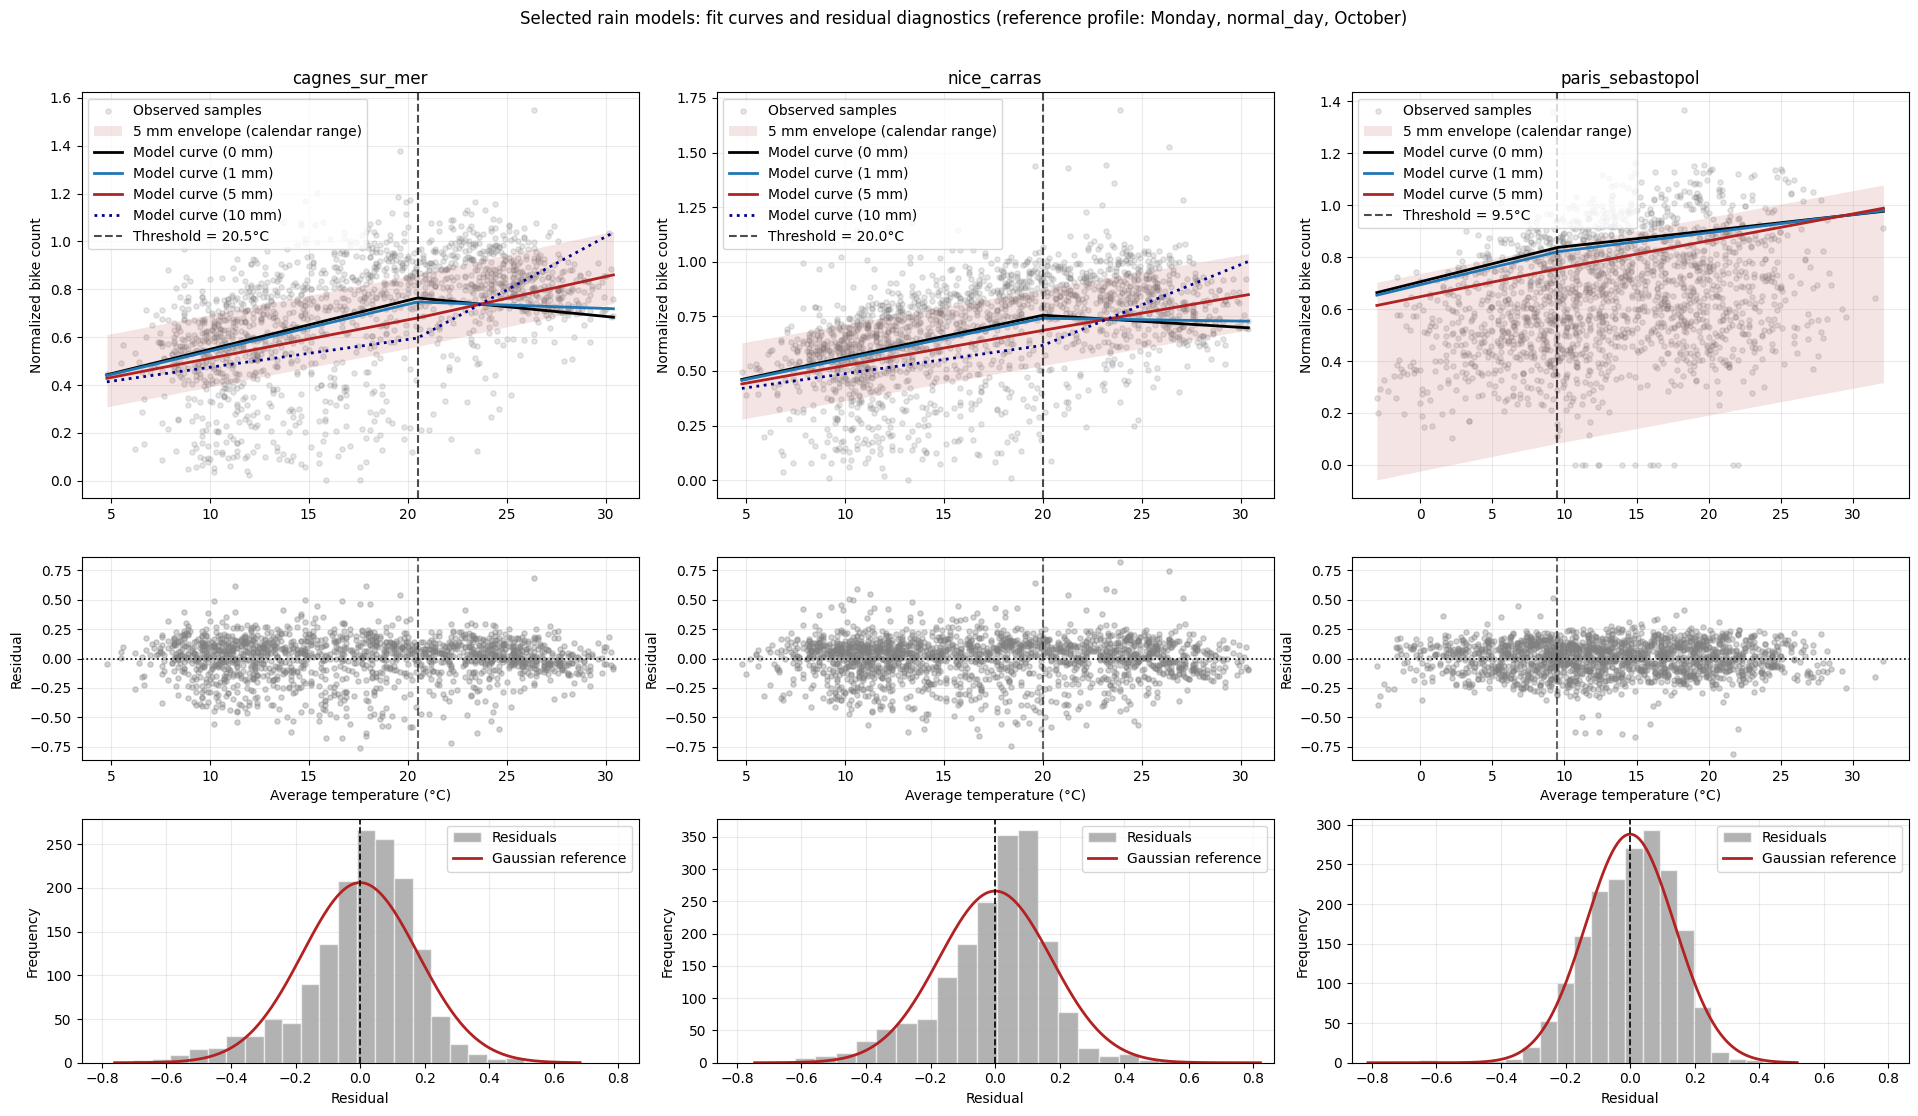

In [54]:
# Plot diagnostics from precomputed M4_predictions and M4_plot_curves
counter_list = sorted(M4_predictions["counter"].unique())

residual_abs_max = float(np.nanmax(np.abs(M4_predictions["residual"].to_numpy())))
resid_lim = 1.05 * residual_abs_max

fig, axes = plt.subplots(
    3,
    len(counter_list),
    figsize=(6.4 * len(counter_list), 11),
    squeeze=False,
    gridspec_kw={"height_ratios": [3.0, 1.5, 1.8]}
)

for idx, counter_name in enumerate(counter_list):
    ax_model = axes[0, idx]
    ax_resid = axes[1, idx]
    ax_hist = axes[2, idx]

    subset = M4_predictions.loc[M4_predictions["counter"] == counter_name].copy()
    curve_store = M4_plot_curves[counter_name]

    x_grid = curve_store["x_grid"]
    best_c = curve_store["best_c"]

    ax_model.scatter(
        subset["tavg"],
        subset["normalized_count"],
        s=14,
        alpha=0.2,
        color="gray",
        label="Observed samples",
    )

    ax_model.fill_between(
        x_grid,
        curve_store["y_low_5mm"],
        curve_store["y_high_5mm"],
        color="firebrick",
        alpha=0.12,
        linewidth=0,
        label="5 mm envelope (calendar range)",
    )

    for prcp_mm, color, linestyle in curve_store["curve_specs"]:
        ax_model.plot(
            x_grid,
            curve_store["y_curves"][prcp_mm],
            color=color,
            linestyle=linestyle,
            linewidth=2,
            label=f"Model curve ({prcp_mm:.0f} mm)",
        )

    ax_model.axvline(
        best_c,
        color="black",
        linestyle="--",
        alpha=0.7,
        label=f"Threshold = {best_c:.1f}°C",
    )
    ax_model.set_title(counter_name)
    ax_model.set_ylabel("Normalized bike count")
    ax_model.grid(alpha=0.25)
    ax_model.legend()

    ax_resid.scatter(
        subset["tavg"],
        subset["residual"],
        s=14,
        alpha=0.35,
        color="gray",
    )
    ax_resid.axhline(0, color="black", linestyle=":", linewidth=1.2)
    ax_resid.axvline(best_c, color="black", linestyle="--", alpha=0.6)
    ax_resid.set_ylim(-resid_lim, resid_lim)
    ax_resid.set_xlabel("Average temperature (°C)")
    ax_resid.set_ylabel("Residual")
    ax_resid.grid(alpha=0.25)

    residuals = subset["residual"].to_numpy()
    hist_counts, bin_edges, _ = ax_hist.hist(
        residuals,
        bins=25,
        color="gray",
        alpha=0.6,
        edgecolor="white",
        label="Residuals",
    )

    mu = float(np.mean(residuals))
    sigma = float(np.std(residuals, ddof=1))
    if sigma > 0 and len(bin_edges) > 1:
        x_norm = np.linspace(bin_edges[0], bin_edges[-1], 300)
        bin_width = float(bin_edges[1] - bin_edges[0])
        y_norm = scipy.stats.norm.pdf(x_norm, loc=mu, scale=sigma) * len(residuals) * bin_width
        ax_hist.plot(x_norm, y_norm, color="firebrick", linewidth=2, label="Gaussian reference")

    ax_hist.axvline(0, color="black", linestyle="--", linewidth=1.2)
    ax_hist.set_xlim(-resid_lim, resid_lim)
    ax_hist.set_xlabel("Residual")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.25)
    ax_hist.legend()

profile_label = f"reference profile: {day_ref}, {ws_ref}, {month_ref}"
plt.suptitle(f"Selected rain models: fit curves and residual diagnostics ({profile_label})", y=1.01)
plt.tight_layout()
plt.show()

#### First conclusions after including the effect of rain

The model in Paris does not let appear any unexpected issue : 
- A few outliers can be spotted from the residuals, and could be easily removed before refitting the model as data has not been properly cleaned yet.
- The residual distribution is a bit skewed, which may result from the temporal trend in the data which mix counts from different years while the evolution of cycling has been significant over the considered period.

Conversely, the models for Nice and Cagnes-sur-Mer are much less convincing : 
* The **effect of rain seems counter-intuitive for high rain intensity and high temperatures.**
* The effect of rain on the count and thermosensitivity does not seem to match the qualitative impression that could be derived by looking at the graphs [which first explored the effect of weather](#investigating-the-effect-of-weather). It seems underestimated in both cases.
* But most of all, these impressions may come from a **large number of samples which count values are unexepectedly low**, visible on all the plots above and resulting in a **large left tail of the residual distributions.**

**Investigating the reason of this heavy tail seems a necessity before adapting the model or interpreting it further**, as it can be a serious hint for a missing exogeneous parameter.

After comparing the value of statistics of different exogeneous parameters on the days with suspicioulsy low residuals to the global sample value, **an additional parameter of influence which was not accounted for** is supected to have a meaningful effect in Nice and Cagnes-sur-Mer : the **daily number of minutes of  sunshine**.

This is illustrated on the plot below, representing the bike counts vs sunshine duration and windpseed (another available exogeneous variable).

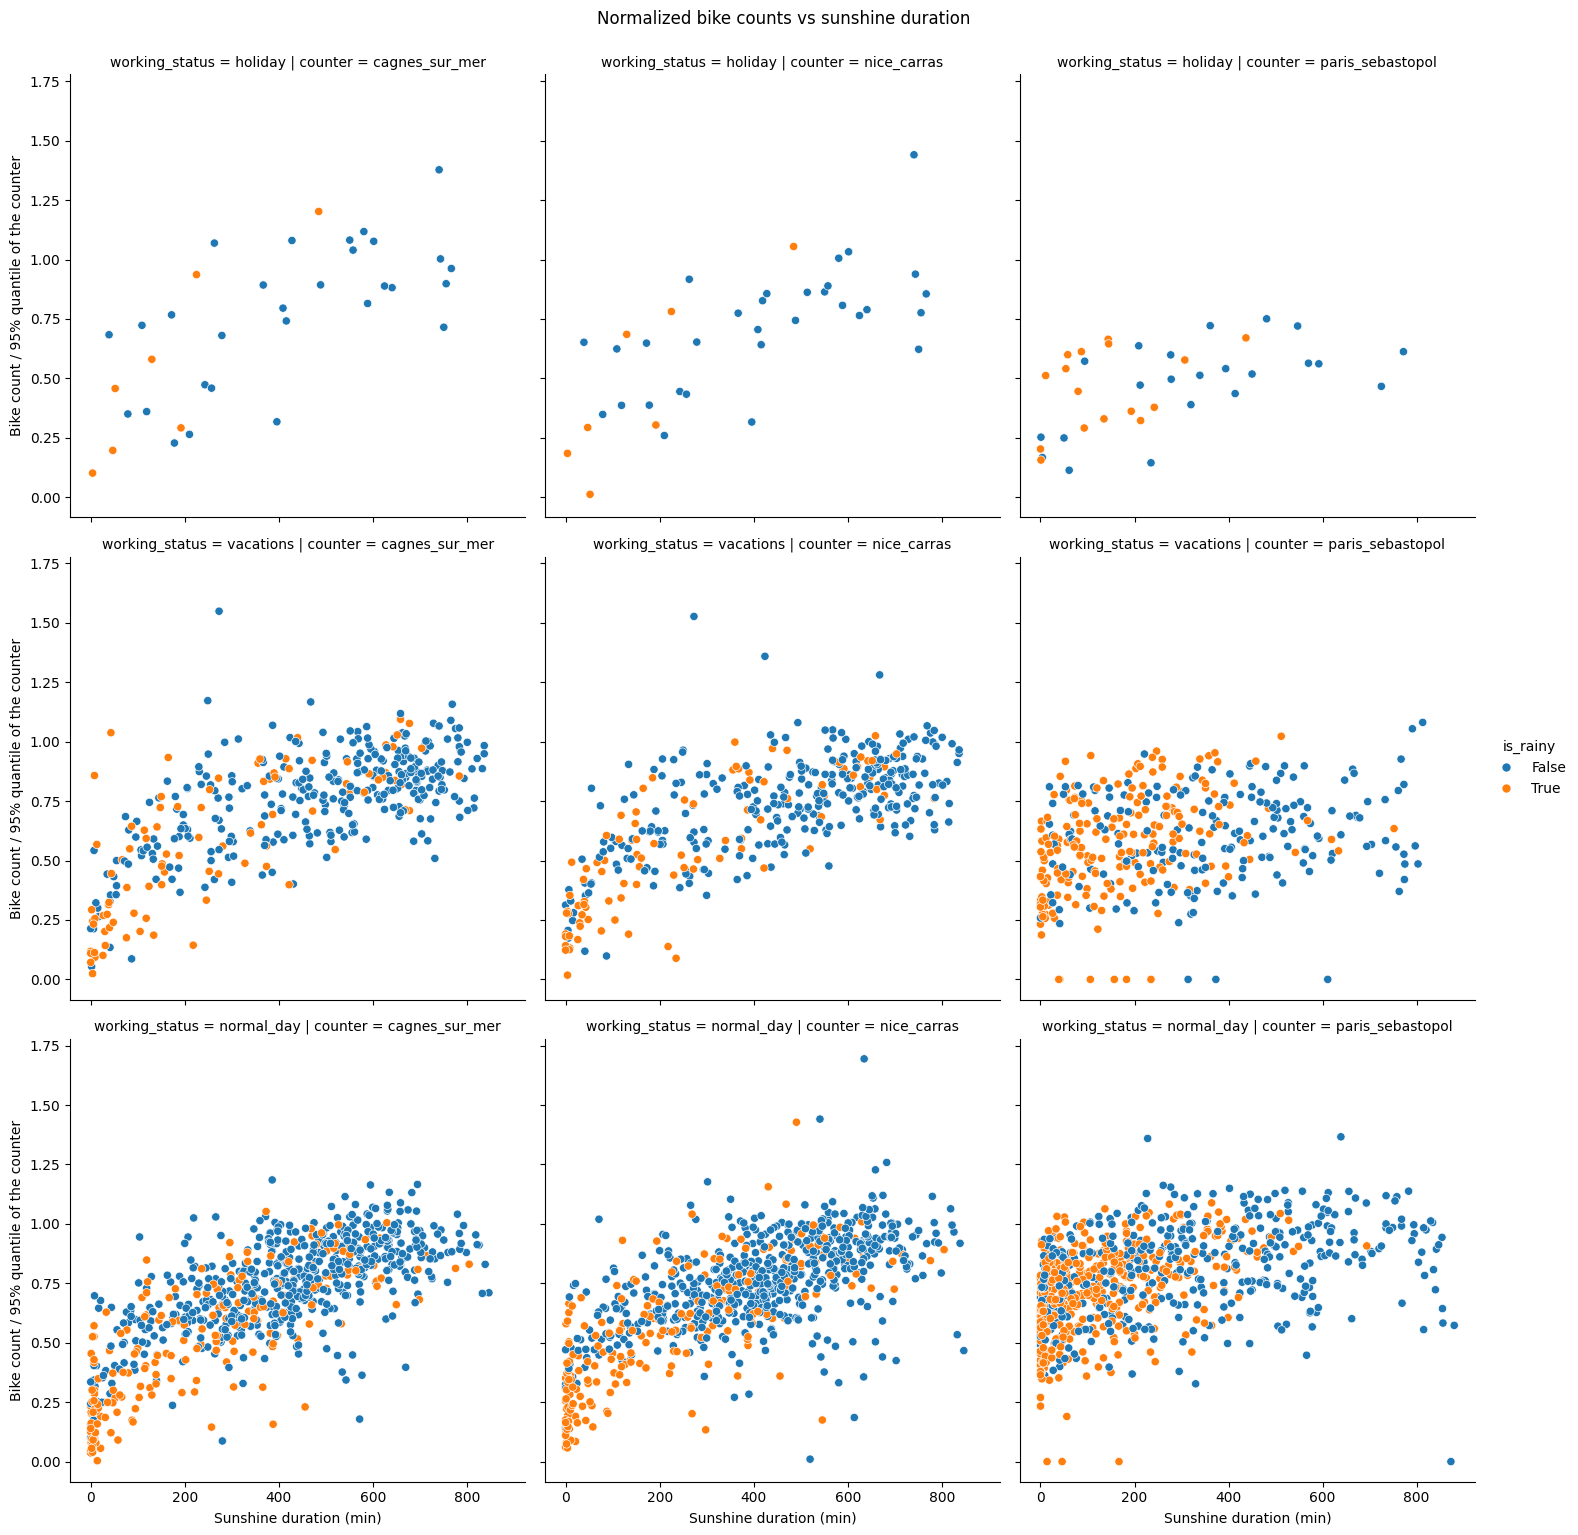

In [55]:
lm_graph = sns.relplot(
    data=plot_data,
    x="tsun",
    y="normalized_count",
    hue="is_rainy",
    row="working_status",
    col="counter",
    col_order=counter_order,
    )
lm_graph.fig.suptitle(f"Normalized bike counts vs sunshine duration", y=1.02)
lm_graph.set_xlabels("Sunshine duration (min)")
lm_graph.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

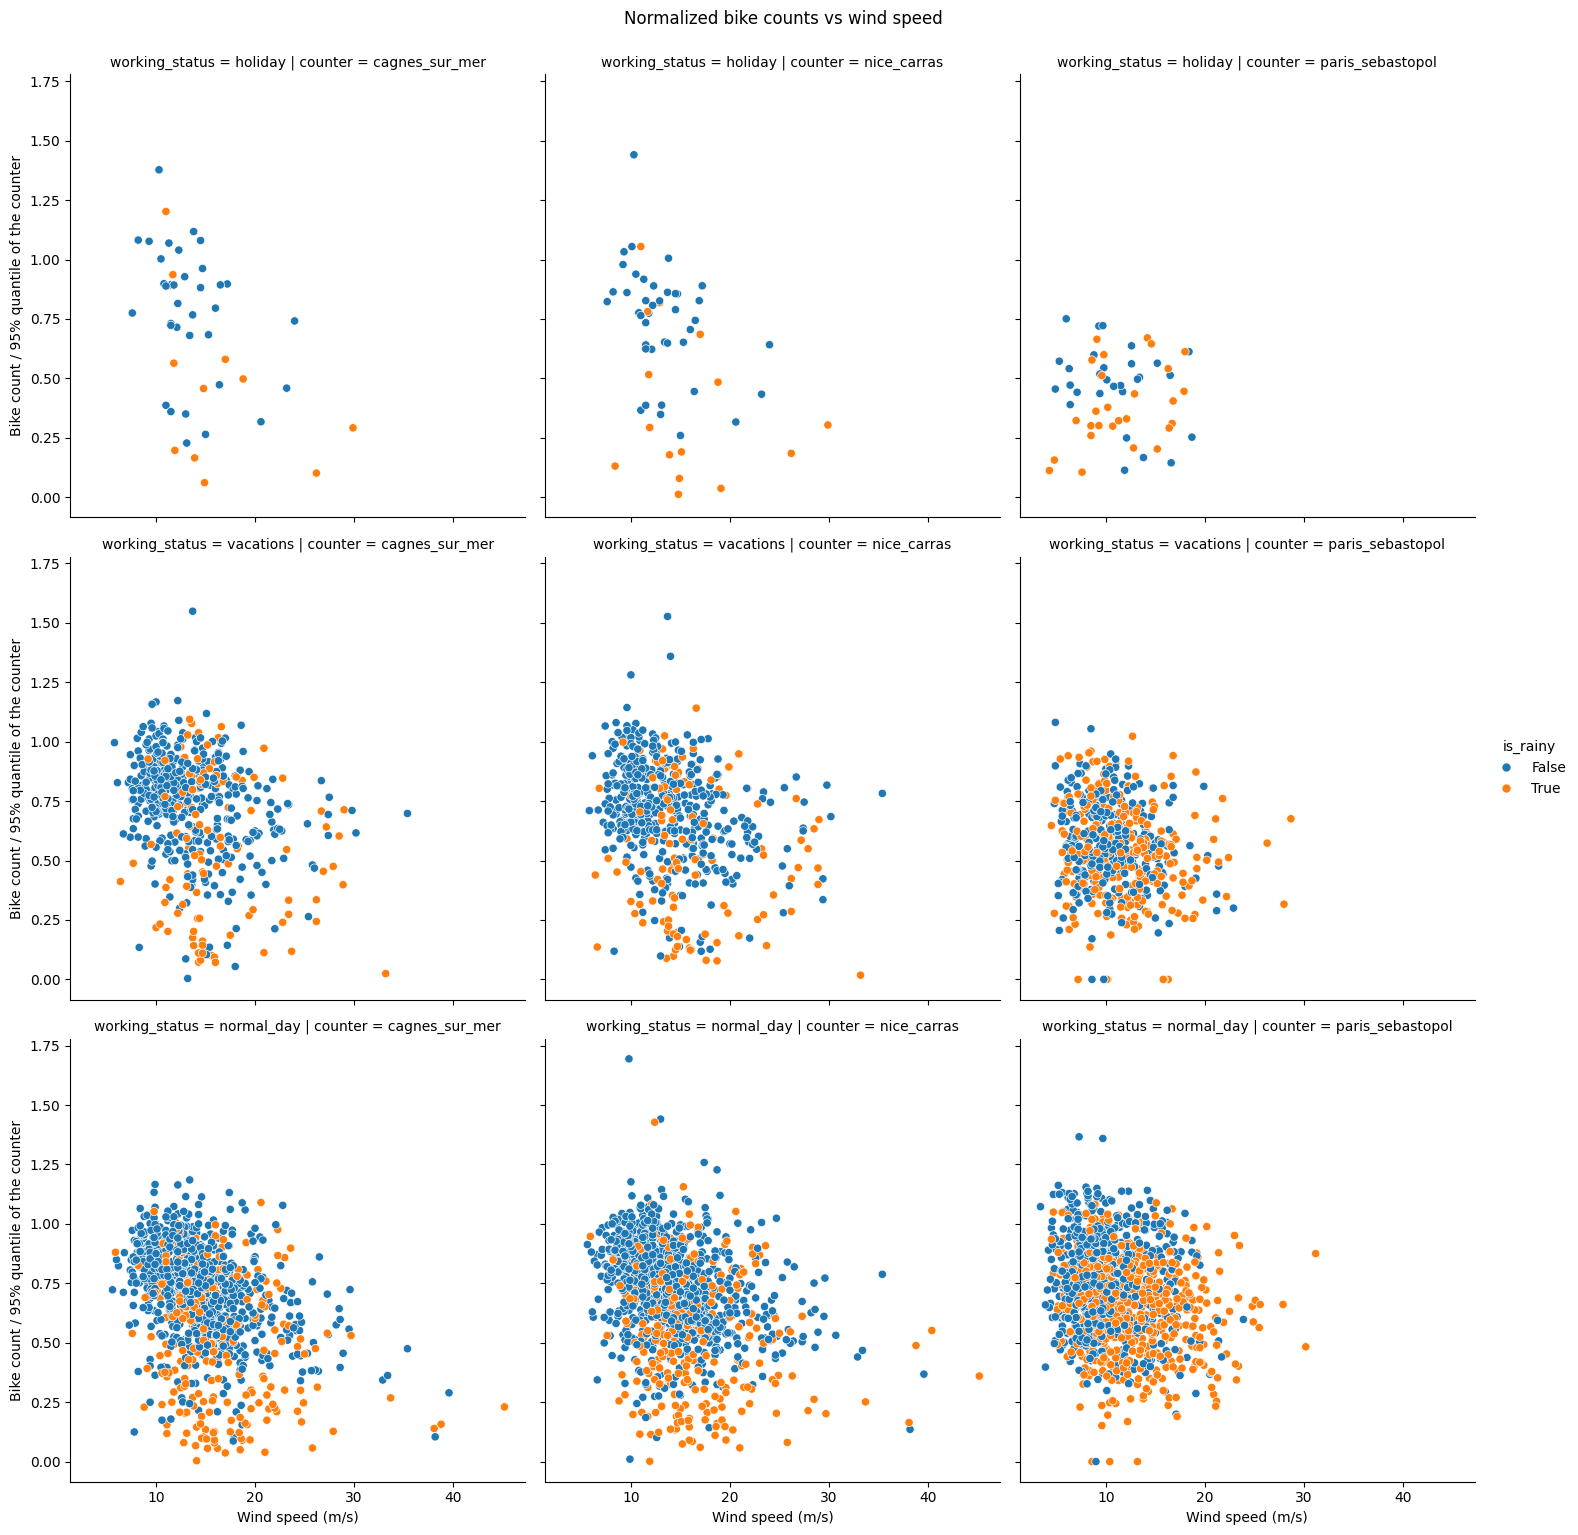

In [56]:
lm_graph = sns.relplot(
    data=plot_data,
    x="wspd",
    y="normalized_count",
    hue="is_rainy",
    row="working_status",
    col="counter",
    col_order=counter_order,
    )
lm_graph.fig.suptitle(f"Normalized bike counts vs wind speed", y=1.02)
lm_graph.set_xlabels("Wind speed (m/s)")
lm_graph.set_ylabels("Bike count / 95% quantile of the counter")
plt.show()

While the sunshine duration parameter is also correlated with temperature, rain and calendar, it seems possible that it has a measurable effect on the detected bike count.

The next section is focused on this topic.

# Sunshine and windspeed effect

The diagnostics above suggest that part of the unexplained variability may come from weather conditions that are not yet explicit in the current formulation.

In this section, the selected `M4` formulation is extended by adding sunshine duration (`tsun`) and wind speed (`wspd`) as additional exogeneous factors.
Both are included as a "speed-up of this exploration", and could possibly be pruned afterward, depending on the significance and value of their model coefficients.

The workflow follows the same structure as in the rain section:
1. build and characterize the analysis dataset,
2. fit the adapted model (`M5`),
3. inspect fit and residual diagnostics with the same plotting layout.

## Preparing the sunshine-windspeed analysis dataset

The starting point is the rain-analysis base (`rain_step2_data`), which already contains the fixed threshold hinge term and the rain terms.

Sunshine and windspeed constraints are now added by keeping only rows with complete values for all variables needed by `M5`.

In [57]:
# Step S1 - Build complete-case base for M5 and summarize missingness/sample retention
m5_required_cols = [
    "normalized_count", "tavg", "tavg_hinge", "prcp", "tsun", "wspd",
    "working_status", "day_name", "month",
]
m5_step1_data = rain_step2_data.copy()
lookup = (
    plot_data
    .sort_values(["counter", "date"])
    .drop_duplicates(subset=["counter", "date"], keep="last")
    .set_index(["counter", "date"])
)

row_idx = pd.MultiIndex.from_frame(m5_step1_data[["counter", "date"]])
m5_step1_data["tsun"] = lookup["tsun"].reindex(row_idx).to_numpy()
m5_step1_data["wspd"] = lookup["wspd"].reindex(row_idx).to_numpy()

m5_step1_complete = m5_step1_data.dropna(subset=m5_required_cols).copy()

rows = []
for counter_name, grp in m5_step1_data.groupby("counter", sort=True):
    grp_complete = grp.dropna(subset=m5_required_cols)
    n_total = len(grp)
    n_complete = len(grp_complete)

    rows.append({
        "counter": counter_name,
        "n_total": n_total,
        "n_complete": n_complete,
        "complete_rate_pct": 100 * n_complete / n_total if n_total else np.nan,
        "missing_count_pct": 100 * grp["normalized_count"].isna().mean(),
        "missing_tavg_pct": 100 * grp["tavg"].isna().mean(),
        "missing_prcp_pct": 100 * grp["prcp"].isna().mean(),
        "missing_tsun_pct": 100 * grp["tsun"].isna().mean() if "tsun" in grp else np.nan,
        "missing_wspd_pct": 100 * grp["wspd"].isna().mean() if "wspd" in grp else np.nan,
        "missing_working_status_pct": 100 * grp["working_status"].isna().mean(),
        "missing_day_name_pct": 100 * grp["day_name"].isna().mean(),
        "missing_month_pct": 100 * grp["month"].isna().mean(),
    })

m5_step1_qc_counts = pd.DataFrame(rows).sort_values("counter").reset_index(drop=True)

print("Step S1 - QC summary for sunshine/windspeed extension")
print(f"Rows in input base: {len(m5_step1_data):,}")
print(f"Rows retained for M5 complete-case base: {len(m5_step1_complete):,}")

m5_step1_qc_counts.round(2)

Step S1 - QC summary for sunshine/windspeed extension
Rows in input base: 5,323
Rows retained for M5 complete-case base: 3,742


,counter,n_total,n_complete,complete_rate_pct,missing_count_pct,missing_tavg_pct,missing_prcp_pct,missing_tsun_pct,missing_wspd_pct,missing_working_status_pct,missing_day_name_pct,missing_month_pct
0,cagnes_sur_mer,1603,1212,75.61,0.0,0.0,0.0,24.39,0.0,0.0,0.0,0.0
1,nice_carras,1854,1261,68.02,0.0,0.0,0.0,31.98,0.0,0.0,0.0,0.0
2,paris_sebastopol,1866,1269,68.01,0.0,0.0,0.0,31.99,0.0,0.0,0.0,0.0


Adding sunshine strongly reduces the usable sample compared with the rain base: only 3,742 out of 5,418 rows are retained (about 69.1%).

Retention remains fairly homogeneous across counters (`71.6%` in Cagnes-sur-Mer, `67.9%` in Nice Carras, `68.0%` in Paris Sebastopol), so between-counter comparison remains acceptable.

The dominant source of loss is missing `tsun` (`25.6%` to `32.1%` depending on counter), while `wspd`, `tavg`, `prcp`, and calendar controls are essentially complete.


Given the high proportion of missing data due to the addition of these new variables, it seems important to investigate _where_ this data is lost : are missing data uniformly distributed in time, at a certain period, correlated with previously extreme residuals ?

The cells below provide first insight to answer these questions.

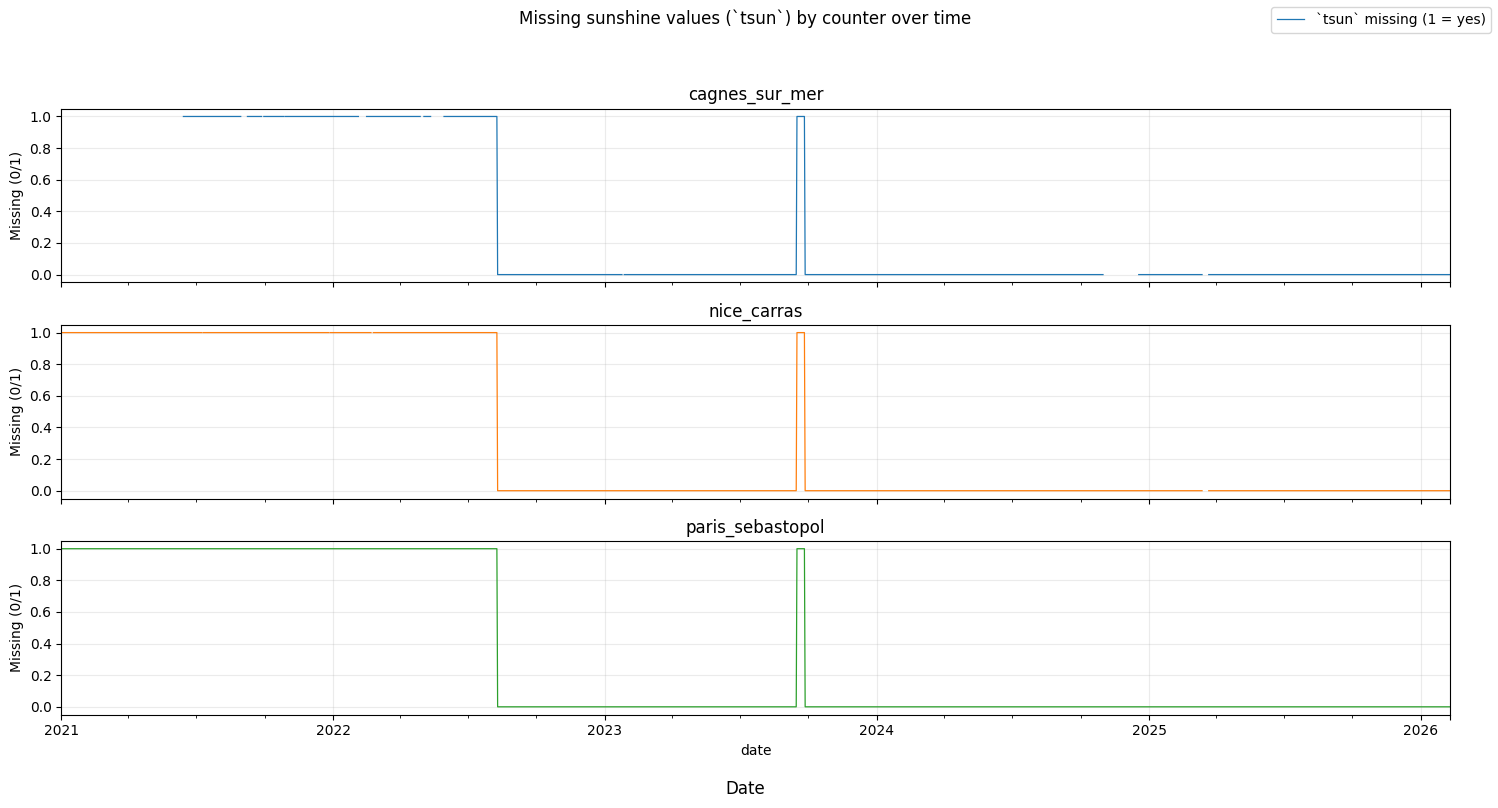

In [58]:
missing_tsun = (
    m5_step1_data.loc[:, ["date", "counter", "tsun"]]
    .assign(tsun_missing=lambda d: d["tsun"].isna().astype(int))
    .pivot_table(index="date", columns="counter", values="tsun_missing", aggfunc="max")
    .sort_index()
)

axes = missing_tsun.plot(
    subplots=True,
    sharex=True,
    figsize=(15, 8),
    linewidth=0.9,
    legend=False,
)

axes = axes.ravel() if isinstance(axes, np.ndarray) else [axes]

for ax, counter in zip(axes, missing_tsun.columns):
    ax.set_title(counter)
    ax.set_ylabel("Missing (0/1)")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.25)

fig = axes[0].figure
fig.suptitle("Missing sunshine values (`tsun`) by counter over time", y=0.995)
fig.supxlabel("Date")
fig.legend([axes[0].lines[0]], ["`tsun` missing (1 = yes)"], loc="upper right")
fig.tight_layout(rect=[0, 0, 0.98, 0.96])

It looks like the missing tsun values are the same for all counters, mainly because they were not reported before mid of 2022. 
As this is the oldest and least up to date data, that's considered OK. 

In [59]:
# First index tsun is not misssing
tsun_begin = (missing_tsun == 0).idxmax()
tsun_begin


counter
cagnes_sur_mer     2022-08-10
nice_carras        2022-08-10
paris_sebastopol   2022-08-10
dtype: datetime64[ns]

It looks like another month or data or alike is missing in 2023.
Let see when it was before moving on.

In [60]:
m5_start = tsun_begin.iloc[0]

In [61]:
m5_step1_data = m5_step1_data.loc[m5_step1_data["date"] >= m5_start].copy()
# Show only rows with missing tsun value
m5_step1_data.loc[m5_step1_data["tsun"].isna(), ["date", "counter", "tsun"]]

,date,counter,tsun
2800,2023-09-16,cagnes_sur_mer,NaN
2801,2023-09-16,paris_sebastopol,NaN
2802,2023-09-16,nice_carras,NaN
2803,2023-09-17,cagnes_sur_mer,NaN
2804,2023-09-17,paris_sebastopol,NaN
2805,2023-09-17,nice_carras,NaN
2806,2023-09-18,nice_carras,NaN
2807,2023-09-18,cagnes_sur_mer,NaN
2808,2023-09-18,paris_sebastopol,NaN
2809,2023-09-19,cagnes_sur_mer,NaN


Another week of tsun data is missing in 2023. 
Let keep this in mind and move on. 

In order to correctly compare the new approach including `tsun` and `wspd` as exogeneous variables, M4 should be refitted on the same dataset as M5 to correctly appreciate the gains or not of using M5.

Below the dataset used in this section :

In [62]:
m5_step1_complete

,counter,normalized_count,tavg,prcp,working_status,day_name,date,month,threshold_c,tavg_hinge,tsun,wspd
1594,nice_carras,0.716145,27.7,0.0,vacations,Wednesday,2022-08-10,August,20.0,7.7,499.0,14.7
1595,paris_sebastopol,0.526778,26.1,0.0,vacations,Wednesday,2022-08-10,August,9.5,16.6,773.0,11.6
1596,cagnes_sur_mer,0.735210,27.7,0.0,vacations,Wednesday,2022-08-10,August,20.5,7.2,499.0,14.7
1597,nice_carras,0.687776,26.7,0.0,vacations,Thursday,2022-08-11,August,20.0,6.7,539.0,14.9
1598,paris_sebastopol,0.485390,26.9,0.0,vacations,Thursday,2022-08-11,August,9.5,17.4,775.0,10.7
...,...,...,...,...,...,...,...,...,...,...,...,...
5429,nice_carras,0.274306,9.6,15.6,normal_day,Sunday,2026-02-08,February,20.0,0.0,31.0,18.5
5430,cagnes_sur_mer,0.185759,9.6,15.6,normal_day,Sunday,2026-02-08,February,20.5,0.0,31.0,18.5
5431,nice_carras,0.689339,10.6,11.0,normal_day,Monday,2026-02-09,February,20.0,0.0,33.0,14.4
5432,paris_sebastopol,0.734854,6.9,0.0,normal_day,Monday,2026-02-09,February,9.5,0.0,156.0,7.9


## Simple view of the added data distributions

To characterize the new exogeneous variables, the next table summarizes sunshine and windspeed distributions per counter on the same complete-case base.

This helps assess scale differences and potential heterogeneity before fitting `M5`.

In [63]:
m5_step1_complete.groupby("counter", sort=True)[['tsun', 'wspd']].describe().round(2)

tsun                                                     \
                   count    mean     std  min     25%    50%     75%    max   
counter                                                                       
cagnes_sur_mer    1212.0  395.29  224.88  0.0  218.75  409.0  573.25  847.0   
nice_carras       1261.0  390.52  223.49  0.0  215.00  402.0  570.00  847.0   
paris_sebastopol  1269.0  242.00  213.38  0.0   59.00  192.0  372.00  880.0   

                    wspd                                            
                   count   mean   std  min   25%   50%   75%   max  
counter                                                             
cagnes_sur_mer    1212.0  14.68  4.76  5.9  11.2  14.0  17.0  45.2  
nice_carras       1261.0  14.76  4.77  5.9  11.4  14.1  17.0  45.2  
paris_sebastopol  1269.0  11.38  4.15  3.4   8.3  10.6  13.8  31.2

Once again, no surprise : French Rivera is sunnier and more windy than Paris.

These differences support counter-specific calibration of the same functional form, rather than imposing shared weather scales across locations.

## Fitting the adapted model M5

`M5` extends `M4` by adding additive exogeneous effects for sunshine (`tsun`) and windspeed (`wspd`) while preserving the rain-temperature interaction structure.

The table below compares `M4` and `M5` for each counter on the exact same complete-case sample.
As explained above, `M4` is refitted on the updated dataset in order to show a fair comparison on the models.

In [64]:
# Step S2 - Fit M5 per counter and compare against M4 on same sample
m5_formula = (
    "normalized_count ~ tavg + tavg_hinge "
    "+ prcp + prcp:tavg + prcp:tavg_hinge "
    "+ tsun + wspd + C(working_status) + C(day_name) + C(month)"
)
m4_formula = ("normalized_count ~ tavg + tavg_hinge "
              "+ prcp + prcp:tavg + prcp:tavg_hinge "
              "+ C(working_status) + C(day_name) + C(month)")

M5_results = {}
comparison_rows = []
counter_list = sorted(m5_step1_complete["counter"].unique())

for counter_name in counter_list:
    model_df = m5_step1_complete.loc[m5_step1_complete["counter"] == counter_name].copy()

    M4_on_m5_sample = smf.ols(
        formula=m4_formula,
        data=model_df,
    ).fit(cov_type='HC3')

    M5_fitted = smf.ols(
        formula=m5_formula,
        data=model_df
    ).fit(cov_type='HC3')

    M5_results[counter_name] = {
        "M4": M4_on_m5_sample,
        "M5": M5_fitted,
        "nobs": int(M5_fitted.nobs),
    }

    comparison_rows.append({
        "counter": counter_name,
        "nobs": int(M5_fitted.nobs),
        "M4_aic": float(M4_on_m5_sample.aic),
        "M5_aic": float(M5_fitted.aic),
        "delta_aic_M5_minus_M4": float(M5_fitted.aic - M4_on_m5_sample.aic),
        "M4_r2": float(M4_on_m5_sample.rsquared),
        "M5_r2": float(M5_fitted.rsquared),
        "M4_r2_adj": float(M4_on_m5_sample.rsquared_adj),
        "M5_r2_adj": float(M5_fitted.rsquared_adj),
        "M4_bic": float(M4_on_m5_sample.bic),
        "M5_bic": float(M5_fitted.bic),
        "delta_bic_M5_minus_M4": float(M5_fitted.bic - M4_on_m5_sample.bic),
    })

M5_model_comparison = pd.DataFrame(comparison_rows).sort_values("counter").reset_index(drop=True)

print("M5 extension compared to M4 on a common sample (negative delta-AIC/BIC favors M5)")
M5_model_comparison.round(4)

M5 extension compared to M4 on a common sample (negative delta-AIC/BIC favors M5)


,counter,nobs,M4_aic,M5_aic,delta_aic_M5_minus_M4,M4_r2,M5_r2,M4_r2_adj,M5_r2_adj,M4_bic,M5_bic,delta_bic_M5_minus_M4
0,cagnes_sur_mer,1212,-674.4366,-1309.4715,-635.0349,0.4517,0.6764,0.4407,0.6693,-546.9359,-1171.7708,-624.8349
1,nice_carras,1261,-860.1204,-1287.5485,-427.4281,0.4597,0.6163,0.4492,0.6082,-731.6289,-1148.7776,-417.1488
2,paris_sebastopol,1269,-1678.5074,-1768.3426,-89.8352,0.6759,0.6990,0.6696,0.6927,-1549.8578,-1629.4010,-79.5432


**The `M5` extension improves fit quality for all counters on the same sample.**
Especially, the improvement is very significant on the metrics for the models on the French Riviera!
This corroborates the idea that these parameters were of importance to model the bike counts at these locations.

_Note : as done previously, both parameters could have been introduced one by one but the choice of including them both was made to move a bit faster.
Significance could be used to decide if one of these variables could/should be removed._

### Plotting M5 in the same diagnostic format

To stay comparable with the previous section, the same three-layer diagnostic figure is produced for each counter:
- observed scatter + model curves,
- residuals vs temperature,
- residual histogram with Gaussian reference.

Model curves are drawn with the same calendar profile (`working_status`, `day_name`, `month`) and with three explicit weather scenarios:
- `0 mm` rain + sunshine `q90`,
- `0 mm` rain + sunshine `q20`,
- `5 mm` rain + sunshine `q20`.

In [65]:
# Step S3 - Precompute predictions and plotting objects for M5 diagnostics
required_cols_plot_m5 = [
    "normalized_count", "tavg", "tavg_hinge", "prcp", "tsun", "wspd",
    "working_status", "day_name", "month",
]

# Reuse reference profile if already defined; otherwise define defaults
if "ws_ref" not in locals():
    ws_ref = "normal_day"
if "day_ref" not in locals():
    day_ref = "Monday"
if "month_ref" not in locals():
    month_ref = "October"

M5_predictions_parts = []
M5_plot_curves = {}
m5_reference_profile_rows = []

for counter_name in counter_list:
    fitted = M5_results[counter_name]["M5"]

    subset = (
        m5_step1_complete
        .loc[m5_step1_complete["counter"] == counter_name]
        .dropna(subset=required_cols_plot_m5)
        .copy()
    )

    pred_frame = fitted.get_prediction(subset).summary_frame(alpha=0.05)
    subset["selected_model"] = "M5"
    subset["fitted"] = pred_frame["mean"].to_numpy()
    subset["residual"] = subset["normalized_count"] - subset["fitted"]

    if "mean_se" in pred_frame.columns:
        subset["fitted_mean_se"] = pred_frame["mean_se"].to_numpy()
    if "mean_ci_lower" in pred_frame.columns:
        subset["fitted_mean_ci_lower"] = pred_frame["mean_ci_lower"].to_numpy()
    if "mean_ci_upper" in pred_frame.columns:
        subset["fitted_mean_ci_upper"] = pred_frame["mean_ci_upper"].to_numpy()

    M5_predictions_parts.append(subset)

M5_predictions = (
    pd.concat(M5_predictions_parts, axis=0)
    .sort_values(["counter", "tavg"])
    .reset_index(drop=True)
)

threshold_map = rain_selected_thresholds.set_index("counter")["best_threshold_C"].to_dict()

for counter_name in counter_list:
    fitted = M5_results[counter_name]["M5"]
    subset = M5_predictions.loc[M5_predictions["counter"] == counter_name].copy()

    best_c = float(threshold_map[counter_name])
    x_min = float(subset["tavg"].min())
    x_max = float(subset["tavg"].max())
    x_grid = np.linspace(x_min, x_max, 250)

    profile_subset = subset.loc[
        (subset["working_status"] == ws_ref)
        & (subset["day_name"] == day_ref)
        & (subset["month"] == month_ref)
    ]

    if len(profile_subset) == 0:
        profile_subset = subset

    tsun_q20 = float(profile_subset["tsun"].quantile(0.20))
    tsun_q90 = float(profile_subset["tsun"].quantile(0.90))
    wspd_ref = float(profile_subset["wspd"].median())

    m5_reference_profile_rows.append({
        "counter": counter_name,
        "ws_ref": ws_ref,
        "day_ref": day_ref,
        "month_ref": month_ref,
        "tsun_q20_min": tsun_q20,
        "tsun_q90_min": tsun_q90,
        "wspd_ref_ms": wspd_ref,
    })

    curve_specs = [
        {
            "prcp": 0.0,
            "tsun": tsun_q90,
            "color": "black",
            "linestyle": "-",
            "label": f"Model curve (0 mm, sunshine q90={tsun_q90:.0f})",
        },
        {
            "prcp": 0.0,
            "tsun": tsun_q20,
            "color": "tab:blue",
            "linestyle": "--",
            "label": f"Model curve (0 mm, sunshine q20={tsun_q20:.0f})",
        },
        {
            "prcp": 5.0,
            "tsun": tsun_q20,
            "color": "firebrick",
            "linestyle": "-.",
            "label": f"Model curve (5 mm, sunshine q20={tsun_q20:.0f})",
        },
    ]

    for spec in curve_specs:
        pred_df = pd.DataFrame({
            "tavg": x_grid,
            "tavg_hinge": np.maximum(0.0, x_grid - best_c),
            "prcp": float(spec["prcp"]),
            "tsun": float(spec["tsun"]),
            "wspd": wspd_ref,
            "working_status": ws_ref,
            "day_name": day_ref,
            "month": month_ref,
        })
        spec["y_curve"] = np.asarray(fitted.predict(pred_df), dtype=float)

    M5_plot_curves[counter_name] = {
        "x_grid": x_grid,
        "best_c": best_c,
        "curve_specs": curve_specs,
        "wspd_ref": wspd_ref,
    }

M5_reference_profile = pd.DataFrame(m5_reference_profile_rows).sort_values("counter").reset_index(drop=True)
print("Counter-specific reference values used for M5 curve plotting")
M5_reference_profile.round(2)

Counter-specific reference values used for M5 curve plotting


,counter,ws_ref,day_ref,month_ref,tsun_q20_min,tsun_q90_min,wspd_ref_ms
0,cagnes_sur_mer,normal_day,Monday,October,72.2,586.7,12.25
1,nice_carras,normal_day,Monday,October,72.2,586.7,12.25
2,paris_sebastopol,normal_day,Monday,October,123.8,365.0,8.85


For the reference profile (`Monday`, `normal_day`, `October`), curve anchors now use:
- sunshine `q90` for `0 mm` rain,
- sunshine `q20` for `0 mm` rain,
- sunshine `q20` for `5 mm` rain,

with windspeed fixed at the counter-specific median over the same reference profile.

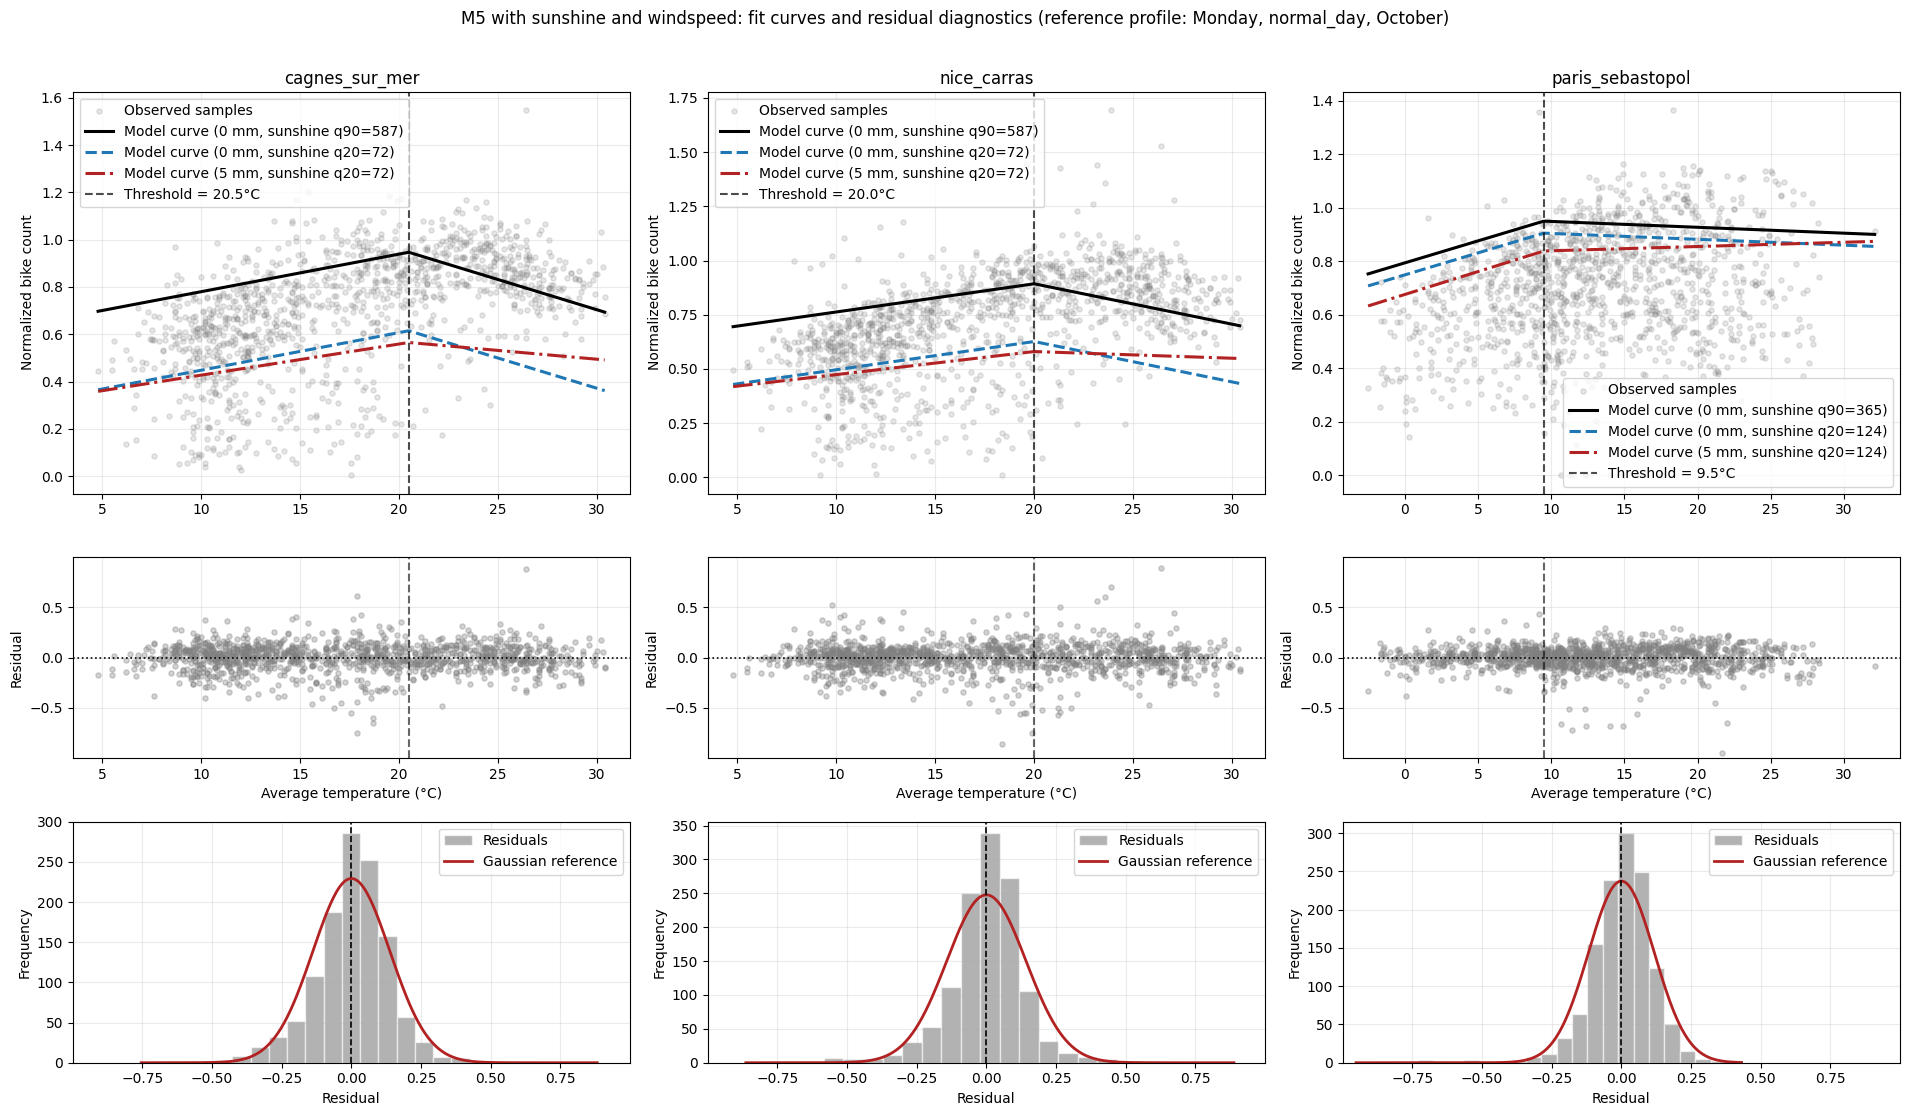

In [66]:
# Step S3 - Plot diagnostics for M5 (same layout as M4)
counter_list = sorted(M5_predictions["counter"].unique())

residual_abs_max = float(np.nanmax(np.abs(M5_predictions["residual"].to_numpy())))
resid_lim = 1.05 * residual_abs_max

fig, axes = plt.subplots(
    3,
    len(counter_list),
    figsize=(6.4 * len(counter_list), 11),
    squeeze=False,
    gridspec_kw={"height_ratios": [3.0, 1.5, 1.8]}
)

for idx, counter_name in enumerate(counter_list):
    ax_model = axes[0, idx]
    ax_resid = axes[1, idx]
    ax_hist = axes[2, idx]

    subset = M5_predictions.loc[M5_predictions["counter"] == counter_name].copy()
    curve_store = M5_plot_curves[counter_name]

    x_grid = curve_store["x_grid"]
    best_c = curve_store["best_c"]

    ax_model.scatter(
        subset["tavg"],
        subset["normalized_count"],
        s=14,
        alpha=0.2,
        color="gray",
        label="Observed samples",
    )

    for spec in curve_store["curve_specs"]:
        ax_model.plot(
            x_grid,
            spec["y_curve"],
            color=spec["color"],
            linestyle=spec["linestyle"],
            linewidth=2.2,
            label=spec["label"],
        )

    ax_model.axvline(
        best_c,
        color="black",
        linestyle="--",
        alpha=0.7,
        label=f"Threshold = {best_c:.1f}°C",
    )
    ax_model.set_title(counter_name)
    ax_model.set_ylabel("Normalized bike count")
    ax_model.grid(alpha=0.25)
    ax_model.legend()

    ax_resid.scatter(
        subset["tavg"],
        subset["residual"],
        s=14,
        alpha=0.35,
        color="gray",
    )
    ax_resid.axhline(0, color="black", linestyle=":", linewidth=1.2)
    ax_resid.axvline(best_c, color="black", linestyle="--", alpha=0.6)
    ax_resid.set_ylim(-resid_lim, resid_lim)
    ax_resid.set_xlabel("Average temperature (°C)")
    ax_resid.set_ylabel("Residual")
    ax_resid.grid(alpha=0.25)

    residuals = subset["residual"].to_numpy()
    hist_counts, bin_edges, _ = ax_hist.hist(
        residuals,
        bins=25,
        color="gray",
        alpha=0.6,
        edgecolor="white",
        label="Residuals",
    )

    mu = float(np.mean(residuals))
    sigma = float(np.std(residuals, ddof=1))
    if sigma > 0 and len(bin_edges) > 1:
        x_norm = np.linspace(bin_edges[0], bin_edges[-1], 300)
        bin_width = float(bin_edges[1] - bin_edges[0])
        y_norm = scipy.stats.norm.pdf(x_norm, loc=mu, scale=sigma) * len(residuals) * bin_width
        ax_hist.plot(x_norm, y_norm, color="firebrick", linewidth=2, label="Gaussian reference")

    ax_hist.axvline(0, color="black", linestyle="--", linewidth=1.2)
    ax_hist.set_xlim(-resid_lim, resid_lim)
    ax_hist.set_xlabel("Residual")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.25)
    ax_hist.legend()

profile_label = f"reference profile: {day_ref}, {ws_ref}, {month_ref}"
plt.suptitle(
    f"M5 with sunshine and windspeed: fit curves and residual diagnostics ({profile_label})",
    y=1.01,
)
plt.tight_layout()
plt.show()

The model already looks more convincing than in the previous batch, with more realistic model curves and better centered residuals.

The residual distributions still look a bit sharper than reference gaussian distributions. 
However, considering the fact that outliers detection has not been done yet, this is not a crucial caveat to consider the model as already "interpretable" and oculd be a good starting point for the use-case of period comparison.

The following section develops robustness checks before applying M5 to cross-period analysis.

# Robustness & Model Comparison

Before finalizing M5 for period comparison, we conduct three validation steps:
1. **Outlier flagging & removal** — identify and investigate data points with anomalously large residuals or documented special events
2. **Sensitivity check** — refit M5 on clean data and compare coefficients to the full-data fit
3. **Model selection** — compare M5 (segmented) against a plain-linear baseline to justify the piecewise structure
4. **Coefficient interpretation** — translate estimates back to cyclist counts and verify plausibility against exploratory findings

## Outlier flagging strategy

Obviously, as a first simple rule of thumb, all days with zero counts should be considered abnormal and considered as outliers : the most likely assumption is a counter malfunction.

Then, samples which count values are "surprising provided the external conditions" can be inspected as potential outliers.
But, this assumes that the "usual counts in these external conditions" is known a minima. 
While unsupervised techniques could be explored to try to discover them, this is not an easy task with so many exogeneous parameters which affect the bike count.

However, at this point, the obtained model is convincing enough as a "not too bad description" of the average behaviour of cyclists to start using it for this task : samples with extreme residuals values are days when the bike count is very unlikely provided that the model correctly describes the average behavior of cyclists.

Accordingly, investigating these samples seems a good starting point, with several questions in mind : 
1. On days when known exceptional events happened, do the the samples show high residual values ?
2. On day when residual values are extreme, is there a knwon event that could explain it ?

If both answers to these questions are affirmative, the trust in the model would be improved. 

This immediatly raises a new question : what can be considered an "extreme residual value" ? 

### Extreme residuals exploration

A good starting point is to classify residual magnitudes by counter-specific bands (`top_1pct` ... `top_5pct`, `below`).

This gives finer control than a single binary threshold and keeps later choices (for example top 2% for cleaning) explicit.

In [67]:
# Step 8.1.1 - Residual dispersion by counter
residual_description = M5_predictions['residual'].groupby(M5_predictions['counter']).describe().round(2)
residual_description

,count,mean,std,min,25%,50%,75%,max
counter,,,,,,,,
cagnes_sur_mer,1212.0,-0.0,0.14,-0.75,-0.06,0.01,0.08,0.88
nice_carras,1261.0,0.0,0.14,-0.86,-0.07,0.01,0.07,0.89
paris_sebastopol,1269.0,0.0,0.12,-0.95,-0.06,0.01,0.07,0.43


A categorical variable is now built from residual magnitude quantiles, separately for each counter:
- `top_1pct`, `top_2pct`, ..., `top_5pct`, `below`.

This keeps the exploration more informative than a single binary flag and allows later decisions (e.g. top 2% only) to be derived transparently.

In [68]:
# Step 8.1.2 - Build residual quantile categories per counter
M5_predictions_explore = M5_predictions.copy()
M5_predictions_explore['is_rainy'] = M5_predictions_explore['prcp'] > 0
M5_predictions_explore['residual_magnitude'] = np.abs(M5_predictions_explore['residual'])

q99 = M5_predictions_explore.groupby('counter')['residual_magnitude'].transform(lambda s: s.quantile(0.99))
q98 = M5_predictions_explore.groupby('counter')['residual_magnitude'].transform(lambda s: s.quantile(0.98))
q97 = M5_predictions_explore.groupby('counter')['residual_magnitude'].transform(lambda s: s.quantile(0.97))
q96 = M5_predictions_explore.groupby('counter')['residual_magnitude'].transform(lambda s: s.quantile(0.96))
q95 = M5_predictions_explore.groupby('counter')['residual_magnitude'].transform(lambda s: s.quantile(0.95))

M5_predictions_explore['residual_quantile_band'] = np.select(
    [
        M5_predictions_explore['residual_magnitude'] >= q99,
        M5_predictions_explore['residual_magnitude'] >= q98,
        M5_predictions_explore['residual_magnitude'] >= q97,
        M5_predictions_explore['residual_magnitude'] >= q96,
        M5_predictions_explore['residual_magnitude'] >= q95,
    ],
    ['top_1pct', 'top_2pct', 'top_3pct', 'top_4pct', 'top_5pct'],
    default='below',
)

band_order = ['top_1pct', 'top_2pct', 'top_3pct', 'top_4pct', 'top_5pct', 'below']
M5_predictions_explore['residual_quantile_band'] = pd.Categorical(
    M5_predictions_explore['residual_quantile_band'],
    categories=band_order,
    ordered=True,
)

M5_predictions_explore[['counter', 'date', 'residual_magnitude', 'residual_quantile_band']].head()

,counter,date,residual_magnitude,residual_quantile_band
0,cagnes_sur_mer,2023-02-09,0.169828,below
1,cagnes_sur_mer,2023-02-10,0.171338,below
2,cagnes_sur_mer,2026-01-07,0.110976,below
3,cagnes_sur_mer,2023-01-21,0.014938,below
4,cagnes_sur_mer,2022-12-13,0.141475,below


The interactive view below colors samples by residual quantile band.

This makes it possible to compare very extreme points (`top_1pct`) with moderately extreme ones (`top_5pct`) before defining a final outlier threshold.

In [69]:
# Step 8.1.3 - Interactive view by residual quantile category
count_plot = M5_predictions_explore.hvplot.scatter(
    y='normalized_count',
    x='tavg',
    width=1000,
    height=600,
    title='Bike counts as a function of average temperature at a counter',
    xlabel='Average temperature (°C)',
    ylabel='Normalized bike counts',
    groupby='counter',
    by='residual_quantile_band',
    hover_cols=[
        'date', 'day_name', 'wspd', 'tavg', 'tsun', 'prcp',
        'working_status', 'normalized_count', 'residual', 'residual_magnitude',
        'residual_quantile_band', 'fitted', 'fitted_mean_se',
        'fitted_mean_ci_lower', 'fitted_mean_ci_upper'
    ],
    label='Bike count',
)
(count_plot).opts(legend_position='top_left', legend_opts={'click_policy': 'mute'})

BokehModel(combine_events=True, render_bundle={'docs_json': {'448ae55d-0021-44d0-af75-f31fe7c147ee': {'version…

For the sake of interpretation, suspicious dates shared across multiple counters are extracted.

At this stage, "suspicious" means residual quantile bands from `top_1pct` to `top_5pct` (i.e. all rows except `below`).

In [70]:
# Step 8.1.4 - Outlier dates shared by Paris and Riviera counters
common_outliers = (
    M5_predictions_explore
    .query("residual_quantile_band != 'below'")
    .groupby('date')
    .filter(lambda g: len(g) >= 2)
    .sort_values('date')
)

common_outliers_paris_south = (
    common_outliers
    .groupby('date')
    .filter(lambda g: 'paris_sebastopol' in set(g['counter']))
    .sort_values(['date', 'counter'])
)
common_outliers_paris_south

,counter,normalized_count,tavg,prcp,working_status,day_name,date,month,threshold_c,tavg_hinge,...,wspd,selected_model,fitted,residual,fitted_mean_se,fitted_mean_ci_lower,fitted_mean_ci_upper,is_rainy,residual_magnitude,residual_quantile_band
1461,nice_carras,1.005864,11.1,0.0,normal_day,Tuesday,2023-03-07,March,20.0,0.0,...,23.2,M5,0.698016,0.307848,0.019210,0.660365,0.735667,False,0.307848,top_5pct
2687,paris_sebastopol,1.028806,6.8,8.3,normal_day,Tuesday,2023-03-07,March,9.5,0.0,...,13.2,M5,0.660468,0.368338,0.020270,0.620740,0.700197,True,0.368338,top_2pct
1827,nice_carras,0.235215,16.4,0.5,normal_day,Friday,2023-05-19,May,20.0,0.0,...,13.1,M5,0.578580,-0.343365,0.021579,0.536286,0.620874,True,0.343365,top_4pct
3261,paris_sebastopol,0.601183,15.1,0.0,normal_day,Friday,2023-05-19,May,9.5,5.6,...,14.1,M5,0.872502,-0.271319,0.018084,0.837059,0.907946,False,0.271319,top_3pct
533,cagnes_sur_mer,0.249586,15.5,0.0,normal_day,Tuesday,2024-04-09,April,20.5,0.0,...,9.4,M5,0.562007,-0.312421,0.024350,0.514281,0.609732,False,0.312421,top_4pct
1785,nice_carras,0.328810,15.5,0.0,normal_day,Tuesday,2024-04-09,April,20.0,0.0,...,9.4,M5,0.652816,-0.324006,0.022070,0.609558,0.696073,False,0.324006,top_4pct
2960,paris_sebastopol,0.000000,10.7,0.2,vacations,Tuesday,2024-04-09,April,9.5,1.2,...,16.3,M5,0.666014,-0.666014,0.026891,0.613309,0.718720,True,0.666014,top_1pct
696,cagnes_sur_mer,0.396809,18.7,0.0,normal_day,Sunday,2024-04-14,April,20.5,0.0,...,10.5,M5,1.047019,-0.650210,0.029724,0.988762,1.105276,False,0.650210,top_1pct
3315,paris_sebastopol,0.000000,16.1,0.0,vacations,Sunday,2024-04-14,April,9.5,6.6,...,9.8,M5,0.408720,-0.408720,0.026639,0.356509,0.460930,False,0.408720,top_1pct
2297,nice_carras,0.927235,25.2,0.0,vacations,Wednesday,2025-08-27,August,20.0,5.2,...,18.8,M5,0.608353,0.318882,0.019517,0.570100,0.646606,False,0.318882,top_5pct


Some of these overlap dates can be linked to identifiable events (strikes, holiday bridges, meter incidents, local events).

The next table freezes this event knowledge into a small curated register used by the final flagging rule.

In [71]:
# Step 8.1.5 - Curated known-event register
known_events = pd.DataFrame([
    {'date': pd.Timestamp('2023-03-07'), 'event': 'Retirement law strike'},
    {'date': pd.Timestamp('2023-03-19'), 'event': 'Retirement law strike'},
    {'date': pd.Timestamp('2023-05-19'), 'event': 'Holiday bridge (May long weekend)'},
    {'date': pd.Timestamp('2025-09-18'), 'event': 'Nationwide transport strike'},
])

other_events = pd.DataFrame([
    {'date': pd.Timestamp('2024-04-09'), 'event': 'Meter malfunction (Paris) + poor weather (Riviera)'}, #
    {'date': pd.Timestamp('2024-04-14'), 'event': 'Meter malfunction (Paris) + special event with road closure (Cagnes)'},
])

known_events

,date,event
0,2023-03-07,Retirement law strike
1,2023-03-19,Retirement law strike
2,2023-05-19,Holiday bridge (May long weekend)
3,2025-09-18,Nationwide transport strike


A few events which may have an effect on the bike count are listed in the table imported below in Nice and Cagnes in order to get an idea of the count residual on these days.
As the author lives in Cagnes-sur-Mer, the events in this city and their effect on the bike count are more reliably known.

In [77]:
south_events = pd.read_csv("data/events.csv", parse_dates=["date"])
south_events

,date,event,Nice,Cagnes
0,2022-04-17,Dimanches malins Cagnes-sur-Mer,False,True
1,2022-05-22,Dimanches malins Cagnes-sur-Mer,False,True
2,2023-04-23,Dimanches malins Cagnes-sur-Mer,False,True
3,2023-05-14,Dimanches malins Cagnes-sur-Mer,False,True
4,2024-04-14,Dimanches malins Cagnes-sur-Mer,False,True
5,2024-05-19,Dimanches malins Cagnes-sur-Mer,False,True
6,2025-05-18,Dimanches malins Cagnes-sur-Mer,False,True
7,2022-10-30,Marathon Nice-Cannes,True,True
8,2023-11-05,Marathon Nice-Cannes,True,True
9,2024-11-03,Marathon Nice-Cannes,True,True


For each event in a city, the residual band of the date for the model of the associated counter is retrieved. 
Events with `NaN` value for the band are when there is no prediction of the model for this day.

In [78]:
event_bands = south_events.copy()
residual_band_lookup = (
    M5_predictions_explore.assign(date_clean=pd.to_datetime(M5_predictions_explore['date']))
    .loc[:, ['date_clean', 'counter', 'residual_quantile_band']]
    .drop_duplicates(subset=['date_clean', 'counter'])
)
city_to_counter = {'Nice': 'nice_carras', 'Cagnes': 'cagnes_sur_mer'}
for city_col, counter_name in city_to_counter.items():
    city_lookup = residual_band_lookup.loc[
        residual_band_lookup['counter'] == counter_name,
        ['date_clean', 'residual_quantile_band'],
    ].rename(columns={'date_clean': 'date', 'residual_quantile_band': f'{city_col}_residual_band'})
    event_bands = event_bands.merge(city_lookup, on='date', how='left')
    event_bands.loc[~event_bands[city_col].astype(bool), f'{city_col}_residual_band'] = pd.NA
event_bands

display("Residual quantile bands for events with possible impact on Nice (top) and Cagnes (bottom)")
display(event_bands.query("Nice == True").drop(columns=['Nice', 'Cagnes', 'Cagnes_residual_band']).sort_values('date'))
display(event_bands.query("Cagnes == True").drop(columns=['Nice', 'Cagnes', 'Nice_residual_band']).sort_values('date'))

'Residual quantile bands for events with possible impact on Nice (top) and Cagnes (bottom)'

,date,event,Nice_residual_band
16,2022-06-25,Ironman Nice,NaN
7,2022-10-30,Marathon Nice-Cannes,below
17,2023-06-24,Ironman Nice,below
20,2023-09-09,Ironman World Championship Nice,below
21,2023-09-10,Ironman World Championship Nice,top_3pct
8,2023-11-05,Marathon Nice-Cannes,below
18,2024-06-15,Ironman Nice,below
12,2024-07-05,Warm-up Etape du tour Nice,top_1pct
13,2024-07-06,Etape du tour Nice,top_1pct
11,2024-07-20,Tour de France Nice,top_2pct


,date,event,Cagnes_residual_band
0,2022-04-17,Dimanches malins Cagnes-sur-Mer,NaN
1,2022-05-22,Dimanches malins Cagnes-sur-Mer,NaN
24,2022-06-05,TriGames Cagnes-sur-Mer,NaN
7,2022-10-30,Marathon Nice-Cannes,top_3pct
2,2023-04-23,Dimanches malins Cagnes-sur-Mer,top_1pct
3,2023-05-14,Dimanches malins Cagnes-sur-Mer,top_2pct
8,2023-11-05,Marathon Nice-Cannes,top_5pct
4,2024-04-14,Dimanches malins Cagnes-sur-Mer,top_1pct
5,2024-05-19,Dimanches malins Cagnes-sur-Mer,top_1pct
9,2024-11-03,Marathon Nice-Cannes,NaN


While the events and their effects on the counts provided for Nice were unsure, the list of special events provided for Cagnes, which are known to restrict the bicycle traffic, mostly fall in the categories of days with high residuals.
While this is not a proof of anything, this is already a good starting point to corroborate the relevance of the model as a description of the "average effect" of exogeneous parameters.

### Outliers detection using MAD

Median Absolute Deviation (MAD) is a robust measure of dispersion built from medians rather than means.

For each counter, it is defined as the median of $|r_i - \mathrm{median}(r)|$, where $r$ is the model residual. Using the scaled quantity $1.4826 \times \mathrm{MAD}$ provides a robust analogue of the residual standard deviation.

This is relevant here because residual distributions include heavy tails and event-driven spikes. In that context, variance-based thresholds can be strongly influenced by extreme days, while MAD remains stable and captures the typical spread more reliably.

The objective of this subsection is to test whether conclusions remain stable when extreme residual days are identified with a robust scale rather than residual quantile ranks.

In [81]:
M5_predictions_mad = M5_predictions.copy()
M5_predictions_mad['residual_centered'] = (
    M5_predictions_mad['residual']
    - M5_predictions_mad.groupby('counter')['residual'].transform('median')
)
mad_raw = M5_predictions_mad.groupby('counter')['residual'].transform(
    lambda s: np.median(np.abs(s - np.median(s)))
)
M5_predictions_mad['mad_sigma'] = 1.4826 * mad_raw.replace(0, np.nan)
M5_predictions_mad['robust_z'] = (
    np.abs(M5_predictions_mad['residual_centered']) / M5_predictions_mad['mad_sigma']
)
M5_predictions_mad[['counter', 'mad_sigma']].drop_duplicates().sort_values('counter')

,counter,mad_sigma
0,cagnes_sur_mer,0.110281
1212,nice_carras,0.101674
2473,paris_sebastopol,0.097972


The next cell applies three MAD cutoffs ($k \in \{2.0, 2.5, 3.0\}$) to produce nested outlier sets.

This allows a direct sensitivity check from a stricter to a looser robust criterion.

In [82]:
for k in [2.0, 2.5, 3.0]:
    M5_predictions_mad[f'is_mad_outlier_k{k}'] = M5_predictions_mad['robust_z'] > k
mad_outlier_summary = (
    M5_predictions_mad.groupby('counter')
    .agg(
        n_obs=('counter', 'size'),
        out_k2=('is_mad_outlier_k2.0', 'sum'),
        out_k25=('is_mad_outlier_k2.5', 'sum'),
        out_k3=('is_mad_outlier_k3.0', 'sum'),
    )
    .assign(
        pct_k2=lambda d: 100 * d['out_k2'] / d['n_obs'],
        pct_k25=lambda d: 100 * d['out_k25'] / d['n_obs'],
        pct_k3=lambda d: 100 * d['out_k3'] / d['n_obs'],
    )
)
mad_outlier_summary

,n_obs,out_k2,out_k25,out_k3,pct_k2,pct_k25,pct_k3
counter,,,,,,,
cagnes_sur_mer,1212,119,65,37,9.818482,5.363036,3.052805
nice_carras,1261,139,91,58,11.022998,7.216495,4.599524
paris_sebastopol,1269,83,42,28,6.540583,3.309693,2.206462


The final check compares the MAD rule at $k=2.5$ with the current top-2% residual rule.

A high overlap indicates consistency between robust-scale and quantile-based definitions; a low overlap indicates that threshold choice materially changes which days are removed.

In [85]:
if 'is_top2pct_outlier' not in M5_predictions.columns:
    if 'residual_quantile_band' in M5_predictions.columns:
        M5_predictions['is_top2pct_outlier'] = M5_predictions['residual_quantile_band'].isin(
            ['top_1pct', 'top_2pct']
        )
    else:
        threshold_top2 = M5_predictions.groupby('counter')['residual'].transform(
            lambda s: np.abs(s).quantile(0.98)
        )
        M5_predictions['is_top2pct_outlier'] = np.abs(M5_predictions['residual']) >= threshold_top2

mad_vs_top2 = M5_predictions_mad[['date', 'counter', 'is_mad_outlier_k2.5']].copy()
mad_vs_top2 = mad_vs_top2.merge(
    M5_predictions[['date', 'counter', 'is_top2pct_outlier']],
    on=['date', 'counter'],
    how='left',
)
mad_vs_top2['is_top2pct_outlier'] = mad_vs_top2['is_top2pct_outlier'].fillna(False)
mad_vs_top2['intersection_flag'] = (
    mad_vs_top2['is_mad_outlier_k2.5'] & mad_vs_top2['is_top2pct_outlier']
)

overlap_summary = mad_vs_top2.groupby('counter').agg(
    mad_k25_count=('is_mad_outlier_k2.5', 'sum'),
    top2_count=('is_top2pct_outlier', 'sum'),
    intersection=('intersection_flag', 'sum'),
)
overlap_summary

,mad_k25_count,top2_count,intersection
counter,,,
cagnes_sur_mer,65,25,25
nice_carras,91,26,26
paris_sebastopol,42,26,26


Interpretation: the top-2% rule is fully nested in the MAD rule with $k=2.5$ for all counters (intersection equals top2 count in each case).

This indicates that MAD($k=2.5$) is a broader filter in this dataset, while the top-2% criterion is a stricter subset. A practical strategy is to keep top-2% as the default cleaning rule and use MAD($k=2.5$) as a sensitivity envelope.

## Sensitivity check

This step refits the M5 model under three sample definitions:

- full sample,
- sample cleaned with the top-2% residual rule,
- sample cleaned with the MAD rule at $k=2.5$.

The goal is to assess whether coefficient estimates and fit diagnostics remain stable across filtering choices.

In [86]:
if 'is_top2pct_outlier' not in M5_predictions.columns:
    threshold_top2 = M5_predictions.groupby('counter')['residual'].transform(
        lambda s: np.abs(s).quantile(0.98)
    )
    M5_predictions['is_top2pct_outlier'] = np.abs(M5_predictions['residual']) >= threshold_top2

refit_flags = M5_predictions[['date', 'counter', 'is_top2pct_outlier']].copy()
refit_flags = refit_flags.merge(
    M5_predictions_mad[['date', 'counter', 'is_mad_outlier_k2.5']],
    on=['date', 'counter'],
    how='left',
)
refit_flags['is_mad_outlier_k2.5'] = refit_flags['is_mad_outlier_k2.5'].fillna(False)
refit_flags.groupby('counter')[['is_top2pct_outlier', 'is_mad_outlier_k2.5']].mean() * 100

,is_top2pct_outlier,is_mad_outlier_k2.5
counter,,
cagnes_sur_mer,2.062706,5.363036
nice_carras,2.061856,7.216495
paris_sebastopol,2.048857,3.309693


The next cell estimates M5 separately on each filtered sample and reports:

- fit diagnostics (`n_obs`, `adj_r2`, `aic`),
- selected coefficients (`temp`, `prcp_mm`, `rainy`, `temp:rainy`) when present in the model terms.

This provides a direct robustness check of the main weather effects.

In [90]:
refit_data = M5_predictions.copy()
if 'is_top2pct_outlier' not in refit_data.columns:
    threshold_top2 = refit_data.groupby('counter')['residual'].transform(
        lambda s: np.abs(s).quantile(0.98)
    )
    refit_data['is_top2pct_outlier'] = np.abs(refit_data['residual']) >= threshold_top2

refit_data = refit_data.merge(
    M5_predictions_mad[['date', 'counter', 'is_mad_outlier_k2.5']],
    on=['date', 'counter'],
    how='left',
)
refit_data['is_mad_outlier_k2.5'] = refit_data['is_mad_outlier_k2.5'].fillna(False)

refit_specs = {
    'full': refit_data['counter'].notna(),
    'top2_clean': ~refit_data['is_top2pct_outlier'],
    'mad25_clean': ~refit_data['is_mad_outlier_k2.5'],
}
fit_rows = []
coef_rows = []
for sample_name, sample_mask in refit_specs.items():
    for counter_name, grp in refit_data.loc[sample_mask].groupby('counter'):
        fitted = smf.ols(m5_formula, data=grp).fit()
        fit_rows.append({
            'sample': sample_name,
            'counter': counter_name,
            'n_obs': int(fitted.nobs),
            'adj_r2': fitted.rsquared_adj,
            'aic': fitted.aic,
        })
        for term_name, coef_value in fitted.params.items():
            coef_rows.append({
                'sample': sample_name,
                'counter': counter_name,
                'term': term_name,
                'coef': coef_value,
            })

refit_fit_comparison = pd.DataFrame(fit_rows).sort_values(['counter', 'sample'])
refit_coef_long = pd.DataFrame(coef_rows)
refit_fit_comparison

,sample,counter,n_obs,adj_r2,aic
0,full,cagnes_sur_mer,1212,0.669304,-1309.471487
6,mad25_clean,cagnes_sur_mer,1147,0.780121,-1855.247508
3,top2_clean,cagnes_sur_mer,1187,0.738015,-1636.112414
1,full,nice_carras,1261,0.608167,-1287.548470
7,mad25_clean,nice_carras,1170,0.787797,-2176.895759
4,top2_clean,nice_carras,1235,0.707844,-1744.961488
2,full,paris_sebastopol,1269,0.692658,-1768.342575
8,mad25_clean,paris_sebastopol,1227,0.800190,-2440.290002
5,top2_clean,paris_sebastopol,1243,0.780631,-2324.394446


The table below focuses on weather-related coefficients to compare effect stability across sample definitions.

Large shifts between `full`, `top2_clean`, and `mad25_clean` indicate sensitivity to outlier treatment and should be discussed before selecting a final cleaning rule.

In [91]:
weather_mask = refit_coef_long['term'].str.contains(
    'temp|prcp|rain|tsun|wspd',
    case=False,
    regex=True,
)
refit_coef_focus = refit_coef_long.loc[weather_mask].copy()
refit_coef_comparison = (
    refit_coef_focus
    .pivot_table(index=['counter', 'term'], columns='sample', values='coef')
    .sort_index()
)
refit_coef_comparison

sample                                full  mad25_clean  top2_clean
counter          term                                              
cagnes_sur_mer   prcp             0.001311     0.000692    0.000864
                 prcp:tavg       -0.000548    -0.000617   -0.000610
                 prcp:tavg_hinge  0.004176     0.004842    0.004809
                 tsun             0.000645     0.000605    0.000627
                 wspd            -0.008416    -0.008460   -0.008723
nice_carras      prcp             0.000288     0.000549    0.001734
                 prcp:tavg       -0.000478    -0.000560   -0.000581
                 prcp:tavg_hinge  0.003585     0.003805    0.003987
                 tsun             0.000517     0.000495    0.000564
                 wspd            -0.006180    -0.006793   -0.006291
paris_sebastopol prcp            -0.014657    -0.016636   -0.014936
                 prcp:tavg        0.000136     0.000282    0.000099
                 prcp:tavg_hinge  0.000622     0.000520    0.000684
                 tsun             0.000186     0.000185    0.000180
                 wspd            -0.003723    -0.004248   -0.004196

Interpretation: the main weather effects are directionally stable across filtering strategies.

Across the three counters, `tsun` remains positive and `wspd` remains negative, while rain-related interaction terms keep the same sign pattern. This supports the qualitative interpretation of weather mechanisms.

Sensitivity is strongest for the direct rain term in Nice (`prcp`), which changes magnitude across filtering choices. For downstream analyses, `top2_clean` can remain the default because it is the stricter, event-focused rule, while `mad25_clean` is retained as a broader robustness envelope.